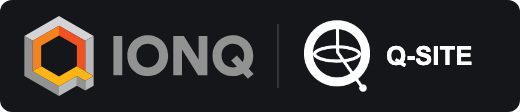


> **Opening: onboarding and unranked local practice.**
> Start with the 15-minute recovery below. The points printed in this notebook are local feedback,
> not official standings. Scored competition will begin only after validation and the organizer's
> announcement of its rules and deadlines.
>
> Later sections describe existing SDK practice profiles and competition tools as reference material,
> not the final official competition structure. Save your practice ZIP locally. If organizers open an
> **Orientation** round, you may upload it for validation and storage only: no execution or prizes.
> Wait for the announced final rules before preparing a scored submission.


# Quantum Duel, step by step — the freshman walkthrough
### Quantum Duel · IonQ challenge · Student notebook for platform RC 0.7.2 (freshman edition)

Somebody has hidden a small quantum circuit inside a black box. Your job is to work out what it does
using only the statistics of measurement outcomes, and then build a second circuit that **undoes it**.
That is the core game. The existing SDK practice profiles widen the circuit families while preserving the same
probe → reason → correct → submit loop.

This edition is for students who have met complex numbers and matrices but have **never** done quantum
computing. It moves slowly on purpose. Every step says three things:

- **What we do** — the concrete action in the next code cell.
- **Why we do it** — the reasoning that makes this the right next experiment, and what would go wrong without it.
- **What to look for** — how to read the printed numbers, tables and pictures.

By the end you will have: recovered a hidden phase fault by hand, understood why one histogram can lie,
written a defender program, designed two attacks, tested the exact files you will upload, and packaged
a complete `submission.zip`. **Upload that ZIP, never this notebook.**

The one- and two-qubit primer and the four-qubit warm-up stay the same in every download.
The selected round controls the **actual submission**, including the eight-qubit open final.

For a first visit, follow **Setup → Your first 15 minutes** below. Return to the full primer when you want the details. No server account, organizer repository or IonQ access is
needed. After the Python packages are installed, everything runs offline on your machine.


> **New to quantum computing?** Run every code cell in **Setup**, through **Drawing circuits**.
> Then follow **[Your first 15 minutes](#quickstart)**. You can get your first correction before reading the full primer.
> The primer remains available below; none of its variables are required by the quickstart.
>
> Already comfortable with the basics? Use the same setup, then choose the worked recovery or entry-building sections.

[Setup](#setup) · [First 15 minutes](#quickstart) · [First-hour checklist](#first-hour) ·
[Primer](#primer) · [Worked recovery](#duel) · [Tournament profiles](#tournaments) ·
[Prepare an entry](#entry) · [Upload later](#upload) · [Read feedback](#replay) · [Troubleshooting](#reference)


## The rules — what counts as winning

An opponent builds a static circuit $A$ (the **attack**). Your defender builds a correction $P$ (the
**patch**). You win recovery points when $P A$ behaves like *doing nothing* — the identity — **on every
possible input state**, not just on the all-zeros state.

| Your move | What happens | What you learn |
|---|---|---|
| Choose an input state and a measurement | The oracle prepares the input, runs the hidden attack (and your optional analysis circuit), and samples bitstrings | Experimental evidence, with shot noise |
| Submit a correction | The runner stores your explicit gate circuit | Whether it obeys the circuit limits; **no** live score |
| Close a checkpoint | The current correction is sealed and the next block of shots opens | How much budget remains |

For $n$ qubits, the private judge uses **process infidelity**
$$\epsilon(P,A)=1-\frac{|\operatorname{Tr}(PA)|^2}{4^n}.$$
The denominator is **256 for four qubits** and **65,536 for eight qubits**.
A perfect inverse has $\epsilon=0$, which means identity up to global phase on every input.
A small nonzero process error is **not** a worst-case guarantee on every input, and recovery points
are not a fidelity percentage. [IBM's definitions](https://quantum.cloud.ibm.com/docs/en/api/qiskit/quantum_info)
distinguish process fidelity, average gate fidelity, and worst-case channel distance.

The current point scale gives 100 at $\epsilon\leq0.001$, zero at $\epsilon\geq0.1$, and
$50\log_{10}(0.1/\epsilon)$ in between. Three checkpoint scores are averaged.
All valid attacks have an explicit legal inverse; finding one from a limited sample is not guaranteed.

**Two ideas to hold on to for the whole notebook:**
1. **A state is not a process.** Seeing the right output for *one* input proves almost nothing about the
   operation. We will meet an "impostor" that passes the easy test and fails the real one.
2. **Shots are money.** You have a fixed measurement budget. Choosing the *right* experiment beats
   repeating the wrong one a thousand times.


<a id="setup"></a>
## Setup

Use **Python 3.12 or 3.13**. These versions match the documented submission runtime. From a terminal:

```bash
python3.13 -m venv .venv
source .venv/bin/activate
python -m pip install jupyterlab ipykernel numpy==2.3.5 scipy==1.17.0 pydantic==2.13.4 httpx==0.28.1 numba==0.65.1 llvmlite==0.47.0 matplotlib
python -m ipykernel install --user --name quantum-duel --display-name "Quantum Duel (.venv)"
jupyter lab
```

Open this notebook and select **Quantum Duel (.venv)** from Jupyter's kernel menu.
The explicit kernel registration avoids installing packages into one Python and running cells in another.
On Windows use WSL2/Linux: extraction and local worker behavior use POSIX facilities. A local Mac smoke
test does not establish equivalence to the official Linux resource limits.

**Why these pins?** They match the supplied RC 0.7.2 source requirements, not a claim that they are the
latest or vulnerability-free packages. Numba and llvmlite are needed by the eight-qubit public learner.
Installation needs Internet access. After setup, the lessons and supplied experiments run locally.
Never put API keys, passwords, or organizer configuration in this notebook or your submission.


In [1]:
import sys, importlib, importlib.metadata, json, hashlib, os
from pathlib import Path
if not ((3, 12) <= sys.version_info[:2] < (3, 14)):
    raise RuntimeError("Use Python 3.12 or 3.13 for this release.")
# Set before NumPy/Numba import; these are local reproducibility settings, not a sandbox.
for variable in ("OPENBLAS_NUM_THREADS", "OMP_NUM_THREADS", "MKL_NUM_THREADS", "NUMBA_NUM_THREADS"):
    os.environ[variable] = "1"
os.environ.setdefault("NUMBA_CACHE_DIR", str(Path.cwd() / ".qduel_numba_cache"))
required = {"numpy": "2.3.5", "scipy": "1.17.0", "pydantic": "2.13.4",
            "httpx": "0.28.1", "numba": "0.65.1", "llvmlite": "0.47.0", "matplotlib": None}
missing, installed = [], {}
for package, expected in required.items():
    try:
        importlib.import_module(package)
        installed[package] = importlib.metadata.version(package)
    except ImportError:
        missing.append(package)
if missing:
    raise RuntimeError("Install the setup packages in this kernel: " + ", ".join(missing))
print("Python", sys.version.split()[0], "—", sys.executable)
print(installed)
for package, expected in required.items():
    if expected and installed[package] != expected:
        print(f"VERSION WARNING: {package}={installed[package]}; release requirement={expected}. Recheck before upload.")


Python 3.13.15 — /home/tuthuanvanvn/miniconda3/envs/ionq/bin/python
{'numpy': '2.3.5', 'scipy': '1.17.0', 'pydantic': '2.13.4', 'httpx': '0.28.1', 'numba': '0.65.1', 'llvmlite': '0.47.0', 'matplotlib': '3.11.2'}


### One-file setup
The folded cell below contains the public SDK as readable source, with content hashes. It writes those
helpers to `_quantum_duel_sdk_0_7_2` beside the notebook. Expand it to inspect the code. It contains no
private server, final attacks, account details, or credentials.

**Why embed the code instead of `pip install`?** So that the exact validators the website uses are the
ones you test with, and so the notebook keeps working offline. A checksum detects accidental changes; it
does not authenticate a notebook supplied by a stranger. Download this file from your event portal and
execute only source you trust. Existing edited SDK files are not silently overwritten; use a fresh
directory when changing notebook releases.


In [2]:
PUBLIC_SOURCES = {'duelkit/__init__.py': '', 'duelkit/legacy_quantum.py': '"""Two-qubit teaching kernel. Static circuits; q0 is the LEFT tensor factor.\n\nNo credentials, network requests or participant-code execution. This is not a\nproduction circuit sandbox. Angles in the circuit IR are always radians.\n"""\nfrom __future__ import annotations\nfrom dataclasses import dataclass, asdict\nfrom itertools import product\nfrom functools import lru_cache\nimport hashlib, json, math\nimport numpy as np\nfrom scipy.linalg import expm\n\nI2 = np.eye(2, dtype=complex)\nI4 = np.eye(4, dtype=complex)\nX = np.array([[0,1],[1,0]], dtype=complex)\nY = np.array([[0,-1j],[1j,0]], dtype=complex)\nZ = np.diag([1,-1]).astype(complex)\nH = (X+Z)/np.sqrt(2)\nPAULI = dict(I=I2, X=X, Y=Y, Z=Z)\nLABELS = tuple(\'\'.join(p) for p in product(\'IXYZ\', repeat=2))\nPMATS = np.array([np.kron(PAULI[p[0]], PAULI[p[1]]) for p in LABELS])\nLABEL_INDEX = {p:i for i,p in enumerate(LABELS)}\nBITSTRINGS = (\'00\',\'01\',\'10\',\'11\')\n\n\ndef canonical_json(obj):\n    return json.dumps(obj, sort_keys=True, separators=(\',\', \':\'), allow_nan=False)\n\n\ndef digest(obj):\n    return hashlib.sha256(canonical_json(obj).encode()).hexdigest()\n\n\ndef derive_seed(*parts):\n    return int.from_bytes(hashlib.sha256(canonical_json(parts).encode()).digest()[:8], \'big\')\n\n\n@dataclass(frozen=True)\nclass Gate:\n    name: str\n    targets: tuple[int, ...]\n    angle: float | None = None\n\n    def data(self):\n        return {\'name\':self.name, \'targets\':list(self.targets), \'angle\':self.angle}\n\n\nCircuit = tuple[Gate, ...]\nSINGLE = {\'rx\',\'ry\',\'rz\',\'x\',\'y\',\'z\',\'h\'}\nDOUBLE = {\'rxx\',\'ryy\',\'rzz\',\'cx\'}\nROTATIONS = {\'rx\',\'ry\',\'rz\',\'rxx\',\'ryy\',\'rzz\'}\n\n\ndef G(name, target=0, angle=None):\n    return Gate(name, (target,) if isinstance(target, int) else tuple(target), angle)\n\n\ndef circuit_data(circuit):\n    return [g.data() for g in circuit]\n\n\ndef from_data(data):\n    if not isinstance(data, list) or len(data)>64:\n        raise ValueError(\'Circuit must be a list of at most 64 gate objects.\')\n    out=[]\n    for v in data:\n        if not isinstance(v, dict) or set(v) != {\'name\',\'targets\',\'angle\'}:\n            raise ValueError(\'Only name, targets and angle fields are allowed.\')\n        out.append(Gate(v[\'name\'], tuple(v[\'targets\']), v[\'angle\']))\n    return tuple(out)\n\n\ndef validate(circuit, *, max_gates=24, max_entanglers=3):\n    if not isinstance(circuit, tuple):\n        raise ValueError(\'Use an immutable tuple of Gate records.\')\n    if len(circuit)>max_gates:\n        raise ValueError(f\'Too many gates: {len(circuit)}; limit {max_gates}.\')\n    for g in circuit:\n        if not isinstance(g, Gate) or g.name not in SINGLE | DOUBLE:\n            raise ValueError(\'Only the published static gate grammar is allowed.\')\n        arity=1 if g.name in SINGLE else 2\n        if (len(g.targets)!=arity or len(set(g.targets))!=arity\n            or any(type(q) is not int or q not in (0,1) for q in g.targets)):\n            raise ValueError(\'Gate targets must be distinct qubits 0 and/or 1.\')\n        if g.name in ROTATIONS:\n            if isinstance(g.angle, (bool, str)) or not isinstance(g.angle, (int,float,np.floating)):\n                raise ValueError(\'A rotation needs one finite numeric angle in radians.\')\n            if not np.isfinite(g.angle) or abs(g.angle)>8*np.pi:\n                raise ValueError(\'Angle is nonfinite or outside the draft numerical range.\')\n        elif g.angle is not None:\n            raise ValueError(\'This gate has no angle parameter.\')\n    ent=sum(g.name in DOUBLE for g in circuit)\n    if ent>max_entanglers:\n        raise ValueError(f\'Too many abstract entanglers: {ent}; limit {max_entanglers}.\')\n    return {\'gates\':len(circuit),\'abstract_entanglers\':ent,\n            \'single_qubit_gates\':len(circuit)-ent}\n\n\ndef gate_matrix(g):\n    if g.name in (\'rx\',\'ry\',\'rz\'):\n        p=PAULI[g.name[-1].upper()]\n        m=np.cos(g.angle/2)*I2-1j*np.sin(g.angle/2)*p\n        return np.kron(m,I2) if g.targets[0]==0 else np.kron(I2,m)\n    if g.name in (\'rxx\',\'ryy\',\'rzz\'):\n        p=np.kron(PAULI[g.name[-1].upper()], PAULI[g.name[-1].upper()])\n        return np.cos(g.angle/2)*I4-1j*np.sin(g.angle/2)*p\n    if g.name in (\'x\',\'y\',\'z\',\'h\'):\n        m=H if g.name==\'h\' else PAULI[g.name.upper()]\n        return np.kron(m,I2) if g.targets[0]==0 else np.kron(I2,m)\n    if g.name==\'cx\':\n        a=np.zeros((4,4),complex)\n        for j in range(4):\n            b=[j//2,j%2]\n            b[g.targets[1]] ^= b[g.targets[0]]\n            a[2*b[0]+b[1],j]=1\n        return a\n    raise ValueError(\'Unsupported gate\')\n\n\ndef unitary(circuit):\n    u=I4.copy()\n    for g in circuit: # left-to-right TIME order; matrices multiply on the left\n        u=gate_matrix(g)@u\n    return u\n\n\ndef inverse(circuit):\n    return tuple(Gate(g.name,g.targets,-float(g.angle) if g.name in ROTATIONS else None)\n                 for g in reversed(circuit))\n\n\ndef independent_unitary(circuit):\n    """Separate expm/controlled-projector path used by conformance tests."""\n    u=I4.copy()\n    for g in circuit:\n        if g.name in ROTATIONS:\n            if len(g.targets)==1:\n                p=np.kron(PAULI[g.name[-1].upper()], I2) if g.targets[0]==0 else np.kron(I2,PAULI[g.name[-1].upper()])\n            else:\n                p=np.kron(PAULI[g.name[-1].upper()],PAULI[g.name[-1].upper()])\n            m=expm(-0.5j*float(g.angle)*p)\n        elif g.name==\'cx\':\n            p0=(I2+Z)/2; p1=(I2-Z)/2\n            m=np.kron(p0,I2)+np.kron(p1,X) if g.targets==(0,1) else np.kron(I2,p0)+np.kron(X,p1)\n        else:\n            a=H if g.name==\'h\' else PAULI[g.name.upper()]\n            m=np.kron(a,I2) if g.targets[0]==0 else np.kron(I2,a)\n        u=m@u\n    return u\n\n\ndef infidelity(u, target=I4):\n    return float(np.clip(1-abs(np.trace(target.conj().T@u))**2/16,0,1))\n\n\ndef choi_infidelity(u, target=I4):\n    a=np.asarray(u).reshape(-1)/2\n    b=np.asarray(target).reshape(-1)/2\n    return float(np.clip(1-abs(np.vdot(b,a))**2,0,1))\n\n\ndef ptm(u):\n    evolved=np.einsum(\'ab,jbc,cd->jad\',u,PMATS,u.conj().T)\n    return np.einsum(\'iab,jba->ij\',PMATS,evolved).real/4\n\n\ndef global_distance(u,v):\n    return float(np.sqrt(max(0,2-2*abs(np.trace(u.conj().T@v))/4)))\n\n\nSTATE={\n    \'Z+\':np.array([1,0],complex), \'Z-\':np.array([0,1],complex),\n    \'X+\':np.array([1,1],complex)/np.sqrt(2), \'X-\':np.array([1,-1],complex)/np.sqrt(2),\n    \'Y+\':np.array([1,1j],complex)/np.sqrt(2), \'Y-\':np.array([1,-1j],complex)/np.sqrt(2),\n}\n\n\n@dataclass(frozen=True)\nclass Experiment:\n    prep: tuple[str,str]\n    basis: str\n    def data(self): return {\'prep\':list(self.prep),\'basis\':self.basis}\n\n\nEXPERIMENTS=tuple(Experiment(tuple(p), \'\'.join(b))\n                  for p in product(STATE, repeat=2) for b in product(\'XYZ\',repeat=2))\nEXPERIMENT_INDEX={e:i for i,e in enumerate(EXPERIMENTS)}\nKETS=np.array([np.kron(STATE[e.prep[0]],STATE[e.prep[1]]) for e in EXPERIMENTS])\n# Columns are the basis eigenvectors in bit order 00,01,10,11.\nMEAS_BASIS=np.array([np.column_stack([np.kron(STATE[e.basis[0]+(\'+\' if s[0]==\'0\' else \'-\')],\n                                                        STATE[e.basis[1]+(\'+\' if s[1]==\'0\' else \'-\')])\n                                    for s in BITSTRINGS]) for e in EXPERIMENTS])\nTOMOGRAPHY_PANEL=np.array([i for i,e in enumerate(EXPERIMENTS)\n                         if all(p in (\'Z+\',\'Z-\',\'X+\',\'Y+\') for p in e.prep)],dtype=int)\n\n\ndef probabilities(u, indices=None):\n    ids=np.arange(len(EXPERIMENTS)) if indices is None else np.asarray(indices,dtype=int)\n    states=np.einsum(\'ab,sb->sa\',u,KETS[ids])\n    amplitudes=np.einsum(\'sba,sb->sa\',MEAS_BASIS[ids].conj(),states)\n    p=np.abs(amplitudes)**2\n    p=np.clip(p,0,1)\n    return p/p.sum(axis=1,keepdims=True)\n\n\ndef outcome_signs(mask):\n    if mask not in (0,1,2,3): raise ValueError(\'mask must be 0..3\')\n    return np.array([(-1)**sum(int(bits[q]) for q in (0,1) if mask & (2>>q)) for bits in BITSTRINGS])\n\n\ndef expectation_from_counts(counts, mask=3):\n    c=np.array([counts.get(s,0) for s in BITSTRINGS],float)\n    if c.sum()<=0: raise ValueError(\'Positive count total required.\')\n    return float(c@outcome_signs(mask)/c.sum())\n\n\ndef wilson_expectation(counts, mask=3, z=1.959963984540054):\n    """Pointwise interval for a selected binary observable; not a simultaneous certificate."""\n    c=np.array([counts.get(s,0) for s in BITSTRINGS],float)\n    n=c.sum()\n    if n<=0: raise ValueError(\'Positive count total required.\')\n    p=c[outcome_signs(mask)>0].sum()/n\n    den=1+z*z/n\n    center=(p+z*z/(2*n))/den\n    half=z*np.sqrt(p*(1-p)/n+z*z/(4*n*n))/den\n    return (float(2*max(0,center-half)-1),float(2*min(1,center+half)-1))\n\n\ndef measurement_design_rank():\n    """Rank on the 16x16 real Pauli representation using raw probabilities."""\n    rows=[]\n    for i in TOMOGRAPHY_PANEL:\n        rho=np.outer(KETS[i],KETS[i].conj())\n        rin=np.einsum(\'iab,ba->i\',PMATS,rho).real\n        for b in range(4):\n            v=MEAS_BASIS[i,:,b]\n            eff=np.outer(v,v.conj())\n            mout=np.einsum(\'iab,ba->i\',PMATS,eff).real\n            rows.append(np.outer(mout,rin).reshape(-1)/4)\n    return int(np.linalg.matrix_rank(np.array(rows),tol=1e-9))\n\n\ndef qasm_export(circuit):\n    """Static QASM transport only. Backend acceptance/native lowering are NOT certified."""\n    validate(circuit)\n    lines=[\'OPENQASM 3.0;\',\'include "stdgates.inc";\',\'qubit[2] q;\']\n    # Expand Pauli interactions into the narrow rx/ry/rz/h/cx transport basis.\n    def emit(name,qs,a=None):\n        angle=\'\' if a is None else \'(\'+format(float(a),\'.17g\')+\')\'\n        lines.append(name+angle+\' \'+\', \'.join(f\'q[{q}]\' for q in qs)+\';\')\n    for g in circuit:\n        if g.name in (\'rxx\',\'ryy\',\'rzz\'):\n            if g.name==\'rxx\':\n                emit(\'h\',(0,)); emit(\'h\',(1,))\n            if g.name==\'ryy\':\n                emit(\'rx\',(0,),np.pi/2); emit(\'rx\',(1,),np.pi/2)\n            emit(\'cx\',(0,1)); emit(\'rz\',(1,),g.angle); emit(\'cx\',(0,1))\n            if g.name==\'rxx\':\n                emit(\'h\',(0,)); emit(\'h\',(1,))\n            if g.name==\'ryy\':\n                emit(\'rx\',(0,),-np.pi/2); emit(\'rx\',(1,),-np.pi/2)\n        else: emit(g.name,g.targets,g.angle)\n    return \'\\n\'.join(lines)+\'\\n\'\n', 'duelkit/quantum.py': '"""Dimension-aware 2/4-qubit kernel and version-stable product-Pauli experiment IDs.\n\nServer paths always pass Rules.qubits explicitly. Default n=2 retains legacy\npublic SDK compatibility, not a license to infer a circuit\'s register size.\n4q measurement catalogs are lazy: never allocate 104,976 dense basis matrices.\n"""\nfrom __future__ import annotations\nfrom dataclasses import dataclass\nfrom collections.abc import Sequence\nfrom functools import lru_cache\nfrom itertools import product\nimport math, hashlib, json\nimport numpy as np\nfrom scipy.linalg import expm\nfrom . import legacy_quantum as legacy\n\nI2=legacy.I2; I4=legacy.I4; X=legacy.X; Y=legacy.Y; Z=legacy.Z; H=legacy.H\nPAULI=legacy.PAULI; STATE=legacy.STATE\nGate=legacy.Gate; G=legacy.G; Circuit=legacy.Circuit\nSINGLE=legacy.SINGLE; DOUBLE=legacy.DOUBLE; ROTATIONS=legacy.ROTATIONS\ncanonical_json=legacy.canonical_json; digest=legacy.digest; derive_seed=legacy.derive_seed\ncircuit_data=legacy.circuit_data\nLABELS=legacy.LABELS; PMATS=legacy.PMATS; LABEL_INDEX=legacy.LABEL_INDEX\n# Legacy table aliases remain small and stable for historical public solvers.\nEXPERIMENTS=legacy.EXPERIMENTS; EXPERIMENT_INDEX=legacy.EXPERIMENT_INDEX\nKETS=legacy.KETS; MEAS_BASIS=legacy.MEAS_BASIS\nTOMOGRAPHY_PANEL=legacy.TOMOGRAPHY_PANEL; BITSTRINGS=legacy.BITSTRINGS\n\ndef _n(n):\n    if type(n) is not int or n not in (2,4,8):\n        raise ValueError("Supported registers are 2, 4 and 8 qubits")\n    return n\n\ndef from_data(data):\n    if not isinstance(data,list) or len(data)>108:\n        raise ValueError("Circuit must be a list of at most 108 gate records")\n    out=[]\n    for v in data:\n        if not isinstance(v,dict) or set(v)!={"name","targets","angle"}:\n            raise ValueError("Only name, targets and angle are allowed")\n        if not isinstance(v["targets"],list): raise ValueError("targets must be an array")\n        out.append(Gate(v["name"],tuple(v["targets"]),v["angle"]))\n    return tuple(out)\n\ndef validate(circuit, *, n=2, max_gates=24, max_entanglers=3,\n             alphabet=None, max_angle=8*math.pi):\n    _n(n)\n    allowed=SINGLE|DOUBLE if alphabet is None else set(alphabet)\n    if not isinstance(circuit,tuple): raise ValueError("Use an immutable tuple of Gate records")\n    if len(circuit)>max_gates: raise ValueError(f"Too many gates: {len(circuit)}; limit {max_gates}")\n    for g in circuit:\n        if not isinstance(g,Gate) or g.name not in allowed or g.name not in SINGLE|DOUBLE:\n            raise ValueError("Gate is not in this round\'s static alphabet")\n        arity=1 if g.name in SINGLE else 2\n        if (len(g.targets)!=arity or len(set(g.targets))!=arity or\n            any(type(i) is not int or not 0<=i<n for i in g.targets)):\n            raise ValueError(f"Gate needs {arity} distinct targets in [0,{n-1}]")\n        if g.name in ROTATIONS:\n            if isinstance(g.angle,(bool,str)) or not isinstance(g.angle,(int,float,np.floating)):\n                raise ValueError("Rotation angle must be a finite JSON number in radians")\n            if not np.isfinite(g.angle) or abs(g.angle)>max_angle:\n                raise ValueError("Rotation angle outside the round\'s canonical range")\n        elif g.angle is not None: raise ValueError("This gate has no angle parameter")\n    ent=sum(g.name in DOUBLE for g in circuit)\n    if ent>max_entanglers: raise ValueError(f"Too many abstract entanglers: {ent}; limit {max_entanglers}")\n    return {"gates":len(circuit),"abstract_entanglers":ent,"single_qubit_gates":len(circuit)-ent}\n\ndef kron_all(ops):\n    out=np.array([[1]],complex)\n    for op in ops: out=np.kron(out,op)\n    return out\n\n@lru_cache(maxsize=1024)\ndef generator(label):\n    if any(x not in PAULI for x in label): raise ValueError("Invalid Pauli string")\n    m=kron_all([PAULI[c] for c in label]); m.flags.writeable=False\n    return m\n\ndef gate_matrix(g,n=2):\n    _n(n)\n    if n==2: return legacy.gate_matrix(g)\n    d=1<<n\n    if g.name in ROTATIONS:\n        p=generator(\'\'.join(g.name[-1].upper() if i in g.targets else \'I\' for i in range(n)))\n        return np.cos(g.angle/2)*np.eye(d)-1j*np.sin(g.angle/2)*p\n    if g.name in (\'x\',\'y\',\'z\',\'h\'):\n        m=H if g.name==\'h\' else PAULI[g.name.upper()]\n        return kron_all([m if i==g.targets[0] else I2 for i in range(n)])\n    if g.name==\'cx\':\n        out=np.zeros((d,d),complex)\n        for col in range(d):\n            row=col ^ (1<<(n-1-g.targets[1])) if col & (1<<(n-1-g.targets[0])) else col\n            out[row,col]=1\n        return out\n    raise ValueError("Unsupported gate")\n\ndef unitary(circuit,n=2):\n    _n(n)\n    if n==2: return legacy.unitary(circuit)\n    u=np.eye(1<<n,dtype=complex)\n    if n==8:\n        for g in circuit:u=apply_gate(g,u,n)\n        return u\n    for g in circuit: u=gate_matrix(g,n)@u\n    return u\n\ndef inverse(circuit): return legacy.inverse(circuit)\n\ndef independent_unitary(circuit,n=2):\n    _n(n)\n    if n==2: return legacy.independent_unitary(circuit)\n    if n==8:\n        # Independent embedding: exponentiate ONLY 2x2/4x4 matrices and apply by tensor axes.\n        u=np.eye(1<<n,dtype=complex)\n        for g in circuit:\n            k=len(g.targets)\n            a=PAULI[g.name[-1].upper()]\n            local=expm(-0.5j*float(g.angle)*(a if k==1 else np.kron(a,a)))\n            order=list(g.targets)+[q for q in range(n) if q not in g.targets]+[n]\n            tensor=u.reshape([2]*n+[1<<n]).transpose(order)\n            tensor=(local@tensor.reshape(1<<k,-1)).reshape(tensor.shape)\n            u=tensor.transpose(np.argsort(order)).reshape(1<<n,1<<n)\n        return u\n    # Separate direct tensor/exponential path; no gate_matrix/generator reuse.\n    d=1<<n; out=np.eye(d,dtype=complex)\n    for g in circuit:\n        factors=[np.eye(2,dtype=complex) for _ in range(n)]\n        if g.name in ROTATIONS:\n            for t in g.targets: factors[t]=PAULI[g.name[-1].upper()]\n            p=kron_all(factors); m=expm(-0.5j*float(g.angle)*p)\n        elif g.name==\'cx\':\n            a=list(factors); b=list(factors)\n            a[g.targets[0]]=(I2+Z)/2; b[g.targets[0]]=(I2-Z)/2; b[g.targets[1]]=X\n            m=kron_all(a)+kron_all(b)\n        else:\n            factors[g.targets[0]]=H if g.name==\'h\' else PAULI[g.name.upper()]\n            m=kron_all(factors)\n        out=m@out\n    return out\n\ndef _shape(u,target=None):\n    u=np.asarray(u,complex)\n    if u.ndim!=2 or u.shape[0]!=u.shape[1] or u.shape[0] not in (4,16,256) or not np.isfinite(u).all():\n        raise ValueError("Expected a finite 4x4, 16x16 or 256x256 matrix")\n    target=np.eye(u.shape[0],dtype=complex) if target is None else np.asarray(target,complex)\n    if target.shape!=u.shape or not np.isfinite(target).all(): raise ValueError("Target dimension mismatch")\n    return u,target\n\ndef infidelity(u,target=None):\n    u,target=_shape(u,target)\n    overlap=np.vdot(target,u) if len(u)==256 else np.trace(target.conj().T@u)\n    return float(np.clip(1-abs(overlap)**2/u.shape[0]**2,0,1))\n\ndef choi_infidelity(u,target=None):\n    u,target=_shape(u,target);d=u.shape[0]\n    return float(np.clip(1-abs(np.vdot(target.reshape(-1)/np.sqrt(d),u.reshape(-1)/np.sqrt(d)))**2,0,1))\n\ndef global_distance(u,v):\n    u,v=_shape(u,v)\n    overlap=np.vdot(u,v) if len(u)==256 else np.trace(u.conj().T@v)\n    return float(np.sqrt(max(0,2-2*abs(overlap)/u.shape[0])))\n\ndef ptm(u):\n    u,_=_shape(u);n=int(round(np.log2(u.shape[0])))\n    if n>4:raise ValueError(\'Full PTM disabled for eight qubits; use measured residuals\')\n    mats=PMATS if n==2 else np.array([generator(\'\'.join(p)) for p in product(\'IXYZ\',repeat=n)])\n    ev=np.einsum(\'ab,jbc,cd->jad\',u,mats,u.conj().T)\n    return np.einsum(\'iab,jba->ij\',mats,ev).real/u.shape[0]\n\n@dataclass(frozen=True)\nclass Experiment:\n    prep: tuple[str,...]\n    basis: str\n    def data(self): return {"prep":list(self.prep),"basis":self.basis}\n\nPREPARATIONS=tuple(STATE)  # Z+, Z-, X+, X-, Y+, Y-; legacy index order retained.\nPREP_ALIASES={"0":"Z+","1":"Z-","+":"X+","-":"X-","+i":"Y+","-i":"Y-"}\n\ndef bitstrings(n): return tuple(format(i,f\'0{_n(n)}b\') for i in range(1<<n))\n\ndef _digits(k,base,n):\n    out=[0]*n\n    for j in range(n-1,-1,-1): out[j]=k%base; k//=base\n    return out\n\ndef experiment_at(index,n=2):\n    _n(n)\n    if type(index) is not int or not 0<=index<18**n: raise ValueError("Experiment index outside the round\'s register")\n    a,b=divmod(index,3**n)\n    return Experiment(tuple(PREPARATIONS[x] for x in _digits(a,6,n)),\'\'.join(\'XYZ\'[x] for x in _digits(b,3,n)))\n\ndef experiment_index(prep,basis,n=2):\n    _n(n)\n    if len(prep)!=n or len(basis)!=n: raise ValueError("Preparation and readout must match register length")\n    a=b=0\n    for x in prep:\n        x=PREP_ALIASES.get(x,x)\n        if x not in PREPARATIONS: raise ValueError("Unknown Pauli eigenstate")\n        a=6*a+PREPARATIONS.index(x)\n    for x in basis:\n        if x not in \'XYZ\': raise ValueError("Readout must use X, Y or Z")\n        b=3*b+\'XYZ\'.index(x)\n    return a*3**n+b\n\nclass ExperimentCatalog(Sequence):\n    def __init__(self,n): self.n=_n(n)\n    def __len__(self): return 18**self.n\n    def __getitem__(self,i):\n        if isinstance(i,slice):\n            rr=range(*i.indices(len(self)))\n            if len(rr)>2048:raise ValueError(\'Use bounded catalogue pages\')\n            return [self[j] for j in rr]\n        return experiment_at(i,self.n)\n\ndef experiment_catalog(n): return ExperimentCatalog(n)\n\n@lru_cache(maxsize=2048)\ndef experiment_arrays(index,n):\n    if n==8:raise ValueError(\'Eight-qubit readout bases must use the streamed path\')\n    e=experiment_at(index,n)\n    ket=kron_all([STATE[x].reshape(2,1) for x in e.prep]).reshape(-1)\n    basis=kron_all([np.column_stack([STATE[x+\'+\'],STATE[x+\'-\']]) for x in e.basis])\n    ket.flags.writeable=False;basis.flags.writeable=False\n    return ket,basis\n\ndef probabilities(u,indices=None):\n    u,_=_shape(u);n=int(round(np.log2(u.shape[0])))\n    if n==2: return legacy.probabilities(u,indices)\n    if n==8:\n        if indices is None:raise ValueError(\'Explicit bounded indices required\')\n        ids=list(indices)\n        if len(ids)>2048:raise ValueError(\'Probability batch exceeds 2048 settings\')\n        return np.asarray([stream_probability(u,int(i),n) for i in ids]).reshape(len(ids),1<<n)\n    if indices is None: raise ValueError("Explicit indices required: four-qubit catalog is lazy")\n    ids=list(indices)\n    if len(ids)>2048: raise ValueError("Probability batch exceeds 2048 settings")\n    if not ids:return np.zeros((0,1<<n))\n    arrays=[experiment_arrays(int(i),n) for i in ids]\n    ket=np.stack([a for a,b in arrays]);basis=np.stack([b for a,b in arrays])\n    state=np.einsum(\'ab,sb->sa\',u,ket)\n    amplitude=np.einsum(\'sba,sb->sa\',basis.conj(),state)\n    p=np.clip(np.abs(amplitude)**2,0,1)\n    return p/p.sum(axis=1,keepdims=True)\n\ndef independent_probabilities(u,index,n):\n    e=experiment_at(index,n)\n    rho=kron_all([np.outer(STATE[x],STATE[x].conj()) for x in e.prep])\n    rho=u@rho@u.conj().T\n    values=[]\n    for bits in bitstrings(n):\n        projector=kron_all([(I2+(1 if b==\'0\' else -1)*PAULI[a])/2 for a,b in zip(e.basis,bits)])\n        values.append(float(np.trace(projector@rho).real))\n    p=np.maximum(0,values);return p/p.sum()\n\ndef outcome_signs(mask,n=2):\n    if type(mask) is not int or not 0<=mask<(1<<n):raise ValueError("Invalid observable mask")\n    return np.array([(-1)**((i&mask).bit_count()) for i in range(1<<n)])\n\ndef expectation_from_counts(counts,mask=None):\n    if not counts:raise ValueError("No counts")\n    n=len(next(iter(counts)));bits=bitstrings(n);mask=(1<<n)-1 if mask is None else mask\n    c=np.array([counts.get(s,0) for s in bits],float)\n    if not np.isfinite(c).all() or np.any(c<0) or c.sum()<=0:raise ValueError("Invalid counts")\n    return float(c@outcome_signs(mask,n)/c.sum())\n\ndef wilson_expectation(counts,mask=None,z=1.959963984540054):\n    if not counts:raise ValueError("No counts")\n    n=len(next(iter(counts)));bits=bitstrings(n);mask=(1<<n)-1 if mask is None else mask\n    c=np.array([counts.get(s,0) for s in bits],float);N=c.sum()\n    if N<=0 or np.any(c<0):raise ValueError("Positive nonnegative counts required")\n    p=c[outcome_signs(mask,n)>0].sum()/N;den=1+z*z/N\n    center=(p+z*z/(2*N))/den;half=z*np.sqrt(p*(1-p)/N+z*z/(4*N*N))/den\n    return float(2*max(0,center-half)-1),float(2*min(1,center+half)-1)\n\n# Original teaching rank utility retains its explicitly two-qubit meaning.\nexperiment_rank=legacy.experiment_rank if hasattr(legacy,\'experiment_rank\') else None\nmeasurement_rank=legacy.measurement_rank if hasattr(legacy,\'measurement_rank\') else None\n\ndef qasm_export(circuit,n=2,**limits):\n    validate(circuit,n=n,**limits)\n    lines=[\'OPENQASM 3.0;\',\'include "stdgates.inc";\',f\'qubit[{n}] q;\']\n    def emit(name,qs,a=None):\n        angle=\'\' if a is None else \'(\'+format(float(a),\'.17g\')+\')\'\n        lines.append(name+angle+\' \'+\', \'.join(f\'q[{q}]\' for q in qs)+\';\')\n    for g in circuit:\n        if g.name in (\'rxx\',\'ryy\',\'rzz\'):\n            a,b=g.targets\n            if g.name==\'rxx\':emit(\'h\',(a,));emit(\'h\',(b,))\n            if g.name==\'ryy\':emit(\'rx\',(a,),np.pi/2);emit(\'rx\',(b,),np.pi/2)\n            emit(\'cx\',(a,b));emit(\'rz\',(b,),g.angle);emit(\'cx\',(a,b))\n            if g.name==\'rxx\':emit(\'h\',(a,));emit(\'h\',(b,))\n            if g.name==\'ryy\':emit(\'rx\',(a,),-np.pi/2);emit(\'rx\',(b,),-np.pi/2)\n        else:emit(g.name,g.targets,g.angle)\n    return \'\\n\'.join(lines)+\'\\n\'\n\n# Compatibility exports for old public notebooks only.\nfor _name in ("tomography_rank", "table_rows", "CircuitBuilder"):\n    if hasattr(legacy,_name) and _name not in globals(): globals()[_name]=getattr(legacy,_name)\n\n\n@lru_cache(maxsize=128)\ndef _pauli_rows(name,targets,n):\n    xmask=sum(1<<(n-1-q) for q in targets) if name[-1] in \'xy\' else 0\n    ids=np.arange(1<<n);rows=ids^xmask;phase=np.ones(1<<n,dtype=complex)\n    for q in targets:\n        bit=(rows>>(n-1-q))&1\n        if name[-1]==\'y\':phase*=1j*(1-2*bit)\n        elif name[-1]==\'z\':phase*=1-2*bit\n    return rows,phase\n\ndef apply_gate(g,state,n):\n    if g.name not in ROTATIONS:raise ValueError(\'Eight-qubit profile only supports rotations\')\n    rows,phase=_pauli_rows(g.name,tuple(g.targets),n)\n    scale=phase if state.ndim==1 else phase[:,None]\n    return np.cos(g.angle/2)*state-1j*np.sin(g.angle/2)*scale*state[rows]\n\ndef apply_circuit(circuit,state,n):\n    for g in circuit:state=apply_gate(g,state,n)\n    return state\n\n@lru_cache(maxsize=512)\ndef prepared_state(index,n):\n    e=experiment_at(index,n)\n    v=kron_all([STATE[x].reshape(2,1) for x in e.prep]).reshape(-1)\n    v.flags.writeable=False\n    return v\n\ndef stream_probability(u,index,n=8,analysis=()):\n    e=experiment_at(index,n)\n    state=u@prepared_state(index,n)\n    state=apply_circuit(analysis,state,n)\n    t=state.reshape([2]*n)\n    for q,b in enumerate(e.basis):\n        m=np.column_stack([STATE[b+\'+\'],STATE[b+\'-\']]).conj().T\n        t=np.moveaxis(np.tensordot(m,t,axes=(1,q)),0,q)\n    p=np.maximum(0,np.abs(t.reshape(-1))**2)\n    return p/p.sum()\n', 'duelkit/recovery4/__init__.py': '"""Public count-only four-qubit baselines. No attack or judge data."""\n', 'duelkit/recovery4/adapter.py': '"""Ready-to-run legal baseline using only authenticated oracle count receipts.\n\nFixed 180-setting public panel. Not a mandatory measurement policy. No hidden\ninstance/template imports. Dense models are internal initializers; only explicit\nrotation-gate patches are submitted and validated under the frozen contract.\n"""\nfrom __future__ import annotations\nimport numpy as np\nfrom duelkit.quantum import G,validate,experiment_index,bitstrings\nfrom .quantum import make_panel,design,Likelihood\nfrom .recovery import Ensemble\n\ndef as_gates(patch):\n    gates=[]\n    for record in patch:\n        targets=tuple(i for i,a in enumerate(record[\'pauli\']) if a!=\'I\')\n        letters=\'\'.join(record[\'pauli\'][i].lower() for i in targets)\n        if len(targets) not in (1,2) or len(set(letters))!=1:\n            raise ValueError(\'Estimated circuit contains an unsupported generator\')\n        # Equivalent rotations differ by 2*pi only through a global phase.\n        angle=float((record[\'angle\']+np.pi)%(2*np.pi)-np.pi)\n        gates.append(G(\'r\'+letters,targets,angle))\n    return tuple(gates)\n\ndef run_defender(client,rules,*,grouped=True,panel_seed=60231):\n    if rules.qubits!=4:raise ValueError(\'This baseline is for the four-qubit ruleset\')\n    size=min(180,rules.max_settings,rules.block)\n    panel=make_panel(4,size,panel_seed)\n    ids=[experiment_index(e[\'prep\'],\'\'.join(e[\'basis\']),4) for e in panel]\n    kets,bras=design(panel);counts=np.zeros((size,16),dtype=np.int64)\n    model=Ensemble(block=grouped,max_gates=rules.patch_max_gates,max_entanglers=rules.patch_max_entanglers)\n    for checkpoint in range(rules.checkpoints):\n        base,extra=divmod(rules.block,size)\n        for j,(index,e) in enumerate(zip(ids,panel)):\n            receipt=client.query(index,base+(j<extra),f\'c{checkpoint}-s{j}\')\n            if set(receipt[\'counts\'])!=set(bitstrings(4)):\n                raise ValueError(\'Oracle returned a mismatched outcome register\')\n            counts[j]+=np.array([receipt[\'counts\'][b] for b in bitstrings(4)],dtype=np.int64)\n        fitted=model.fit(Likelihood(kets,bras,counts))\n        patch=as_gates(fitted[\'block\'] if grouped else fitted[\'compact\'])\n        validate(patch,**rules.validation_kwargs())\n        note=\'grouped/compact likelihood selection\' if grouped else \'compact likelihood selection\'\n        client.submit_patch(patch,note=note)\n        client.close_checkpoint()\n', 'duelkit/recovery4/legacy_learners.py': '"""Count-only learners. Algorithms deliberately do not import oracle/generator modules."""\nfrom __future__ import annotations\nimport numpy as np\nfrom scipy.optimize import minimize\nfrom .quantum import *\n\nclass DenseMLE:\n    """General SU(2**n) MLE with exact spectral Frechet derivative.\n    Dense inverse is a diagnostic relaxation: no synthesis penalties are applied.\n    """\n    def __init__(self,n,maxiter=350,restarts=2):\n        self.n=n;self.labels,self.ps=all_paulis(n);self.x=None\n        self.maxiter=maxiter;self.restarts=restarts;self.trace=[]\n    def matrix(self,x):\n        h=np.einsum(\'k,kij->ij\',x,self.ps,optimize=True)/2\n        w,v=np.linalg.eigh(h);e=np.exp(-1j*w)\n        return (v*e)@v.conj().T\n    def objective(self,x,likelihood):\n        h=np.einsum(\'k,kij->ij\',x,self.ps,optimize=True)/2\n        w,v=np.linalg.eigh(h);e=np.exp(-1j*w);u=(v*e)@v.conj().T\n        loss,g=likelihood(u)\n        # divided differences exp(-i lambda); stable at repeated eigenvalues\n        dw=w[:,None]-w[None,:]\n        dd=-1j*np.exp(-.5j*(w[:,None]+w[None,:]))*np.sinc(dw/(2*np.pi))\n        gh=v@((v.conj().T@g@v)*dd.conj())@v.conj().T\n        grad=np.real(np.einsum(\'ij,kij->k\',gh.conj(),self.ps,optimize=True))/2\n        return loss,grad\n    def fit(self,likelihood):\n        rng=np.random.default_rng(83177)\n        starts=[self.x] if self.x is not None else [rng.normal(0,.025,len(self.ps)) for _ in range(self.restarts)]\n        fits=[]\n        for x in starts:\n            f=minimize(self.objective,x,args=(likelihood,),jac=True,method=\'L-BFGS-B\',options={\'maxiter\':self.maxiter,\'gtol\':1e-7,\'ftol\':1e-11,\'maxcor\':25,\'maxls\':30})\n            fits.append(f)\n        best=min(fits,key=lambda f:f.fun);self.x=best.x\n        self.trace.append({\'loss\':float(best.fun),\'iterations\':int(best.nit),\'converged\':bool(best.success),\'grad_inf\':float(np.max(np.abs(best.jac)))})\n        return self.matrix(self.x)\n\nclass GatePursuit:\n    """Greedy insertion of rotations on any allowed local/pair Pauli, then joint MLE.\n    Neither gate support nor order is supplied. BIC selects compact stopping point.\n    """\n    def __init__(self,n,max_gates=22,max_entanglers=8,beam=2):\n        self.n=n;self.max_gates=max_gates;self.max_entanglers=max_entanglers;self.beam=beam\n        self.labels=[];self.x=np.array([]);self.trace=[]\n    def objective(self,x,labels,like):\n        u,j,*_=circuit_and_jac(labels,x,self.n)\n        loss,g=like(u)\n        return loss,np.real(np.einsum(\'ij,kij->k\',g.conj(),j,optimize=True))\n    def refine(self,labels,x,like,maxiter=150):\n        return minimize(self.objective,x,args=(labels,like),jac=True,method=\'L-BFGS-B\',bounds=[(-np.pi,np.pi)]*len(labels),options={\'maxiter\':maxiter,\'gtol\':2e-7,\'ftol\':1e-10,\'maxcor\':15,\'maxls\':25})\n    def fit(self,like):\n        if self.labels:\n            f=self.refine(self.labels,self.x,like);self.x=f.x\n        ndata=like.total; penalty=np.log(ndata) # BIC deviance per extra parameter\n        while len(self.labels)<self.max_gates:\n            u,j,prefix,suffix=circuit_and_jac(self.labels,self.x,self.n)\n            base,g=like(u); dic,mats=dictionary(self.n)\n            ent=sum(sum(x!=\'I\' for x in p)>1 for p in self.labels)\n            candidates=[]\n            for pos in range(len(self.labels)+1):\n                for p,mat in zip(dic,mats):\n                    if sum(x!=\'I\' for x in p)>1 and ent>=self.max_entanglers:continue\n                    if pos>0 and self.labels[pos-1]==p:continue\n                    if pos<len(self.labels) and self.labels[pos]==p:continue\n                    tangent=suffix[pos]@(-.5j*mat)@prefix[pos]\n                    der=np.real(np.vdot(g,tangent))\n                    candidates.append((abs(der),pos,p,der))\n            # Avoid fitting many adjacent placements with same effective tangent.\n            candidates.sort(reverse=True); trials=[];seen=set()\n            for _,pos,p,der in candidates:\n                if p in seen:continue\n                seen.add(p)\n                labels=self.labels[:pos]+[p]+self.labels[pos:]\n                x=np.insert(self.x,pos,-np.sign(der)*.08)\n                f=self.refine(labels,x,like)\n                trials.append((f.fun,labels,f.x,f))\n                if len(trials)>=self.beam:break\n            if not trials:break\n            loss,labels,x,f=min(trials,key=lambda x:x[0])\n            gain=2*ndata*(base-loss)\n            if gain<penalty:break\n            self.labels=labels;self.x=x\n        u,*_=circuit_and_jac(self.labels,self.x,self.n)\n        self.trace.append({\'loss\':like(u)[0],\'gates\':len(self.labels),\'entanglers\':sum(sum(x!=\'I\' for x in p)>1 for p in self.labels)})\n        return u\n    def circuit(self):return [{\'pauli\':p,\'angle\':float(t)} for p,t in zip(self.labels,self.x)]\n\nclass MatrixDistance:\n    def __init__(self,target,total):self.target=target;self.total=total\n    def __call__(self,u):\n        s=np.vdot(self.target,u);d=u.shape[0]\n        return float(1-abs(s)**2/d**2), -2*s*self.target/d**2\n\nclass DenseThenCompact:\n    """Generic MLE -> gate-based compression -> observed-count refit.\n    This is a strengthened *structural* control, not an unrestricted model.\n    """\n    def __init__(self,n):self.n=n;self.dense=DenseMLE(n);self.trace=[];self.compact=None\n    def fit(self,like,dense_estimate=None):\n        target=self.dense.fit(like) if dense_estimate is None else dense_estimate\n        compact=GatePursuit(self.n)\n        compact.fit(MatrixDistance(target,like.total))\n        f=compact.refine(compact.labels,compact.x,like)\n        compact.x=f.x;self.compact=compact\n        u,*_=circuit_and_jac(compact.labels,compact.x,self.n)\n        self.trace.append({\'loss\':like(u)[0],\'gates\':len(compact.labels),\'entanglers\':sum(sum(x!=\'I\' for x in p)>1 for p in compact.labels)})\n        return u\n    def circuit(self):return self.compact.circuit()\n\nclass RidgeDenseMLE(DenseMLE):\n    """Rotationally isotropic log-unitary shrinkage, lambda selected by count CV."""\n    def __init__(self,n,maxiter=350):\n        super().__init__(n,maxiter=maxiter,restarts=2);self.lam=0\n    def objective(self,x,like):\n        loss,grad=super().objective(x,like)\n        return loss+self.lam*np.dot(x,x)/2,grad+self.lam*x\n    def fit(self,like,init=None):\n        rng=np.random.default_rng(12991)\n        # Binomial thinning uses no additional oracle shots.\n        train_counts=rng.binomial(like.counts.astype(int),.8)\n        test_counts=like.counts-train_counts\n        train=Likelihood(like.kets,like.bras,train_counts);valid=Likelihood(like.kets,like.bras,test_counts)\n        x0=self.x if self.x is not None else init\n        if x0 is None:x0=rng.normal(0,.025,len(self.ps))\n        options=[]\n        for lam in [0,.0003,.001,.003,.01,.03,.1]:\n            self.lam=lam\n            f=minimize(self.objective,x0,args=(train,),jac=True,method=\'L-BFGS-B\',options={\'maxiter\':self.maxiter,\'gtol\':1e-7,\'ftol\':1e-11,\'maxcor\':25})\n            options.append((valid(self.matrix(f.x))[0],lam,f.x))\n        _,lam,x0=min(options,key=lambda t:t[0]);self.lam=lam\n        f=minimize(self.objective,x0,args=(like,),jac=True,method=\'L-BFGS-B\',options={\'maxiter\':self.maxiter,\'gtol\':1e-7,\'ftol\':1e-11,\'maxcor\':25})\n        self.x=f.x\n        self.trace.append({\'loss\':like(self.matrix(f.x))[0],\'lambda\':float(lam),\'iterations\':int(f.nit),\'converged\':bool(f.success),\'grad_inf\':float(np.max(np.abs(f.jac)))})\n        return self.matrix(f.x)\n', 'duelkit/recovery4/quantum.py': '"""Public 1--6 qubit quantum primitives. No instance access.\nq0 is the left/MSB tensor factor; gate arrays are chronological; angles are radians.\n"""\nfrom __future__ import annotations\nfrom functools import lru_cache\nfrom itertools import product, combinations\nimport numpy as np\nfrom scipy.linalg import expm\n\nI=np.eye(2,dtype=complex)\nP1={\'I\':I,\'X\':np.array([[0,1],[1,0]],complex),\'Y\':np.array([[0,-1j],[1j,0]],complex),\'Z\':np.diag([1,-1]).astype(complex)}\nKETS={\'0\':np.array([1,0],complex),\'1\':np.array([0,1],complex),\'+\':np.array([1,1],complex)/np.sqrt(2),\'-\':np.array([1,-1],complex)/np.sqrt(2),\'+i\':np.array([1,1j],complex)/np.sqrt(2),\'-i\':np.array([1,-1j],complex)/np.sqrt(2)}\nBASES={\'Z\':I,\'X\':np.column_stack([KETS[\'+\'],KETS[\'-\']]),\'Y\':np.column_stack([KETS[\'+i\'],KETS[\'-i\']])}\ndef kron(xs):\n    out=np.array([1.],complex)\n    for x in xs:out=np.kron(out,x)\n    return out\n@lru_cache(None)\ndef pauli(label):return kron([P1[x] for x in label])\n@lru_cache(None)\ndef all_paulis(n):\n    labels=[\'\'.join(x) for x in product(\'IXYZ\',repeat=n)][1:]\n    return labels,np.stack([pauli(x) for x in labels])\n@lru_cache(None)\ndef dictionary(n):\n    labels=[]\n    for q in range(n):\n        for a in \'XYZ\':labels.append(\'I\'*q+a+\'I\'*(n-q-1))\n    for a,b in combinations(range(n),2):\n        for p in \'XYZ\':labels.append(\'\'.join(p if q in (a,b) else \'I\' for q in range(n)))\n    return tuple(labels),np.stack([pauli(x) for x in labels])\ndef rotation(label,t):return np.cos(t/2)*np.eye(2**len(label))-1j*np.sin(t/2)*pauli(label)\ndef unitary(gates,n):\n    u=np.eye(2**n,dtype=complex)\n    for g in gates:u=rotation(g[\'pauli\'],g[\'angle\'])@u\n    return u\ndef inverse(gates):return [{\'pauli\':g[\'pauli\'],\'angle\':-float(g[\'angle\'])} for g in gates[::-1]]\ndef error(a,p):return float(np.clip(1-abs(np.trace(p@a))**2/a.shape[0]**2,0,1))\ndef score(e):return float(100*np.clip(np.log10(.1/max(float(e),1e-15))/2,0,1))\ndef independent_unitary(gates,n):\n    u=np.eye(2**n,dtype=complex)\n    for g in gates:u=expm(-.5j*float(g[\'angle\'])*pauli(g[\'pauli\']))@u\n    return u\n\ndef make_panel(n,settings,seed):\n    # Product eigenstates and Pauli bases; fixed public randomized design.\n    rng=np.random.default_rng(seed); seen=set();out=[]\n    while len(out)<settings:\n        prep=tuple(rng.choice([\'0\',\'1\',\'+\',\'-\',\'+i\',\'-i\'],size=n))\n        meas=tuple(rng.choice(list(\'XYZ\'),size=n))\n        key=(prep,meas)\n        if key not in seen:seen.add(key);out.append({\'prep\':list(prep),\'basis\':list(meas)})\n    return out\n\ndef design(panel):\n    kets=np.stack([kron([KETS[a] for a in e[\'prep\']]) for e in panel])\n    bras=np.stack([kron([BASES[a] for a in e[\'basis\']]).conj().T for e in panel])\n    return kets,bras\n\ndef probs(u,kets,bras):\n    evolved=kets@u.T\n    amp=np.einsum(\'sij,sj->si\',bras,evolved,optimize=True)\n    return np.abs(amp)**2\n\nclass Likelihood:\n    def __init__(self,kets,bras,counts):\n        self.kets=kets;self.bras=bras;self.counts=np.asarray(counts,float);self.total=float(self.counts.sum())\n    def __call__(self,u):\n        evolved=self.kets@u.T\n        amp=np.einsum(\'sij,sj->si\',self.bras,evolved,optimize=True)\n        p=np.abs(amp)**2 + 1e-12\n        loss=-np.sum(self.counts*np.log(p))/self.total\n        w=(self.counts/p)*amp\n        back=np.einsum(\'sji,sj->si\',self.bras.conj(),w,optimize=True)\n        grad=-2*back.T@self.kets.conj()/self.total\n        return float(loss),grad\n\ndef circuit_and_jac(labels,x,n):\n    d=2**n;eye=np.eye(d,dtype=complex)\n    gates=[rotation(p,t) for p,t in zip(labels,x)]\n    prefix=[eye]\n    for g in gates:prefix.append(g@prefix[-1])\n    suffix=[None]*(len(gates)+1);suffix[-1]=eye\n    for j in range(len(gates)-1,-1,-1):suffix[j]=suffix[j+1]@gates[j]\n    deriv=np.stack([suffix[j+1]@(-.5j*pauli(p))@prefix[j+1] for j,p in enumerate(labels)]) if labels else np.zeros((0,d,d),complex)\n    return prefix[-1],deriv,prefix,suffix\n', 'duelkit/recovery4/recovery.py': '"""Participant-only recovery. Imports no generator, hidden instance or private judge.\nThe block-aware method tries a dictionary of legal conjugation motifs in addition to\nunstructured-to-compact projection and direct gate pursuit. No family IDs are supplied.\n"""\nfrom __future__ import annotations\nimport numpy as np\nfrom itertools import combinations\nfrom functools import lru_cache\nfrom scipy.optimize import minimize\nfrom .quantum import *\nfrom .legacy_learners import DenseMLE,GatePursuit,MatrixDistance\n\nCAPS={\'loose\':(24,8),\'medium\':(18,6),\'tight\':(12,4)}\ndef deviance(like,u,k):return 2*like.total*like(u)[0]+k*np.log(like.total)\ndef entcount(gs):return sum(sum(a!=\'I\' for a in g[\'pauli\'])>1 for g in gs)\n\n@lru_cache(None)\ndef motifs():\n """All shared-shell conjugations of two disjoint interactions; no instance input."""\n dic,mats=dictionary(4);inter=list(zip(dic[12:],mats[12:]));out=[];seen=set()\n for shell,S in inter:\n  W=rotation(shell,np.pi/2)\n  for (p,P),(q,Q) in combinations(inter,2):\n   sp={j for j,a in enumerate(p) if a!=\'I\'};sq={j for j,a in enumerate(q) if a!=\'I\'}\n   if sp & sq:continue\n   if np.linalg.norm(S@P-P@S)<1 or np.linalg.norm(S@Q-Q@S)<1:continue\n   Pe=W.conj().T@P@W;Qe=W.conj().T@Q@W\n   key=(tuple(np.round(Pe.real,8).ravel()),tuple(np.round(Pe.imag,8).ravel()),tuple(np.round(Qe.real,8).ravel()),tuple(np.round(Qe.imag,8).ravel()))\n   if key in seen:continue\n   seen.add(key);out.append((shell,p,q,Pe,Qe))\n return tuple(out)\n\nclass FrameFit:\n """Shared entangling frame plus inferred sparse local conjugations.\n One local parameter costs TWO physical gates. Generator locations are searched.\n """\n def __init__(self,core,frame=(),x=None):\n  self.core=core;self.frame=list(frame);self.x=np.array(x if x is not None else [0.,0.,np.pi/2],float)\n def physical(self,x=None,frame=None):\n  if x is None:x=self.x\n  if frame is None:frame=self.frame\n  shell,p,q=self.core\n  gs=[{\'pauli\':s,\'angle\':float(t)} for s,t in zip(frame,x[3:])]\n  return gs+[{\'pauli\':shell,\'angle\':float(x[2])},{\'pauli\':p,\'angle\':float(x[0])},{\'pauli\':q,\'angle\':float(x[1])},{\'pauli\':shell,\'angle\':-float(x[2])}]+inverse(gs)\n def objective(self,x,frame,like):\n  gs=self.physical(x,frame);ls=[g[\'pauli\'] for g in gs];ts=[g[\'angle\'] for g in gs]\n  u,J,*_=circuit_and_jac(ls,ts,4);v,g=like(u);r=len(frame)\n  D=[J[r+1],J[r+2],J[r]-J[r+3]]+[J[j]-J[len(gs)-1-j] for j in range(r)]\n  return v,np.real(np.einsum(\'ij,kij->k\',g.conj(),np.array(D),optimize=True))\n def refine(self,like,maxiter=220):\n  f=minimize(self.objective,self.x,args=(self.frame,like),jac=True,method=\'L-BFGS-B\',bounds=[(-np.pi,np.pi)]*len(self.x),options={\'maxiter\':maxiter,\'gtol\':2e-7,\'ftol\':1e-11,\'maxls\':30})\n  self.x=f.x;return f.fun\n def grow(self,like,max_gates):\n  self.refine(like)\n  limit=min(4,(max_gates-4)//2)\n  while len(self.frame)<limit:\n   base=like(unitary(self.physical(),4))[0];trials=[];grads=[]\n   for p in dictionary(4)[0][:12]:\n    if p in self.frame:continue\n    frame=[p]+self.frame;x=np.r_[self.x[:3],0.,self.x[3:]]\n    grad=self.objective(x,frame,like)[1][3];grads.append((abs(grad),p,grad))\n   for _,p,grad in sorted(grads,reverse=True)[:3]:\n    trial=FrameFit(self.core,[p]+self.frame,np.r_[self.x[:3],-.2*np.sign(grad),self.x[3:]])\n    v=trial.refine(like);trials.append((v,trial))\n   if not trials:break\n   v,best=min(trials,key=lambda t:t[0])\n   if 2*like.total*(base-v)<2*np.log(like.total):break\n   self.frame=best.frame;self.x=best.x\n  return self\n\ndef frame_candidates(target,like,max_gates,top=5,previous=None):\n opts=[];tr=complex(np.trace(target)/16)\n phase=tr/abs(tr) if abs(tr)>1e-9 else 1.;target=target/phase\n for shell,p,q,Pe,Qe in motifs():\n  a=2*np.arctan2(-float((np.trace(Pe@target)/16).imag),float(np.trace(target).real/16))\n  b=2*np.arctan2(-float((np.trace(Qe@target)/16).imag),float(np.trace(target).real/16))\n  f=FrameFit((shell,p,q),x=[a,b,np.pi/2]);u=unitary(f.physical(),4)\n  opts.append((1-abs(np.vdot(target,u))**2/256,f))\n opts.sort(key=lambda t:t[0]);out=[]\n if previous is not None:\n  prev=FrameFit(previous.core,previous.frame,previous.x.copy());prev.refine(like);out.append(prev)\n for _,f in opts[:top]:\n  f.grow(MatrixDistance(target,like.total),max_gates)\n  f.refine(like);out.append(f)\n return sorted(out,key=lambda f:deviance(like,unitary(f.physical(),4),len(f.physical())))\n\nclass Ensemble:\n def __init__(self,cap=\'medium\',block=True,max_gates=None,max_entanglers=None):\n  mg,me=CAPS[cap];mg=mg if max_gates is None else max_gates;me=me if max_entanglers is None else max_entanglers;self.mg=mg;self.me=me;self.block=block\n  self.dense=DenseMLE(4,maxiter=700,restarts=4)\n  self.direct=GatePursuit(4,max_gates=min(22,mg),max_entanglers=me,beam=2)\n  self.proj=None;self.frame=None;self.history=[]\n def fit(self,like):\n  target=self.dense.fit(like)\n  options={}\n  self.direct.fit(like);options[\'direct\']=self.direct.circuit()\n  pr=GatePursuit(4,max_gates=min(22,self.mg),max_entanglers=self.me,beam=2)\n  pr.fit(MatrixDistance(target,like.total))\n  if pr.labels:\n   f=pr.refine(pr.labels,pr.x,like);pr.x=f.x\n  options[\'projection\']=pr.circuit();self.proj=pr\n  bic={k:deviance(like,unitary(gs,4),len(gs)) for k,gs in options.items()}\n  compact_name=min(bic,key=bic.get)\n  if self.block:\n   fs=frame_candidates(target,like,self.mg,previous=self.frame)\n   self.frame=fs[0];options[\'block\']=self.frame.physical();bic[\'block\']=deviance(like,unitary(options[\'block\'],4),len(options[\'block\']))\n  chosen=min(bic,key=bic.get)\n  entry={\'compact\':inverse(options[compact_name]),\'block\':inverse(options[chosen]),\'selected_compact\':compact_name,\'selected_block\':chosen,\'bic\':bic,\n         \'candidates\':{k:inverse(v) for k,v in options.items()},\'dense_trace\':self.dense.trace[-1]}\n  self.history.append(entry);return entry\n', 'duelkit/recovery4/sensing.py': '"""Count-only setting selection. Each physical setting includes its analysis operation.\nThis implementation uses no analysis gates. All retained full bitstrings are available.\n"""\nfrom __future__ import annotations\nimport numpy as np\nfrom .quantum import *\n\ndef setting_key(e):\n return (tuple(e[\'prep\']),tuple(e[\'basis\']),tuple((g[\'pauli\'],round(float(g[\'angle\']),12)) for g in e.get(\'analysis\',[])))\n\ndef choose_settings(history_panel,counts,estimate_circuit,pool,number,mode=\'adaptive\'):\n used={setting_key(x) for x in history_panel}\n candidates=[x for x in pool if setting_key(x) not in used]\n if len(candidates)<number:raise ValueError(\'not enough unused candidates\')\n if mode==\'staged_random\':return candidates[:number]\n if mode!=\'adaptive\':raise ValueError(\'mode\')\n if not estimate_circuit:return candidates[:number]\n labels=[g[\'pauli\'] for g in estimate_circuit];x=[g[\'angle\'] for g in estimate_circuit]\n u,J,*_=circuit_and_jac(labels,x,4)\n def information(panel):\n  k,b=design(panel);a=np.einsum(\'sij,sj->si\',b,k@u.T,optimize=True)\n  da=np.einsum(\'sij,kja,sa->sik\',b,J,k,optimize=True)\n  dp=2*np.real(a.conj()[:,:,None]*da);p=np.maximum(abs(a)**2,1e-7)\n  return np.einsum(\'sok,sol,so->skl\',dp,dp,1/p,optimize=True)\n old=information(history_panel);new=information(candidates);weights=np.sum(counts,axis=1)\n F=np.einsum(\'s,sij->ij\',weights,old,optimize=True)+np.eye(len(labels))*.05\n selected=[];available=np.ones(len(candidates),bool);newshots=4000/(len(history_panel)+number)\n for j in range(number):\n  inv=np.linalg.inv(F);utility=np.einsum(\'ij,sji->s\',inv,new,optimize=True);utility[~available]=-np.inf\n  # Every fifth setting is uninformed exploration, avoiding pure model lock-in.\n  idx=int(np.flatnonzero(available)[0]) if j%5==4 else int(np.argmax(utility))\n  selected.append(candidates[idx]);available[idx]=False;F+=newshots*new[idx]\n return selected\n', 'duelkit/recovery8/__init__.py': '"""Public measured frame learner, with budget-gated compiler refinement. Not a universal solver."""\n', 'duelkit/recovery8/adapter.py': '"""Port the measured frame learner to the real receipt-only SDK contract.\nNo generator, organizer files, private labels, or judge scores are imported.\n"""\nimport numpy as np\nfrom .recovery import Recovery\nfrom duelkit.quantum import G,validate,experiment_index,bitstrings\n\ndef run_defender(client,rules):\n    if rules.qubits!=8:raise ValueError(\'Frame defender expects the eight-qubit profile\')\n    class Bridge:\n        def __init__(self):self.records=[];self.stage=0;self.ceiling=0;self.remaining=0;self.settings_remaining=0;self.counter=0\n        def query(self,prep,basis,shots):\n            self.counter+=1\n            # Research labels are already product eigenstates, q0 leftmost.\n            basis=\'\'.join(basis);idx=experiment_index(prep,basis,rules.qubits)\n            r=client.query(idx,int(shots),f\'frame-{self.stage}-{self.counter}\')\n            self.remaining-=int(shots)\n            self.seen.add(idx);self.settings_remaining=rules.max_settings-len(self.seen)\n            c=[r[\'counts\'][b] for b in bitstrings(rules.qubits)]\n            self.records.append(dict(prep=list(prep),basis=list(basis),counts=c,shots=int(shots),stage=self.stage))\n            return np.array(c,dtype=np.int64)\n    bridge=Bridge();bridge.seen=set();learner=Recovery(8,rules.patch_max_gates,rules.patch_max_entanglers,seed=917)\n    last=()\n    for stage in range(1,rules.checkpoints+1):\n        state=client.status();bridge.stage=stage;bridge.ceiling=stage*rules.block\n        bridge.remaining=state[\'available_now\'];bridge.settings_remaining=rules.max_settings-state[\'distinct_settings\']\n        proposed,meta=learner.checkpoint(bridge)\n        converted=[]\n        for g in proposed:\n            active=[i for i,a in enumerate(g[\'pauli\']) if a!=\'I\'];axes=[g[\'pauli\'][i].lower() for i in active]\n            if not 1<=len(active)<=2 or len(set(axes))!=1:raise ValueError(\'Compiler returned an illegal physical rotation\')\n            converted.append(G(\'r\'+\'\'.join(axes),tuple(active),float(g[\'angle\'])))\n        last=tuple(converted);validate(last,**rules.validation_kwargs())\n        client.submit_patch(last,note=\'Count-only frame recovery; \'+meta.get(\'status\',\'checkpoint\'))\n        client.close_checkpoint()\n', 'duelkit/recovery8/algebra.py': '"""Count-only symmetry algebra estimation and Pauli factorization.\nAll model construction uses observed Pauli correspondences. No circuit source is accepted.\n"""\nimport numpy as np\nfrom scipy.optimize import minimize\nfrom .quantum import unitary,inverse,design,measure_change,B,kron,P1,monomial\nfrom .clifford import pmul,parse,fmt,complete_images,best_synthesis,nullspace\nfrom .symmetry_recovery import extend\n\nclass Algebra:\n def __init__(self,n,pairs):\n  self.n=n\n  rows=complete_images(extend(pairs,n),n)\n  self.cinv=best_synthesis(rows,n,trials=48,gate_cap=1000,ent_cap=1000)\n  self.C=unitary(inverse(self.cinv),n)\n  ker=nullspace([z|(x<<n) for (x,z,_),_ in pairs],2*n)\n  if len(ker)>4:raise ValueError(\'residual dimension exceeds frozen 15-parameter model\')\n  self.k=len(ker);D=1<<self.k; vals=[]\n  for mask in range(D):\n   val=0\n   for j,k in enumerate(ker):\n    if mask>>j&1:val^=k\n   vals.append(val)\n  self.labels=[fmt(v&((1<<n)-1),v>>n,n) for v in vals];self.L=np.zeros((D,D,D),complex)\n  index={v:i for i,v in enumerate(vals)}\n  for i,a in enumerate(self.labels):\n   x,z=parse(a)\n   for j,b in enumerate(self.labels):\n    u,v=parse(b);w,t,ph=pmul((x,z,1),(u,v,1));self.L[i,index[w|(t<<n)],j]=ph\n  self.ps=np.stack([kron([P1[c] for c in s]) for s in self.labels])\n def features(self,settings):\n  k,b=design(settings); features=[]\n  for label in self.labels:\n   perm,phase=monomial(label)\n   evolved=(k[:,perm]*phase)@self.C.T\n   features.append(measure_change(evolved,b,B).reshape(-1))\n  return np.asarray(features).T\n def coefficients(self,x,gradient=False):\n  h=np.einsum(\'j,jab->ab\',x,self.L[1:]);vals,V=np.linalg.eigh(h);e=np.exp(-.5j*vals)\n  coeff=(V*e)@V[0].conj()\n  if not gradient:return coeff\n  div=-.5j*np.exp(-.25j*(vals[:,None]+vals[None,:]))*np.sinc((vals[:,None]-vals[None,:])/(4*np.pi))\n  dH=np.einsum(\'ia,kij,jb->kab\',V.conj(),self.L[1:],V)\n  dc=np.einsum(\'ai,kij,ij,j->ka\',V,dH,div,V[0].conj())\n  return coeff,dc\n def fit(self,settings,counts,seed=73,starts=10,xold=None):\n  T=self.features(settings);weights=np.asarray(counts,float).ravel();N=weights.sum();last={}\n  def fun(x):\n   co,dc=self.coefficients(x,True);a=T@co;p=abs(a)**2+1e-12\n   loss=-np.dot(weights,np.log(p))/N\n   ga=-2*(weights/p)*a/N\n   gc=T.conj().T@ga\n   grad=np.real(dc.conj()@gc)\n   return loss,grad\n  rng=np.random.default_rng(seed);fits=[]\n  for j in range(starts):\n   x=xold if j==0 and xold is not None else np.zeros(len(self.labels)-1) if j==0 else rng.normal(0,[1.,2.5,4.][j%3],len(self.labels)-1)\n   f=minimize(fun,x,jac=True,method=\'L-BFGS-B\',options={\'maxiter\':300,\'maxls\':30,\'ftol\':1e-11,\'gtol\':1e-7})\n   fits.append(f)\n  f=min(fits,key=lambda t:t.fun);coef=self.coefficients(f.x);res=np.einsum(\'i,iab->ab\',coef,self.L)\n  return res,{\'x\':f.x.tolist(),\'loss\':float(f.fun),\'starts\':starts,\'nfev\':sum(f.nfev for f in fits),\'kernel_dim\':self.k}\n\ndef factor_paulis(target,L,maxg=24,tol=1e-7):\n """Greedy best insertion + joint angle refinement of a learned matrix (not true A)."""\n D=len(target);eye=np.eye(D,dtype=complex);seq=[];xx=np.array([]);best=1.\n def mats(ids,x):return [np.cos(t/2)*eye-1j*np.sin(t/2)*L[i] for i,t in zip(ids,x)]\n def eval(ids,x,deriv=True):\n  gs=mats(ids,x);pre=[eye]\n  for g in gs:pre.append(g@pre[-1])\n  tail=target.conj().T.copy();over=np.trace(tail@pre[-1])/D;gds=[]\n  for j in range(len(gs)-1,-1,-1):\n   do=np.trace(tail@(-.5j*L[ids[j]]@pre[j+1]))/D;gds.append(-2*np.real(over.conjugate()*do));tail=tail@gs[j]\n  return float(1-abs(over)**2),np.array(gds[::-1])\n for step in range(maxg):\n  gs=mats(seq,xx);pre=[eye]\n  for g in gs:pre.append(g@pre[-1])\n  posts=[eye]*(len(seq)+1);post=eye\n  for pos in range(len(seq)-1,-1,-1):post=post@gs[pos];posts[pos]=post\n  opts=[]\n  for pos in range(len(seq)+1):\n   U=pre[pos]@target.conj().T@posts[pos];a=np.trace(U)/D\n   for i in range(1,len(L)):\n    bb=-1j*np.trace(L[i]@U)/D\n    H=np.array([[abs(a)**2,np.real(a.conjugate()*bb)],[np.real(a.conjugate()*bb),abs(bb)**2]])\n    val,v=np.linalg.eigh(H);theta=2*np.arctan2(v[1,-1],v[0,-1]);theta=(theta+np.pi)%(2*np.pi)-np.pi\n    opts.append((1-val[-1],pos,i,theta))\n  candidates=[]\n  seen=set()\n  for _,pos,i,ang in sorted(opts):\n   ids=seq[:pos]+[i]+seq[pos:];key=tuple(ids)\n   if key in seen:continue\n   seen.add(key);x=np.insert(xx,pos,ang)\n   f=minimize(lambda x:eval(ids,x),x,jac=True,method=\'L-BFGS-B\',options={\'maxiter\':140,\'ftol\':1e-12,\'gtol\':1e-9})\n   candidates.append((f.fun,ids,f.x))\n   if len(candidates)>=4:break\n  best,seq,xx=min(candidates,key=lambda z:z[0])\n  if best<tol:break\n return seq,xx,float(best)\n', 'duelkit/recovery8/algebra_cliffords.py': '"""Small commutant Clifford dictionary. Generated from the learned Pauli algebra only."""\nimport numpy as np\nfrom collections import deque\nfrom .clifford import parse\n\ndef clifford_atlas(L):\n D=len(L);k=int(np.log2(D));vs=list(range(1,D));chosen=[]\n # Find symplectic pairs and recurse through their orthogonal complement.\n def anti(i,j):return abs(np.trace(L[i]@L[j]@L[i]@L[j])/D+1)<1e-7\n remaining=vs.copy();zs=[]\n while remaining:\n  pair=next(((i,j) for i in remaining for j in remaining if anti(i,j)),None)\n  if pair is None:\n   chosen+=remaining[:k];break\n  i,j=pair;chosen.extend([i,j]);zs.append(j)\n  remaining=[a for a in remaining if not anti(a,i) and not anti(a,j)]\n if len(zs)>1:chosen.extend([zs[i]^zs[i+1] for i in range(len(zs)-1)])\n chosen=list(dict.fromkeys(chosen)); eye=np.eye(D,dtype=complex)\n rot={i:(eye-1j*L[i])/np.sqrt(2) for i in chosen}\n def canonical(x):\n  nz=np.flatnonzero(abs(x)>1e-7)\n  if len(nz):x=x*np.exp(-1j*np.angle(x[nz[0]]))\n  x=np.round(x.real,7)+1j*np.round(x.imag,7)\n  return x\n v=np.zeros(D,complex);v[0]=1;vectors=[v];words=[[]];seen={np.rint(np.r_[v.real,v.imag]*1e6).astype(np.int64).tobytes()};todo=deque([0])\n while todo:\n  ix=todo.popleft()\n  for i in chosen:\n   # Keep full-precision representatives, use rounded normalized keys for identity.\n   c=rot[i]@vectors[ix];can=canonical(c);key=np.rint(np.r_[can.real,can.imag]*1e6).astype(np.int64).tobytes()\n   if key not in seen:\n    seen.add(key);vectors.append(c);words.append(words[ix]+[i]);todo.append(len(vectors)-1)\n    if len(vectors)>50000:raise ValueError(\'unexpected centralizer Clifford group size\')\n return np.array(vectors),words\n', 'duelkit/recovery8/clifford.py': '"""Count-only Clifford learner using product preparations and readout.\nNo Bell measurements, ancillas, controlled U, U-dagger, or family labels.\nReconstructs Pauli correspondences from affine supports of bitstring distributions.\nA deliberately general synthesis is checked against physical rotation gate caps.\n"""\nfrom __future__ import annotations\nimport numpy as np\nfrom .quantum import canonical_angle\n\ndef parse(s):\n n=len(s);x=z=0\n for q,c in enumerate(s):\n  if c in \'XY\':x|=1<<(n-q-1)\n  if c in \'YZ\':z|=1<<(n-q-1)\n return x,z\n\ndef fmt(x,z,n):return \'\'.join(\'I\' if not(x&(1<<(n-q-1)) or z&(1<<(n-q-1))) else (\'Y\' if x&z&(1<<(n-q-1)) else (\'X\' if x&(1<<(n-q-1)) else \'Z\')) for q in range(n))\ndef pmul(a,b):\n x,z,r=a;u,v,s=b\n ph=(1j)**((x&z).bit_count()+(u&v).bit_count()-((x^u)&(z^v)).bit_count())*((-1)**((z&u).bit_count()))*r*s\n return x^u,z^v,ph\n\ndef conjugate(g,row):\n p,q=parse(g[\'pauli\']);x,z,r=row\n if ((p&z).bit_count()+(q&x).bit_count())%2==0:return row\n k=round(float(g[\'angle\'])/(np.pi/2))%4\n if k==0:return row\n if k==2:return x,z,-r\n a,b,c=pmul((p,q,1),(x,z,r));c*=(-1j if k==1 else 1j)\n if abs(c.imag)>1e-8:raise ValueError(\'phase bug\')\n return a,b,int(round(c.real))\n\ndef images(gates,n):\n rows=[(1<<(n-q-1),0,1) for q in range(n)]+[(0,1<<(n-q-1),1) for q in range(n)]\n for g in gates:rows=[conjugate(g,r) for r in rows]\n return rows\n\ndef rank(rows):\n bas={}\n for a in rows:\n  while a:\n   k=a.bit_length()-1\n   if k not in bas:bas[k]=a;break\n   a^=bas[k]\n return len(bas)\n\ndef nullspace(rows,n):\n # Brute force is tiny: n<=8, used only to recover parity constraints.\n vals=[v for v in range(1,1<<n) if all((v&r).bit_count()%2==0 for r in rows)]\n out=[];r=0\n for v in vals:\n  nr=rank(out+[v])\n  if nr>r:out.append(v);r=nr\n return out\n\ndef coefficients(rows,w):\n bas={}\n for i,a in enumerate(rows):\n  c=1<<i\n  while a:\n   k=a.bit_length()-1\n   if k not in bas:bas[k]=(a,c);break\n   p,cc=bas[k];a^=p;c^=cc\n c=0\n while w:\n  k=w.bit_length()-1\n  if k not in bas:raise ValueError(\'incomplete basis\')\n  p,cc=bas[k];w^=p;c^=cc\n return c\n\ndef complete_images(pairs,n):\n keys=[x|(z<<n) for (x,z,_),_ in pairs];out=[]\n for q in range(2*n):\n  mask=(1<<(n-q-1)) if q<n else (1<<(2*n-(q-n)-1))\n  cs=coefficients(keys,mask);inp=(0,0,1);oup=(0,0,1)\n  for j,(a,b) in enumerate(pairs):\n   if cs>>j&1:inp=pmul(inp,a);oup=pmul(oup,b)\n  phase=oup[2]/inp[2]\n  if abs(phase.imag)>1e-8:raise ValueError(\'non-Hermitian mapping\')\n  out.append((oup[0],oup[1],int(round(phase.real))))\n # Reject inconsistent symplectic data, never replace it using organizer knowledge.\n for i,a in enumerate(out):\n  for j,b in enumerate(out):\n   antic=((a[0]&b[1]).bit_count()+(a[1]&b[0]).bit_count())%2\n   if antic!=int((i<n and j==i+n)or(j<n and i==j+n)):raise ValueError(\'not symplectic\')\n return out\n\ndef synthesize_inverse(rows,n,order=None):\n """Clear a learned tableau with legal rotations (not optimal gate minimization)."""\n rows=list(rows);out=[]\n def add(label,theta):\n  nonlocal rows\n  g={\'pauli\':label,\'angle\':canonical_angle(theta)};out.append(g);rows=[conjugate(g,r) for r in rows]\n def local(q,a,t):add(\'I\'*q+a+\'I\'*(n-q-1),t)\n def cx(c,t):\n  local(t,\'Y\',-np.pi/2);local(c,\'Z\',np.pi/2);local(t,\'Z\',np.pi/2)\n  add(\'\'.join(\'Z\' if q in (c,t) else \'I\' for q in range(n)),-np.pi/2);local(t,\'Y\',np.pi/2)\n def get(i,q):return fmt(rows[i][0],rows[i][1],n)[q]\n order=list(range(n)) if order is None else list(order)\n remaining=set(order)\n for i in order:\n  active=sorted(remaining)\n  pivot=i if get(n+i,i)!=\'I\' else next(q for q in active if get(n+i,q)!=\'I\')\n  if pivot!=i:cx(i,pivot);cx(pivot,i);cx(i,pivot)\n  for q in active:\n   c=get(n+i,q)\n   if c==\'X\':local(q,\'Y\',-np.pi/2)\n   elif c==\'Y\':local(q,\'X\',np.pi/2)\n  for q in active:\n   if q==i:continue\n   if get(n+i,q)==\'Z\':cx(q,i)\n  if get(i,i)==\'Y\':local(i,\'Z\',-np.pi/2)\n  for q in active:\n   if q==i:continue\n   c=get(i,q)\n   if c==\'Z\':local(q,\'Y\',np.pi/2)\n   elif c==\'Y\':local(q,\'Z\',-np.pi/2)\n   if get(i,q)==\'X\':cx(i,q)\n  if rows[i][2]<0:local(i,\'Z\',np.pi)\n  if rows[n+i][2]<0:local(i,\'X\',np.pi)\n  remaining.remove(i)\n assert rows==images([],n)\n return compress_locals(simplify(out,n),n)\n\ndef simplify(gs,n):\n # Combine rotations of the same generator across commuting intervening gates.\n out=[]\n for g in gs:\n  new=dict(g);x,z=parse(g[\'pauli\']);joined=False\n  for j in range(len(out)-1,-1,-1):\n   u,v=parse(out[j][\'pauli\'])\n   if out[j][\'pauli\']==g[\'pauli\']:\n    out[j][\'angle\']=canonical_angle(out[j][\'angle\']+g[\'angle\']);joined=True\n    if abs(out[j][\'angle\'])<1e-10:out.pop(j)\n    break\n   if ((x&v).bit_count()+(z&u).bit_count())%2:break\n  if not joined and abs(new[\'angle\'])>1e-10:out.append(new)\n return out\n\nclass ParityLearner:\n def __init__(self,n,seed=1001,gate_cap=108,ent_cap=36):self.gate_cap=gate_cap;self.ent_cap=ent_cap;self.n=n;self.rng=np.random.default_rng(seed);self.pairs=[];self.rank=0;self.records=[];self.patch=[];self.complete=False\n def run_until(self,client,cap):\n  n=self.n\n  while not self.complete and client.remaining>=64*(n+1) and client.settings_remaining>=n+1:\n   ai=self.rng.choice(list(\'XYZ\'),n);ao=self.rng.choice(list(\'XYZ\'),n)\n   prep=[{\'X\':\'+\',\'Y\':\'+i\',\'Z\':\'0\'}[a] for a in ai]\n   base=client.query(prep,list(ao),64);support=np.flatnonzero(base)\n   v0=int(support[0]);parities=nullspace([int(v)^v0 for v in support[1:]],n)\n   if not parities:continue\n   flipped=[]\n   for q in range(n):\n    ps=prep.copy();ps[q]={\'+\':\'-\',\'+i\':\'-i\',\'0\':\'1\'}[ps[q]];flipped.append(client.query(ps,list(ao),64))\n   for parity in parities:\n    sign=(parity&v0).bit_count()%2;coeff=[];valid=True\n    for ct in flipped:\n     ss={(int(v)&parity).bit_count()%2 for v in np.flatnonzero(ct)}\n     if len(ss)!=1:valid=False;break\n     coeff.append(next(iter(ss))^sign)\n    if not valid:continue\n    inp=\'\'.join(a if bit else \'I\' for a,bit in zip(ai,coeff));oup=\'\'.join(ao[q] if parity&(1<<(n-q-1)) else \'I\' for q in range(n))\n    x,z=parse(inp);u,v=parse(oup);keys=[a[0]|(a[1]<<n) for a,b in self.pairs]\n    nr=rank(keys+[x|(z<<n)])\n    if nr>self.rank:\n     self.pairs.append(((x,z,1),(u,v,(-1)**sign)));self.rank=nr\n   if self.rank==2*n:\n    try:self.patch=best_synthesis(complete_images(self.pairs,n),n,gate_cap=self.gate_cap,ent_cap=self.ent_cap);self.complete=True\n    except ValueError:self.records.append({\'inconsistent_full_mapping\':True});break\n  return self.patch,{\'rank\':self.rank,\'complete\':self.complete,\'pairs\':len(self.pairs)}\n\n\ndef compress_locals(gs,n):\n from .quantum import I,P1\n alphabet=[(a,t) for a in \'XYZ\' for t in [-np.pi/2,np.pi/2,np.pi]]\n rots={(a,t):np.cos(t/2)*I-1j*np.sin(t/2)*P1[a] for a,t in alphabet}\n choices=[([],I)]\n choices += [([(a,t)],rots[a,t]) for a,t in alphabet]\n choices += [([a,b],rots[b]@rots[a]) for a in alphabet for b in alphabet]\n pending=[I.copy() for _ in range(n)];out=[]\n def flush(q):\n  v=pending[q]\n  for seq,u in choices:\n   if abs(np.trace(v.conj().T@u))>2-1e-8:\n    out.extend({\'pauli\':\'I\'*q+a+\'I\'*(n-q-1),\'angle\':float(t)} for a,t in seq);pending[q]=I.copy();return\n  raise ValueError(\'local Clifford missing\')\n for g in gs:\n  support=[q for q,a in enumerate(g[\'pauli\']) if a!=\'I\']\n  if len(support)==1:\n   q=support[0];a=g[\'pauli\'][q];t=g[\'angle\'];pending[q]=(np.cos(t/2)*I-1j*np.sin(t/2)*P1[a])@pending[q]\n  elif abs(abs(g[\'angle\'])-np.pi)<1e-8:\n   for q in support:pending[q]=P1[g[\'pauli\'][q]]@pending[q]\n  else:\n   for q in support:flush(q)\n   out.append(g)\n for q in range(n):flush(q)\n return simplify(out,n)\n\ndef best_synthesis(rows,n,trials=32,gate_cap=108,ent_cap=36):\n rng=np.random.default_rng(3001);candidates=[]\n for j in range(trials):\n  order=list(range(n)) if j==0 else list(rng.permutation(n))\n  gs=synthesize_inverse(rows,n,order)\n  candidates.append(gs)\n return min(candidates,key=lambda gs:(int(len(gs)>gate_cap or sum(sum(x!=\'I\' for x in g[\'pauli\'])==2 for g in gs)>ent_cap),sum(sum(x!=\'I\' for x in g[\'pauli\'])==2 for g in gs),len(gs)))\n', 'duelkit/recovery8/clifford_pair.py': '"""Paired-Pauli elimination with optimal two-site symplectic submoves.\nDijkstra costs count entanglers first; global synthesis remains heuristic.\n"""\nfrom functools import lru_cache\nimport heapq\nimport numpy as np\nfrom .clifford import parse,fmt,conjugate,images,compress_locals,simplify\nfrom .quantum import canonical_angle\n\nOPS=[\'XI\',\'YI\',\'ZI\',\'IX\',\'IY\',\'IZ\',\'XX\',\'YY\',\'ZZ\']\ndef trans(code,g):\n a=code&15;b=code>>4;x,z=parse(g);v=x|(z<<2)\n def one(c):return c^v if (((c&3)&z).bit_count()+((c>>2)&x).bit_count())%2 else c\n return one(a)|(one(b)<<4)\ndef pc(a,b):\n x,z=parse(a);u,v=parse(b);return x|(z<<2)|((u|(v<<2))<<4)\n@lru_cache(None)\ndef paths(target):\n d={target:0};todo=[(0,target)];back={}\n while todo:\n  v,state=heapq.heappop(todo)\n  if v!=d[state]:continue\n  for g in OPS:\n   nxt=trans(state,g);cost=(100 if g in [\'XX\',\'YY\',\'ZZ\'] else 0)+1\n   if nxt not in d or d[nxt]>v+cost:\n    d[nxt]=v+cost;back[nxt]=(state,g);heapq.heappush(todo,(v+cost,nxt))\n return back\n\ndef pair_synthesis(rows,n,order):\n rows=list(rows);out=[];remaining=list(range(n))\n def add(label,t=np.pi/2):\n  nonlocal rows\n  g={\'pauli\':label,\'angle\':canonical_angle(t)};rows=[conjugate(g,r) for r in rows];out.append(g)\n def two_transform(aidx,bidx,q,r,target):\n  a=fmt(rows[aidx][0],rows[aidx][1],n);b=fmt(rows[bidx][0],rows[bidx][1],n)\n  state=pc(a[q]+a[r],b[q]+b[r]);goal=pc(*target);path=paths(goal)\n  while state!=goal:\n   nxt,g=path[state];full=[\'I\']*n;full[q]=g[0];full[r]=g[1];add(\'\'.join(full));state=nxt\n def local_row(q,i):return fmt(rows[i][0],rows[i][1],n)[q]\n def anti(q,i):return local_row(q,i)!=\'I\' and local_row(q,n+i)!=\'I\' and local_row(q,i)!=local_row(q,n+i)\n for i in order:\n  piv=i if anti(i,i) else next(q for q in remaining if anti(q,i))\n  odds=[q for q in remaining if q!=piv and anti(q,i)]\n  for j in range(0,len(odds),2):two_transform(i,n+i,odds[j],odds[j+1],(\'ZI\',\'IZ\'))\n  for q in remaining:\n   if q!=piv and (local_row(q,i)!=\'I\' or local_row(q,n+i)!=\'I\'):two_transform(i,n+i,piv,q,(\'XI\',\'ZI\'))\n  if piv!=i:two_transform(i,n+i,piv,i,(\'IX\',\'IZ\'))\n  # Local Pauli-frame orientation (the n=1 Dijkstra has 6 possible anticommuting pairs).\n  a=local_row(i,i);b=local_row(i,n+i)\n  for turns in range(4):\n   if (a,b)==(\'X\',\'Z\'):break\n   # Search a one/two-quarter local sequence.\n   found=False\n   for g in OPS[:3]:\n    lab=\'I\'*i+g[0]+\'I\'*(n-i-1);ra=conjugate({\'pauli\':lab,\'angle\':np.pi/2},rows[i]);rb=conjugate({\'pauli\':lab,\'angle\':np.pi/2},rows[n+i])\n    if fmt(ra[0],ra[1],n)[i]==\'X\' and fmt(rb[0],rb[1],n)[i]==\'Z\':add(lab);found=True;break\n   if not found:\n    for g in OPS[:3]:\n     lab=\'I\'*i+g[0]+\'I\'*(n-i-1)\n     for h in OPS[:3]:\n      lab2=\'I\'*i+h[0]+\'I\'*(n-i-1)\n      raa=conjugate({\'pauli\':lab2,\'angle\':np.pi/2},conjugate({\'pauli\':lab,\'angle\':np.pi/2},rows[i]));rbb=conjugate({\'pauli\':lab2,\'angle\':np.pi/2},conjugate({\'pauli\':lab,\'angle\':np.pi/2},rows[n+i]))\n      if fmt(raa[0],raa[1],n)[i]==\'X\' and fmt(rbb[0],rbb[1],n)[i]==\'Z\':add(lab);add(lab2);found=True;break\n     if found:break\n   a=local_row(i,i);b=local_row(i,n+i)\n  if rows[i][2]<0:add(\'I\'*i+\'Z\'+\'I\'*(n-i-1),np.pi)\n  if rows[n+i][2]<0:add(\'I\'*i+\'X\'+\'I\'*(n-i-1),np.pi)\n  remaining.remove(i)\n assert rows==images([],n)\n return compress_locals(simplify(out,n),n)\n\ndef best_pair(rows,n,trials=16):\n rng=np.random.default_rng(3124);candidates=[]\n for k in range(trials):\n  order=list(range(n)) if k==0 else list(rng.permutation(n))\n  try:g=pair_synthesis(rows,n,order)\n  except (KeyError,AssertionError,StopIteration):continue\n  candidates.append(g)\n if not candidates:raise ValueError(\'paired synthesis failed\')\n return min(candidates,key=lambda gs:(sum(sum(a!=\'I\' for a in g[\'pauli\'])==2 for g in gs),len(gs)))\n', 'duelkit/recovery8/frame_refine.py': '"""Budget-gated extra Clifford elimination search, followed by exact-equivalence check.\nConsumes only the learner\'s proposed Pauli network, never the hidden attack.\n"""\nimport numpy as np\nfrom .pauli_compile import compile_network as baseline_compile, clifford_absorb, network\nfrom .quantum import unitary\n\ndef compile_refined(paulis,tail,n,gate_cap=108,ent_cap=36,trials=64,drop=0.):\n    gs,meta=baseline_compile(paulis,tail,n,gate_cap,ent_cap,trials,drop)\n    meta=dict(meta,compiler=\'budget_gated_tail_search_v1\',extra_trials=0)\n    if meta[\'legal\']:\n        return gs,meta\n    non,rows=clifford_absorb(paulis,tail,n,drop)\n    incumbent=gs\n    for seed in range(128):\n        proposal=network(non,rows,n,seed,tail_trials=32)\n        e=sum(sum(a!=\'I\' for a in g[\'pauli\'])==2 for g in proposal)\n        key=(e>ent_cap or len(proposal)>gate_cap,e,len(proposal))\n        old=(meta[\'entanglers\']>ent_cap or meta[\'gates\']>gate_cap,meta[\'entanglers\'],meta[\'gates\'])\n        if key<old:\n            gs=proposal;meta.update(entanglers=e,gates=len(gs),legal=not key[0])\n        meta[\'extra_trials\']=seed+1\n        if meta[\'legal\']:break\n    # Compiler equivalence is against the previous representation, not the private target.\n    a=unitary(incumbent,n);p=unitary(gs,n)\n    e=max(0.,1-abs(np.vdot(a,p))**2/len(a)**2)\n    if e>1e-10:raise RuntimeError(\'compiler changed process\')\n    meta[\'equivalence_error\']=float(e)\n    return gs,meta\n', 'duelkit/recovery8/open_starter.py': '"""Tiny count-only OPEN-final starter, not a general architecture learner.\n\nThe only fitted hypotheses are Rz(q0), RZZ(q0,q1), and identity. This is a\nworking protocol example for the public local/zz smoke cases. Arbitrary final\nattacks need a materially better defender. No hidden data or private score is used.\n"""\nfrom __future__ import annotations\nimport math\nfrom duelkit.quantum import G, experiment_index, validate\nfrom qduel_sdk.rules import OPEN8_RULESET\n\n\ndef run_defender(client, rules):\n    if rules.version != OPEN8_RULESET:\n        raise ValueError(\'This teaching starter targets the open eight-qubit profile\')\n    totals = [[0, 0] for _ in range(4)]  # measured q0 minus/plus outcomes\n    mask = 1 << (rules.qubits - 1)\n    for stage in range(1, rules.checkpoints + 1):\n        available = int(client.status()[\'available_now\'])\n        per_setting = available // 4\n        requests = []\n        for i, (partner, axis) in enumerate(((\'0\', \'X\'), (\'0\', \'Y\'), (\'1\', \'X\'), (\'1\', \'Y\'))):\n            shots = per_setting + (1 if i < available % 4 else 0)\n            if not shots:\n                continue\n            prep = [\'+\', partner] + [\'0\'] * (rules.qubits - 2)\n            requests.append(dict(request_id=f\'open-example-{stage}-{i}\',\n                experiment_index=experiment_index(prep, axis + \'Z\' * (rules.qubits - 1), rules.qubits),\n                shots=shots))\n        # This deterministic policy needs no results between the four experiments.\n        for i, receipt in enumerate(client.query_batch(requests)):\n            counts = receipt[\'counts\']\n            minus = sum(n for bits, n in counts.items() if int(bits, 2) & mask)\n            totals[i][0] += minus\n            totals[i][1] += int(receipt[\'shots\']) - minus\n        means = [(plus-minus)/(plus+minus) if plus+minus else 0.0 for minus, plus in totals]\n        x0, y0, x1, y1 = means\n        local_angle = math.atan2(y0+y1, x0+x1)\n        pair_angle = math.atan2(y0-y1, x0+x1)\n        candidates = [\n            ((), [1., 0., 1., 0.]),\n            ((G(\'rz\', (0,), -local_angle),),\n             [math.cos(local_angle), math.sin(local_angle)] * 2),\n            ((G(\'rzz\', (0,1), -pair_angle),),\n             [math.cos(pair_angle), math.sin(pair_angle), math.cos(pair_angle), -math.sin(pair_angle)]),\n        ]\n        # Observed binomial likelihood only. This is not the private channel score.\n        def loss(candidate):\n            return -sum(plus*math.log(max(1e-12,(1+v)/2)) + minus*math.log(max(1e-12,(1-v)/2))\n                        for (minus,plus),v in zip(totals,candidate[1]))\n        patch = min(candidates, key=loss)[0]\n        validate(patch, **rules.validation_kwargs())\n        client.submit_patch(patch, note=\'Teaching baseline: only local phase / single ZZ hypotheses\')\n        client.close_checkpoint()\n    client.finish()\n', 'duelkit/recovery8/pauli_compile.py': '"""Synthesize a learned Pauli-rotation network followed by a learned Clifford.\nNo original attack circuit is used. All final operations are 1/2-qubit same-axis rotations.\n"""\nimport numpy as np\nfrom .clifford import parse,fmt,conjugate,images,best_synthesis,simplify,compress_locals\nfrom .quantum import inverse,canonical_angle\n\ndef qgate(n,q,a,t):return {\'pauli\':\'I\'*q+a+\'I\'*(n-q-1),\'angle\':float(t)}\ndef row_image(gs,row):\n for g in gs:row=conjugate(g,row)\n return row\n\ndef network(paulis,tail_rows,n,seed=0,tail_trials=8):\n """tail_rows is the forward action of the desired trailing Clifford."""\n rng=np.random.default_rng(seed);F=[];prefix=[]\n for orig in paulis:\n  p=row_image(F,(*parse(orig[\'pauli\']),1));s=fmt(p[0],p[1],n);supp=[i for i,c in enumerate(s) if c!=\'I\']\n  if not supp:continue\n  pivot=int(rng.choice(supp));leaves=[q for q in supp if q!=pivot];rng.shuffle(leaves)\n  for q in leaves:\n   s=fmt(p[0],p[1],n);a=s[q]\n   if s[pivot]==a:\n    change=str(rng.choice([x for x in \'XYZ\' if x!=a]));g=qgate(n,pivot,change,np.pi/2);F.append(g);prefix.append(g);p=conjugate(g,p)\n   s=fmt(p[0],p[1],n);g={\'pauli\':\'\'.join(a if i in (pivot,q) else \'I\' for i in range(n)),\'angle\':np.pi/2}\n   F.append(g);prefix.append(g);p=conjugate(g,p)\n  s=fmt(p[0],p[1],n);assert sum(c!=\'I\' for c in s)==1\n  prefix.append({\'pauli\':s,\'angle\':canonical_angle(float(p[2])*orig[\'angle\'])})\n # Need synthesize desired T F^-1. Invert mapping of T F^-1 directly by composing inverse tableau.\n Frows=images(F,n)\n # Input to inverse synthesis is F T^-1. Obtain T^-1 by swapping correspondence basis.\n from .clifford import complete_images\n standard=images([],n)\n Tinverse=complete_images(list(zip(tail_rows,standard)),n)\n target_inv=[]\n for p in Tinverse:target_inv.append(row_image(F,p))\n from .clifford_pair import best_pair\n gs=best_pair(target_inv,n,trials=tail_trials)\n return merge_locals(simplify(prefix+gs,n),n)\n\ndef merge_locals(gs,n):\n """Merge arbitrary local rotations using a ZYZ Euler decomposition (up to global phase)."""\n from .quantum import I,P1\n pending=[I.copy() for _ in range(n)];out=[]\n def flush(q):\n  u=pending[q];det=np.linalg.det(u);u=u/np.sqrt(det)\n  # Prefer short exact local Clifford words where applicable.\n  alphabet=[(a,t) for a in \'XYZ\' for t in [-np.pi/2,np.pi/2,np.pi]]\n  choices=[([],I)]\n  rs={(a,t):np.cos(t/2)*I-1j*np.sin(t/2)*P1[a] for a,t in alphabet}\n  choices += [([(a,t)],rs[a,t]) for a,t in alphabet]\n  choices += [([a,b],rs[b]@rs[a]) for a in alphabet for b in alphabet]\n  for seq,v in choices:\n   if abs(np.trace(u.conj().T@v))>2-1e-10:\n    out.extend(qgate(n,q,a,t) for a,t in seq);pending[q]=I.copy();return\n  beta=2*np.arctan2(abs(u[1,0]),abs(u[0,0]))\n  if abs(np.sin(beta/2))<1e-10:alpha=-2*np.angle(u[0,0]);gamma=0.\n  elif abs(np.cos(beta/2))<1e-10:alpha=2*np.angle(u[1,0]);gamma=0.\n  else:alpha=np.angle(u[1,0])-np.angle(u[0,0]);gamma=-np.angle(u[1,0])-np.angle(u[0,0])\n  # time order Rz(gamma), Ry(beta), Rz(alpha)\n  for a,t in [(\'Z\',gamma),(\'Y\',beta),(\'Z\',alpha)]:\n   t=canonical_angle(t)\n   if abs(t)>1e-9:out.append(qgate(n,q,a,t))\n  pending[q]=I.copy()\n for g in gs:\n  qs=[q for q,c in enumerate(g[\'pauli\']) if c!=\'I\'];t=g[\'angle\']\n  if len(qs)==1:\n   q=qs[0];p=P1[g[\'pauli\'][q]];pending[q]=(np.cos(t/2)*I-1j*np.sin(t/2)*p)@pending[q]\n  elif abs(abs(canonical_angle(t))-np.pi)<1e-9:\n   for q in qs:pending[q]=P1[g[\'pauli\'][q]]@pending[q]\n  else:\n   for q in qs:flush(q)\n   out.append(g)\n for q in range(n):flush(q)\n return simplify(out,n)\n\ndef clifford_absorb(paulis,tail,n,drop=0.):\n """Move quarter-turn pieces to the trailing Clifford; optionally drop tiny residual angles."""\n pending=[];residual=[]\n for g in paulis:\n  # pending before this rotation is commuted after it.\n  p=row_image(inverse(pending),(*parse(g[\'pauli\']),1));lab=fmt(p[0],p[1],n)\n  angle=canonical_angle(g[\'angle\']*float(p[2]));quarter=np.round(angle/(np.pi/2))*(np.pi/2);delta=canonical_angle(angle-quarter)\n  if abs(delta)>drop:residual.append({\'pauli\':lab,\'angle\':delta})\n  if abs(quarter)>1e-10:\n   # originally R_g * pending = pending * R_transformed. Pending_new = pending * R_lab(quarter)\n   pending=[{\'pauli\':lab,\'angle\':float(quarter)}]+pending\n return residual,images(pending+tail,n)\n\ndef compile_network(paulis,tail,n,gate_cap=108,ent_cap=36,trials=64,drop=0.):\n non,rows=clifford_absorb(paulis,tail,n,drop)\n best=None\n for s in range(trials):\n  gs=network(non,rows,n,s,tail_trials=4)\n  ent=sum(sum(c!=\'I\' for c in g[\'pauli\'])==2 for g in gs)\n  key=(int(ent>ent_cap or len(gs)>gate_cap),ent,len(gs))\n  if best is None or key<best[0]:best=(key,gs)\n return best[1],{\'entanglers\':best[0][1],\'gates\':best[0][2],\'legal\':not best[0][0],\'nonclifford_rotations\':len(non),\'trials\':trials,\'drop\':drop}\n', 'duelkit/recovery8/quantum.py': '"""Dimension-general streamed simulator. q0 = left/MSB, gates chronological, radians.\nNo full Pauli dictionary, full PTM, or dense Choi matrix is allocated.\n"""\nfrom __future__ import annotations\nfrom functools import lru_cache\nfrom itertools import combinations\nimport numpy as np\nfrom numba import njit\n\nI=np.eye(2,dtype=complex)\nP1={\'I\':I,\'X\':np.array([[0,1],[1,0]],complex),\'Y\':np.array([[0,-1j],[1j,0]],complex),\'Z\':np.diag([1,-1]).astype(complex)}\nKETS={\'0\':np.array([1,0],complex),\'1\':np.array([0,1],complex),\'+\':np.array([1,1],complex)/np.sqrt(2),\'-\':np.array([1,-1],complex)/np.sqrt(2),\'+i\':np.array([1,1j],complex)/np.sqrt(2),\'-i\':np.array([1,-1j],complex)/np.sqrt(2)}\nB=np.array([np.column_stack([KETS[\'+\'],KETS[\'-\']]).conj().T,np.column_stack([KETS[\'+i\'],KETS[\'-i\']]).conj().T,I])\n\ndef kron(xs):\n r=np.array([1.],complex)\n for x in xs:r=np.kron(r,x)\n return r\n\ndef dictionary(n):\n out=[]\n for q in range(n):\n  for a in \'XYZ\':out.append(\'I\'*q+a+\'I\'*(n-q-1))\n for p,q in combinations(range(n),2):\n  for a in \'XYZ\':out.append(\'\'.join(a if i in (p,q) else \'I\' for i in range(n)))\n return out\n\n@lru_cache(512)\ndef monomial(label):\n n=len(label);d=1<<n;x=z=ny=0\n for j,a in enumerate(label):\n  bit=1<<(n-1-j)\n  if a in \'XY\':x|=bit\n  if a in \'YZ\':z|=bit\n  if a==\'Y\':ny+=1\n perm=np.arange(d,dtype=np.int64)^x\n phase=np.array([(1j)**ny*(-1)**((int(k)&z).bit_count()) for k in perm],complex)\n return perm,phase\n\ndef encoded(labels,n):\n if not labels:return np.zeros((0,1<<n),np.int64),np.zeros((0,1<<n),complex)\n m=[monomial(p) for p in labels]\n return np.stack([x[0] for x in m]),np.stack([x[1] for x in m])\n\n@njit(cache=True)\ndef rot_apply(states,perm,phase,t):\n out=np.empty_like(states);c=np.cos(t/2);s=-1j*np.sin(t/2)\n for k in range(states.shape[0]):\n  for j in range(states.shape[1]):out[k,j]=c*states[k,j]+s*phase[j]*states[k,perm[j]]\n return out\n\n@njit(cache=True)\ndef evolve(states,perms,phases,angles):\n r=states.copy()\n for j in range(len(angles)):r=rot_apply(r,perms[j],phases[j],angles[j])\n return r\n\n@njit(cache=True)\ndef measure_change(states,bases,b,inverse=False):\n r=states.copy();n=bases.shape[1]\n for q in range(n):\n  mask=1<<(n-1-q)\n  for s in range(len(r)):\n   m=b[bases[s,q]]\n   for j in range(r.shape[1]):\n    if j&mask:continue\n    a,c=r[s,j],r[s,j|mask]\n    if inverse:\n     r[s,j]=np.conj(m[0,0])*a+np.conj(m[1,0])*c\n     r[s,j|mask]=np.conj(m[0,1])*a+np.conj(m[1,1])*c\n    else:\n     r[s,j]=m[0,0]*a+m[0,1]*c;r[s,j|mask]=m[1,0]*a+m[1,1]*c\n return r\n\n@njit(cache=True)\ndef objective(angles,perms,phases,kets,bases,counts,b):\n state=evolve(kets,perms,phases,angles)\n amp=measure_change(state,bases,b)\n total=counts.sum();loss=0.;adj=np.empty_like(amp)\n for s in range(amp.shape[0]):\n  for j in range(amp.shape[1]):\n   p=abs(amp[s,j])**2+1e-12\n   loss-=counts[s,j]*np.log(p)/total\n   adj[s,j]=-2*counts[s,j]/p*amp[s,j]/total\n adj=measure_change(adj,bases,b,True)\n grads=np.zeros(len(angles))\n for g in range(len(angles)-1,-1,-1):\n  value=0.\n  for s in range(state.shape[0]):\n   for j in range(state.shape[1]):\n    value+=(np.conj(adj[s,j])*(-.5j*phases[g,j]*state[s,perms[g,j]])).real\n  grads[g]=value\n  state=rot_apply(state,perms[g],phases[g],-angles[g]);adj=rot_apply(adj,perms[g],phases[g],-angles[g])\n return loss,grads\n\n@njit(cache=True)\ndef append_gradients(angles,perms,phases,kets,bases,counts,b,dp,dph):\n state=evolve(kets,perms,phases,angles);amp=measure_change(state,bases,b);total=counts.sum()\n adj=-2*counts/(np.abs(amp)**2+1e-12)*amp/total\n adj=measure_change(adj,bases,b,True)\n grad=np.zeros(len(dp))\n for g in range(len(dp)):\n  value=0.\n  for s in range(state.shape[0]):\n   for j in range(state.shape[1]):value+=(np.conj(adj[s,j])*(-.5j*dph[g,j]*state[s,dp[g,j]])).real\n  grad[g]=value\n return grad\n\ndef unitary(gates,n):\n labels=[g[\'pauli\'] for g in gates];x=np.array([g[\'angle\'] for g in gates]);p,h=encoded(labels,n)\n return evolve(np.eye(1<<n,dtype=complex),p,h,x).T\n\ndef inverse(gates):return [{\'pauli\':g[\'pauli\'],\'angle\':-float(g[\'angle\'])} for g in gates[::-1]]\ndef infidelity(a,p):return float(np.clip(1-abs(np.einsum(\'ij,ji->\',p,a))**2/len(a)**2,0,1))\ndef old_score(e):return float(np.clip(50*np.log10(.1/max(float(e),1e-16)),0,100))\ndef wide_score(e):return float(np.clip(100*np.log(.9/max(float(e),1e-16))/np.log(.9/.001),0,100))\n\ndef canonical_angle(t):return float((float(t)+np.pi)%(2*np.pi)-np.pi)\ndef validate(gates,n,gate_cap,ent_cap):\n if len(gates)>gate_cap:raise ValueError(\'gate cap exceeded\')\n ent=0\n for g in gates:\n  label=g[\'pauli\'];ts=g[\'angle\'];support=[c for c in label if c!=\'I\']\n  if len(label)!=n or any(c not in \'IXYZ\' for c in label) or len(support) not in (1,2) or len(set(support))!=1:raise ValueError(\'illegal generator\')\n  if not np.isfinite(ts):raise ValueError(\'nonfinite angle\')\n  ent+=len(support)==2\n if ent>ent_cap:raise ValueError(\'entangler cap exceeded\')\n return {\'gates\':len(gates),\'entanglers\':ent}\n\ndef panel(n,m,seed):\n rng=np.random.default_rng(seed);seen=set();out=[]\n while len(out)<m:\n  prep=tuple(rng.choice(list(KETS),n));basis=tuple(rng.choice(list(\'XYZ\'),n));key=(prep,basis)\n  if key not in seen:seen.add(key);out.append({\'prep\':list(prep),\'basis\':list(basis)})\n return out\n\ndef design(settings):\n return np.stack([kron([KETS[k] for k in s[\'prep\']]) for s in settings]),np.array([[\'XYZ\'.index(a) for a in s[\'basis\']] for s in settings],np.int64)\n\ndef probabilities(gates,n,settings,analysis=()):\n k,m=design(settings);seq=list(gates)+list(analysis);p,h=encoded([g[\'pauli\'] for g in seq],n)\n amp=measure_change(evolve(k,p,h,np.array([g[\'angle\'] for g in seq])),m,B)\n probs=np.abs(amp)**2\n return probs/probs.sum(axis=1,keepdims=True)\n\ndef counts_for(prob,shots,seed):\n rng=np.random.default_rng(seed);alloc=np.full(len(prob),shots//len(prob),int);alloc[:shots%len(prob)]+=1\n return np.array([rng.multinomial(int(k),p) for k,p in zip(alloc,prob)],dtype=np.int64)\n\n# Independent dense oracle: exponentiate only 2x2 or 4x4 generators and embed by tensor indexing.\ndef independent_unitary(gates,n):\n from scipy.linalg import expm\n d=1<<n;u=np.eye(d,dtype=complex)\n for g in gates:\n  qs=[i for i,p in enumerate(g[\'pauli\']) if p!=\'I\'];local=kron([P1[g[\'pauli\'][i]] for i in qs])\n  r=expm(-.5j*g[\'angle\']*local);rest=[j for j in range(n) if j not in qs]\n  axes=qs+rest+[n];t=u.reshape([2]*n+[d]).transpose(axes).reshape(1<<len(qs),-1)\n  u=(r@t).reshape([2]*n+[d]).transpose(np.argsort(axes)).reshape(d,d)\n return u\n\ndef independent_probs(u,settings):\n out=[]\n for s in settings:\n  psi=kron([KETS[x] for x in s[\'prep\']]);basis=kron([B[\'XYZ\'.index(x)] for x in s[\'basis\']]);out.append(abs(basis@(u@psi))**2)\n return np.array(out)\n', 'duelkit/recovery8/recovery.py': '"""Participant implementation: infer surviving symmetries, estimate their commutant,\nthen jointly factor and compile the learned inverse. No true circuit input exists.\n"""\nimport time\nimport numpy as np\nfrom scipy.optimize import minimize\nfrom .quantum import unitary,inverse,validate,canonical_angle\nfrom .clifford import ParityLearner,parse,fmt,complete_images\nfrom .algebra import Algebra,factor_paulis\nfrom .algebra_cliffords import clifford_atlas\nfrom .pauli_compile import row_image\nfrom .frame_refine import compile_refined as compile_network\nfrom .clifford_pair import best_pair\n\ndef refine_factor(model,D,ids,x,threshold,T,ct,maxiter=140):\n x=np.array(x,float);quarter=np.round(x/(np.pi/2))*(np.pi/2);fixed=np.abs(x-quarter)<threshold;x[fixed]=quarter[fixed]\n free=np.flatnonzero(~fixed);dim=len(D);I=np.eye(dim,dtype=complex);N=ct.sum()\n def value(xx,grad=True):\n  xx=xx.copy();gs=[np.cos(t/2)*I-1j*np.sin(t/2)*model.L[i] for i,t in zip(ids,xx)];pre=[I]\n  for g in gs:pre.append(g@pre[-1])\n  V=D@pre[-1].conj().T;co=V[:,0];a=T@co;p=abs(a)**2+1e-12;loss=-np.dot(ct,np.log(p))/N\n  gc=T.conj().T@(-2*ct/p*a/N)\n  gg=np.zeros(len(xx));tail=I\n  for j in range(len(xx)-1,-1,-1):\n   dF=tail@(-.5j*model.L[ids[j]]@pre[j+1]);dc=(D@dF.conj().T)[:,0];gg[j]=np.real(np.vdot(gc,dc));tail=tail@gs[j]\n  return float(loss),gg\n def fun(z):\n  xx=x.copy();xx[free]=z;l,g=value(xx);return l,g[free]\n if len(free):\n  f=minimize(fun,x[free],jac=True,method=\'L-BFGS-B\',bounds=[(-np.pi,np.pi)]*len(free),options={\'maxiter\':maxiter,\'gtol\':1e-7,\'ftol\':1e-10,\'maxls\':30});x[free]=f.x\n loss=value(x)[0]\n return x,loss,float(2*N*loss+len(free)*np.log(N)),len(free)\n\nclass Recovery:\n def __init__(self,n=8,gate_cap=108,ent_cap=36,seed=917):\n  self.n=n;self.gc=gate_cap;self.ec=ent_cap;self.seed=seed;self.parity=ParityLearner(n,seed,10000,10000);self.patch=[];self.oldx=None;self.oldpairs=None;self.model=None;self.atlas=None;self.words=None\n def checkpoint(self,client):\n  start=time.process_time()\n  # Use only allowed product experiments; continue discovery while there is space.\n  self.parity.run_until(client,client.ceiling)\n  # Re-use acquired settings once discovery exhausts the distinct-setting cap.\n  if client.remaining:\n   history=client.records;distinct={ (tuple(r[\'prep\']),tuple(r[\'basis\'])):r for r in history }\n   vals=list(distinct.values());remaining=client.remaining\n   if vals:\n    alloc=np.full(len(vals),remaining//len(vals),int);alloc[:remaining%len(vals)]+=1\n    for r,s in zip(vals,alloc):\n     if s:client.query(r[\'prep\'],r[\'basis\'],int(s))\n  rank=self.parity.rank;meta={\'rank\':rank,\'n_learned_pairs\':len(self.parity.pairs),\'access\':\'COUNTS_ONLY\',\'cpu_seconds\':0.}\n  if rank==2*self.n:\n   gs=best_pair(complete_images(self.parity.pairs,self.n),self.n,trials=96)\n   try:validate(gs,self.n,self.gc,self.ec);self.patch=gs\n   except ValueError:meta[\'compile_status\']=\'PURE_FRAME_OVER_BUDGET\'\n   meta[\'cpu_seconds\']=time.process_time()-start;return self.patch,meta\n  if rank<2*self.n-4:\n   meta[\'status\']=\'RESIDUAL_ALGEBRA_TOO_LARGE\';meta[\'cpu_seconds\']=time.process_time()-start;return self.patch,meta\n  signature=str(self.parity.pairs)\n  if signature!=self.oldpairs:\n   self.model=Algebra(self.n,self.parity.pairs);self.oldpairs=signature;self.oldx=None;self.atlas,self.words=clifford_atlas(self.model.L)\n  m=self.model\n  # Aggregate repeated experiments; all counts are included with their true shot weights.\n  data={}\n  for r in client.records:\n   key=(tuple(r[\'prep\']),tuple(r[\'basis\']))\n   if key not in data:data[key]=np.zeros(1<<self.n,dtype=np.int64)\n   data[key]+=np.array(r[\'counts\'])\n  settings=[{\'prep\':list(a),\'basis\':list(b)} for a,b in data];counts=np.stack(list(data.values()))\n  V,fit=m.fit(settings,counts,seed=self.seed+client.stage,starts=10 if self.oldx is None else 5,xold=self.oldx)\n  self.oldx=np.array(fit[\'x\']);meta[\'fit\']=fit;T=m.features(settings);ct=counts.ravel().astype(float);N=ct.sum()\n  top=np.argsort(abs(self.atlas.conj()@V[:,0])**2)[::-1][:12];candidates=[];seen=set()\n  # Multiple nearby Clifford coordinates prevent one arbitrary extension dictating circuit cost.\n  for ai in top:\n   D=np.einsum(\'j,jab->ab\',self.atlas[ai],m.L);W=D.conj().T@V\n   ids,x,approx=factor_paulis(W.conj().T,m.L,maxg=10,tol=max(4/N,3e-5))\n   dw=[{\'pauli\':m.labels[z],\'angle\':np.pi/2} for z in self.words[ai]];tail=m.cinv+inverse(dw)\n   for threshold in [.025,.05]:\n    xx,loss,bic,k=refine_factor(m,D,ids,x,threshold,T,ct)\n    high=[]\n    for i,ang in zip(ids,xx):\n     ang=canonical_angle(ang)\n     if abs(ang)<1e-10:continue\n     row=row_image(inverse(tail),(*parse(m.labels[i]),1));high.append({\'pauli\':fmt(row[0],row[1],self.n),\'angle\':canonical_angle(float(ang)*float(row[2]))})\n    # Keep distinct equivalent synthesis coordinates, but identical words are redundant.\n    key=str(high)+str(tail)\n    if key not in seen:candidates.append((bic,loss,k,high,tail,approx));seen.add(key)\n  candidates.sort(key=lambda t:t[0]);legal=[];attempts=[]\n  for bic,loss,k,high,tail,approx in candidates[:16]:\n   gs,cm=compile_network(high,tail,self.n,self.gc,self.ec,trials=64,drop=1e-8)\n   attempts.append(dict(cm,loss=loss,bic=bic,variables=k,learned_matrix_factor_error=approx))\n   if cm[\'legal\']:\n    validate(gs,self.n,self.gc,self.ec);legal.append((bic,gs,cm))\n    # Candidate list is sorted using public likelihood only; never search by judge score.\n    break\n  if legal:\n   self.patch=min(legal,key=lambda t:t[0])[1];meta[\'status\']=\'LEGAL_COMPILED\'\n  else:meta[\'status\']=\'ALL_COMPILED_CANDIDATES_OVER_BUDGET\'\n  meta.update(compile_attempts=attempts,n_factor_candidates=len(candidates),cpu_seconds=time.process_time()-start)\n  return self.patch,meta\n', 'duelkit/recovery8/symmetry_recovery.py': '"""Exploratory count-only estimate from learned surviving Pauli correspondences.\nProduces a dense diagnostic estimate; NO claim of a legal compact correction.\n"""\nfrom __future__ import annotations\nimport numpy as np\nfrom scipy.optimize import minimize\nfrom .quantum import unitary,inverse,design,measure_change,B,kron,P1\nfrom .clifford import pmul,rank,coefficients,complete_images,best_synthesis,fmt,parse,nullspace\n\ndef omega(a,b):return ((a[0]&b[1]).bit_count()+(a[1]&b[0]).bit_count())%2\n\ndef pairmul(a,b):\n i=pmul(a[0],b[0]);o=pmul(a[1],b[1]);r=o[2]/i[2]\n if abs(r.imag)>1e-8:raise ValueError(\'inconsistent paired phase\')\n return ((i[0],i[1],1),(o[0],o[1],int(round(r.real))))\n\ndef solve(equations,rhs,width):\n rows=[int(a)|(int(b)<<width) for a,b in zip(equations,rhs)];piv=[];r=0\n for c in range(width):\n  ix=next((i for i in range(r,len(rows)) if rows[i]>>c&1),None)\n  if ix is None:continue\n  rows[r],rows[ix]=rows[ix],rows[r]\n  for j in range(len(rows)):\n   if j!=r and rows[j]>>c&1:rows[j]^=rows[r]\n  piv.append(c);r+=1\n for row in rows[r:]:\n  if row&((1<<width)-1)==0 and row>>width&1:raise ValueError(\'no symplectic extension\')\n return sum((1<<c) for row,c in zip(rows,piv) if row>>width&1)\n\ndef partner(vectors,rhs,n):\n cs=[z|(x<<n) for x,z,_ in vectors];a=solve(cs,rhs,2*n)\n return (a&((1<<n)-1),a>>n,1)\n\ndef extend(pairs,n):\n work=list(pairs);basis=[];aa=[];bb=[]\n while work:\n  idx=next(((i,j) for i in range(len(work)) for j in range(i+1,len(work)) if omega(work[i][0],work[j][0])),None)\n  if idx is None:break\n  i,j=idx;a,b=work[i],work[j];remaining=[w for k,w in enumerate(work) if k not in (i,j)];new=[]\n  for w in remaining:\n   wa,wb=omega(w[0],a[0]),omega(w[0],b[0])\n   if wb:w=pairmul(w,a)\n   if wa:w=pairmul(w,b)\n   new.append(w)\n  aa.append(a);bb.append(b);work=new\n # The remaining rows are radical directions; choose matching partners independently.\n for i,zpair in enumerate(work):\n  existing=[w for ab in zip(aa,bb) for w in ab];constraints=existing+work\n  rhs=[0]*len(existing)+[int(j==i) for j in range(len(work))]\n  xp=partner([w[0] for w in constraints],rhs,n);xq=partner([w[1] for w in constraints],rhs,n)\n  aa.append((xp,xq));bb.append(zpair)\n # Complete the unconstrained symplectic complement.\n while len(aa)<n:\n  existing=[w for ab in zip(aa,bb) for w in ab];free=[]\n  for side in [0,1]:\n   for bit in range(2*n):\n    x=(1<<bit)&((1<<n)-1);z=(1<<bit)>>n;v=(x,z,1)\n    for a,b in zip(aa,bb):\n     va,vb=omega(v,a[side]),omega(v,b[side])\n     if vb:\n      p=pmul(v,a[side]);v=(p[0],p[1],1)\n     if va:\n      p=pmul(v,b[side]);v=(p[0],p[1],1)\n    if v[0] or v[1]:break\n   free.append(v)\n  a=tuple(free);constraints=existing+[a];rhs=[0]*len(existing)+[1]\n  b=(partner([w[0] for w in constraints],rhs,n),partner([w[1] for w in constraints],rhs,n))\n  aa.append(a);bb.append(b)\n return aa+bb\n\nclass SymmetryFit:\n def __init__(self,n,pairs):\n  self.n=n\n  rows=complete_images(extend(pairs,n),n)\n  # Synthesis is used only to construct a consistent Clifford estimate; no cap waiver is hidden.\n  self.clifford_inverse=best_synthesis(rows,n,trials=8,gate_cap=1000,ent_cap=1000)\n  self.C0=unitary(inverse(self.clifford_inverse),n)\n  equations=[z|(x<<n) for (x,z,_),_ in pairs]\n  ker=nullspace(equations,2*n)\n  self.kernel_dimension=len(ker)\n  if len(ker)>4:raise ValueError(\'exploratory residual model limited to <=15 coefficients\')\n  vals=[]\n  for mask in range(1,1<<len(ker)):\n   val=0\n   for j,k in enumerate(ker):\n    if mask>>j&1:val^=k\n   vals.append(val)\n  self.labels=[fmt(v&((1<<n)-1),v>>n,n) for v in vals]\n  self.ps=np.array([kron([P1[a] for a in label]) for label in self.labels])\n def matrix(self,x):\n  h=np.einsum(\'k,kij->ij\',x,self.ps);vals,v=np.linalg.eigh(h)\n  e=np.exp(-.5j*vals);u=(v*e)@v.conj().T\n  return u,vals,v\n def fit(self,settings,counts,starts=3,maxiter=140):\n  k,b=design(settings);ct=np.asarray(counts,float);N=ct.sum()\n  def fun(x):\n   V,vals,E=self.matrix(x);U=self.C0@V\n   psi=k@U.T;amp=measure_change(psi,b,B);p=abs(amp)**2+1e-12\n   loss=-np.sum(ct*np.log(p))/N\n   lam=measure_change(-2*ct/p*amp/N,b,B,True);G=lam.T@k.conj();Gv=self.C0.conj().T@G;Ge=E.conj().T@Gv@E\n   delta=vals[:,None]-vals[None,:]\n   F=-.5j*np.exp(-.25j*(vals[:,None]+vals[None,:]))*np.sinc(delta/(4*np.pi))\n   Gh=E@(Ge*F.conj())@E.conj().T\n   grad=np.einsum(\'kij,ij->k\',self.ps.conj(),Gh).real\n   return float(loss),grad\n  rng=np.random.default_rng(9891);fits=[]\n  for s in range(starts):\n   x=np.zeros(len(self.ps)) if s==0 else rng.uniform(-1.5,1.5,len(self.ps))\n   fit=minimize(fun,x,jac=True,method=\'L-BFGS-B\',bounds=[(-2*np.pi,2*np.pi)]*len(x),options={\'maxiter\':maxiter,\'maxfun\':220,\'gtol\':1e-7,\'ftol\':1e-10})\n   fits.append(fit)\n  f=min(fits,key=lambda f:f.fun);U=self.C0@self.matrix(f.x)[0]\n  return U.conj().T,{\'n_parameters\':len(self.ps),\'kernel_dimension\':self.kernel_dimension,\'loss\':float(f.fun),\'fit_success\':bool(f.success),\'nfev_total\':sum(f.nfev for f in fits),\'coefficients\':f.x.tolist(),\'residual_generators\':self.labels,\'clifford_inverse\':self.clifford_inverse}\n', 'qduel_sdk/__init__.py': '', 'qduel_sdk/archive.py': '"""Bounded, nonexecuting ZIP validation shared by upload and runner extraction."""\nfrom __future__ import annotations\nimport ast\nimport hashlib\nimport io\nimport json\nimport pathlib\nimport stat\nimport zipfile\n\nMAX_ARCHIVE=2_000_000\nMAX_EXPANDED=4_000_000\nMAX_MEMBERS=64\nSUFFIXES={\'.py\',\'.json\',\'.md\',\'.txt\'}\nRESERVED={\'qduel\',\'qduel_runner\',\'duelkit\',\'qduel_sdk\'}\n\n\ndef inspect_archive(blob:bytes)->dict:\n    if not blob or len(blob)>MAX_ARCHIVE:\n        raise ValueError(\'Archive limit is 2 MB\')\n    try:\n        with zipfile.ZipFile(io.BytesIO(blob)) as z:\n            members=z.infolist()\n            if len(members)>MAX_MEMBERS:\n                raise ValueError(\'At most 64 archive members are allowed\')\n            total=0;seen=set();files=set();directories=set();manifest=[];contents={}\n            for item in members:\n                name=item.filename\n                # ZipInfo truncates filename at NUL, but preserves orig_filename.\n                if \'\\x00\' in item.orig_filename or \'\\\\\' in name or name.startswith(\'/\'):\n                    raise ValueError(\'Unsafe archive path\')\n                p=pathlib.PurePosixPath(name)\n                if (not p.parts or any(v in {\'..\',\'.\'} for v in p.parts)\n                    or \':\' in name or any(ord(c)<32 for c in name)\n                    or str(p)!=name.rstrip(\'/\') or len(name)>160):\n                    raise ValueError(\'Noncanonical archive path\')\n                canonical=str(p).casefold()\n                if canonical in seen:raise ValueError(\'Duplicate archive member\')\n                seen.add(canonical)\n                ancestors={str(a).casefold() for a in p.parents if str(a)!=\'.\'}\n                if ancestors & files or canonical in files or (not item.is_dir() and canonical in directories):\n                    raise ValueError(\'Archive file/directory path collision\')\n                mode=item.external_attr>>16\n                if stat.S_ISLNK(mode) or stat.S_IFMT(mode) not in (0,stat.S_IFREG,stat.S_IFDIR):\n                    raise ValueError(\'Symlinks and special files are prohibited\')\n                if item.flag_bits&1:raise ValueError(\'Encrypted archives are prohibited\')\n                root=pathlib.PurePosixPath(p.parts[0])\n                if root.name.casefold() in RESERVED or (root.suffix.casefold()==\'.py\' and root.stem.casefold() in RESERVED):\n                    raise ValueError(\'Reserved platform package names cannot be uploaded\')\n                directories.update(ancestors)\n                if item.is_dir():\n                    directories.add(canonical)\n                    continue\n                if p.suffix not in SUFFIXES:\n                    raise ValueError(\'Only participant Python/data files are allowed\')\n                if item.file_size>1_000_000 or item.file_size>max(1024,item.compress_size*200):\n                    raise ValueError(\'Archive member or compression ratio exceeds limit\')\n                total+=item.file_size\n                if total>MAX_EXPANDED:raise ValueError(\'Expanded archive limit is 4 MB\')\n                data=z.read(item)\n                if len(data)!=item.file_size:raise ValueError(\'Archive size mismatch\')\n                if p.suffix==\'.py\':\n                    try:\n                        source=data.decode(\'utf-8\')\n                        tree=ast.parse(source,filename=name)\n                        compile(tree,name,\'exec\')  # compilation is nonexecuting; rejects return/break outside legal scopes\n                    except UnicodeDecodeError:\n                        raise ValueError(\'Python sources must be UTF-8\') from None\n                    except (SyntaxError,ValueError,RecursionError) as exc:\n                        line=getattr(exc,\'lineno\',None)\n                        raise ValueError(f\'Invalid Python syntax in {name}\'+(f\' at line {line}\' if line else \'\')) from None\n                files.add(canonical);contents[name]=data\n                manifest.append({\'name\':name,\'bytes\':len(data),\'sha256\':hashlib.sha256(data).hexdigest()})\n            if \'main.py\' not in contents:\n                raise ValueError(\'Archive root must contain the exact file main.py with run(client, rules)\')\n            protocol=None\n            if \'qduel.json\' in seen:\n                if \'qduel.json\' not in contents:raise ValueError(\'Protocol must be the exact file qduel.json\')\n                try:protocol=json.loads(contents[\'qduel.json\'])\n                except (ValueError,UnicodeDecodeError,RecursionError):raise ValueError(\'Invalid qduel.json\') from None\n                if (not isinstance(protocol,dict) or type(protocol.get(\'qubits\')) is not int\n                    or protocol[\'qubits\'] not in (2,4,8) or not isinstance(protocol.get(\'protocols\'),list)\n                    or not protocol[\'protocols\'] or any(not isinstance(x,str) or not x for x in protocol[\'protocols\'])):\n                    raise ValueError(\'Invalid optional protocol declaration\')\n    except (zipfile.BadZipFile,NotImplementedError,RuntimeError,EOFError) as exc:\n        raise ValueError(\'A readable, unencrypted ZIP with valid checksums is required\') from exc\n    return {\'protocol\':protocol,\'sha256\':hashlib.sha256(blob).hexdigest(),\'bytes\':len(blob),\n        \'expanded_bytes\':total,\'files\':manifest,\'validation\':\'archive and syntax checks only; not executed\'}\n\n\ndef safe_extract(blob:bytes,root:pathlib.Path):\n    import os\n    inspect_archive(blob)\n    root.mkdir(parents=True,exist_ok=True)\n    if any(root.iterdir()):raise ValueError(\'Extraction directory must be empty\')\n    with zipfile.ZipFile(io.BytesIO(blob)) as z:\n        for item in z.infolist():\n            p=root/pathlib.PurePosixPath(item.filename)\n            if item.is_dir():p.mkdir(parents=True,exist_ok=True);continue\n            p.parent.mkdir(parents=True,exist_ok=True)\n            fd=os.open(p,os.O_WRONLY|os.O_CREAT|os.O_EXCL|os.O_NOFOLLOW,0o600)\n            with os.fdopen(fd,\'wb\') as f:f.write(z.read(item))\n', 'qduel_sdk/client.py': '"""Receipt-only client. No hidden-circuit or live-score interface."""\nimport time,uuid,httpx\nfrom duelkit.quantum import circuit_data,experiment_index\nfrom .rules import Rules\n\nclass OracleClient:\n    def __init__(self,origin,capability,transport=None):\n        # No keep-alive: a persistent connection pins a runner to one oracle replica for the whole encounter,\n        # so replicas added by the autoscaler stay idle (observed 2026-09-19: 2 of 9 pods saturated). A fresh\n        # in-cluster TCP connection per request costs ~1 ms against ~30 ms of oracle work.\n        self.http=httpx.Client(base_url=origin.rstrip(\'/\'),headers={\'Authorization\':\'Bearer \'+capability,\'Connection\':\'close\'},\n            timeout=30,trust_env=False,follow_redirects=False,transport=transport,\n            limits=httpx.Limits(max_keepalive_connections=0,max_connections=4))\n        self.counter=0\n    def _id(self,kind):self.counter+=1;return f\'{kind}-{self.counter}-{uuid.uuid4().hex[:10]}\'\n    def _request(self,path,payload=None):\n        # Retry only read operations or writes carrying the same idempotency key.\n        for attempt in range(4):\n            try:\n                r=self.http.get(path) if payload is None else self.http.post(path,json=payload)\n                if r.status_code in (429,502,503,504) and attempt<3:\n                    delay=0.25*2**attempt\n                    try:delay=max(delay,min(60.0,max(0.0,float(r.headers.get(\'Retry-After\',delay)))))\n                    except ValueError:pass\n                    time.sleep(delay);continue\n                if r.status_code>=400:\n                    try:detail=r.json().get(\'detail\',f\'Oracle error {r.status_code}\')\n                    except (ValueError,AttributeError):detail=f\'Oracle error {r.status_code}\'\n                    raise ValueError(str(detail)[:220])\n                return r\n            except httpx.TransportError:\n                if attempt==3:raise\n                time.sleep(0.25*2**attempt)\n    def _call(self,path,payload=None):\n        return self._request(path,payload).json()\n    def status(self):return self._call(\'/v1/status\')\n    def execution_started(self):\n        return self._call(\'/v1/execution-started\',{\'request_id\':self._id(\'started\')})\n    def query_batch(self,experiments):\n        """Up to 32 ordinary Query dictionaries; caller supplies stable request IDs.\n        Entire batch commits or none does. Counts remain ordinary per-setting receipts.\n        """\n        from .contracts import QueryBatch\n        body=QueryBatch(experiments=experiments)\n        return self._call(\'/v1/query-batch\',body.model_dump())[\'receipts\']\n    def query(self,index,shots,request_id,analysis_patch=()):\n        return self._call(\'/v1/query\',{\'request_id\':request_id,\'experiment_index\':int(index),\'shots\':int(shots),\n                                     \'analysis_patch\':circuit_data(analysis_patch)})\n    def query_experiment(self,prep,basis,shots,request_id,analysis_patch=()):\n        rules=Rules(**self.status()[\'rules\'])\n        index=experiment_index(prep,basis,rules.qubits)\n        return self.query(index,shots,request_id,analysis_patch)\n    def submit_patch(self,patch,note=\'\'):\n        return self._call(\'/v1/patch\',{\'request_id\':self._id(\'patch\'),\'patch\':circuit_data(patch),\'note\':note})\n    def close_checkpoint(self):return self._call(\'/v1/checkpoint\',{\'request_id\':self._id(\'close\')})\n    def report_failure(self):return self._call(\'/v1/failure\',{\'request_id\':self._id(\'failure\'),\'code\':\'DEFENDER_EXCEPTION\'})\n    def finish(self):return self._call(\'/v1/finish\',{\'request_id\':self._id(\'finish\')})\n    def artifact(self):\n        r=self._request(\'/v1/artifact\');return r.content,r.headers[\'X-Artifact-SHA256\']\n    def close(self):self.http.close()\n', 'qduel_sdk/contracts.py': '"""Public data-only submission/oracle schemas. No server imports or secrets."""\nfrom __future__ import annotations\nimport math,re\nfrom typing import Literal\nfrom pydantic import BaseModel, ConfigDict, Field, StrictInt, model_validator\nfrom qduel_sdk.rules import Rules\nfrom duelkit.quantum import G, validate, ROTATIONS\n\nGateName=Literal[\'rx\',\'ry\',\'rz\',\'rxx\',\'ryy\',\'rzz\',\'h\',\'x\',\'y\',\'z\',\'cx\']\nclass Strict(BaseModel):\n    model_config=ConfigDict(extra=\'forbid\',allow_inf_nan=False)\n\ndef numeric_fields(value,keys):\n    if isinstance(value,dict):\n        for key in keys:\n            a=value.get(key)\n            if a is not None and (isinstance(a,bool) or not isinstance(a,(int,float))):\n                raise ValueError(f\'{key} must be a finite JSON number\')\n    return value\n\nclass GateInput(Strict):\n    name: GateName\n    targets:list[StrictInt]=Field(min_length=1,max_length=2)\n    angle:float|None=None\n    @model_validator(mode=\'before\')\n    @classmethod\n    def numeric(cls,v):return numeric_fields(v,(\'angle\',))\n    @model_validator(mode=\'after\')\n    def gate(self):\n        # Union-shaped boundary. Exact alphabet/dimension/angles come from the round.\n        validate((G(self.name,tuple(self.targets),self.angle),),n=8)\n        return self\n    def gate_record(self):return G(self.name,tuple(self.targets),self.angle)\n\nclass ParameterRange(Strict):\n    low:float\n    high:float\n    @model_validator(mode=\'before\')\n    @classmethod\n    def numeric(cls,v):return numeric_fields(v,(\'low\',\'high\'))\n    @model_validator(mode=\'after\')\n    def ordered(self):\n        if not -math.pi<=self.low<=self.high<=math.pi:\n            raise ValueError(\'Parameter range must be inside [-pi,pi]\')\n        return self\n\nclass TemplateGate(Strict):\n    name:GateName\n    targets:list[StrictInt]=Field(min_length=1,max_length=2)\n    low:float|None=None\n    high:float|None=None\n    parameter:str|None=Field(default=None,pattern=r\'^[A-Za-z][A-Za-z0-9_]{0,31}$\')\n    scale:float=1.0\n    offset:float=0.0\n    @model_validator(mode=\'before\')\n    @classmethod\n    def numeric(cls,v):return numeric_fields(v,(\'low\',\'high\',\'scale\',\'offset\'))\n    @model_validator(mode=\'after\')\n    def limits(self):\n        if self.name in ROTATIONS:\n            if self.parameter is not None:\n                if self.low is not None or self.high is not None:\n                    raise ValueError(\'Use a named parameter OR an independent range, not both\')\n                if self.scale not in (-1.0,1.0):\n                    raise ValueError(\'Shared angles support scale +1 or -1 only\')\n                GateInput(name=self.name,targets=self.targets,angle=0.0)\n            else:\n                if self.scale!=1.0 or self.offset!=0.0:\n                    raise ValueError(\'Affine transforms require a named parameter\')\n                if self.low is None or self.high is None or not -math.pi<=self.low<=self.high<=math.pi:\n                    raise ValueError(\'Independent rotation ranges must be inside [-pi,pi]\')\n                GateInput(name=self.name,targets=self.targets,angle=(self.low+self.high)/2)\n        else:\n            if any(x is not None for x in (self.low,self.high,self.parameter)) or self.scale!=1 or self.offset!=0:\n                raise ValueError(\'Fixed gates have no parameter fields\')\n            GateInput(name=self.name,targets=self.targets)\n        return self\n\nclass Template(Strict):\n    name:str=Field(min_length=1,max_length=64)\n    parameters:dict[str,ParameterRange]=Field(default_factory=dict,max_length=72)\n    gates:list[TemplateGate]=Field(min_length=1,max_length=72)\n    @model_validator(mode=\'after\')\n    def shared_parameters(self):\n        for name in self.parameters:\n            if not re.fullmatch(r\'[A-Za-z][A-Za-z0-9_]{0,31}\',name):raise ValueError(\'Invalid parameter name\')\n        used=set()\n        for g in self.gates:\n            if g.parameter is not None:\n                if g.parameter not in self.parameters:raise ValueError(\'Undefined shared parameter\')\n                used.add(g.parameter);p=self.parameters[g.parameter]\n                lo,hi=sorted((g.scale*p.low+g.offset,g.scale*p.high+g.offset))\n                if not -math.pi<=lo<=hi<=math.pi:\n                    raise ValueError(\'Transformed parameter leaves [-pi,pi]\')\n        if used!=set(self.parameters):raise ValueError(\'Unused template parameters\')\n        return self\nclass EntryInput(Strict):\n    artifact_id: str=Field(pattern=r\'^[a-f0-9]{32}$\')\n    attacks: list[Template]=Field(min_length=2,max_length=2)\n    version: str=Field(min_length=1,max_length=40,pattern=r\'^[\\w. -]+$\')\nclass Query(Strict):\n    request_id: str=Field(min_length=1,max_length=100,pattern=r\'^[a-zA-Z0-9_.:-]+$\')\n    experiment_index: StrictInt=Field(ge=0,lt=11019960576)\n    shots: StrictInt=Field(ge=1,le=120000)\n    analysis_patch: list[GateInput]=Field(default_factory=list,max_length=108)\nclass Patch(Strict):\n    request_id: str=Field(min_length=1,max_length=100,pattern=r\'^[a-zA-Z0-9_.:-]+$\')\n    patch: list[GateInput]=Field(default_factory=list,max_length=108)\n    note: str=Field(default=\'\',max_length=200)\nclass Action(Strict):\n    request_id: str=Field(min_length=1,max_length=100,pattern=r\'^[a-zA-Z0-9_.:-]+$\')\n\nclass FailureReport(Action):\n    code:Literal[\'DEFENDER_EXCEPTION\']=\'DEFENDER_EXCEPTION\'\n\nclass QueryBatch(Strict):\n    experiments: list[Query] = Field(min_length=1, max_length=32)\n    @model_validator(mode=\'after\')\n    def unique_requests(self):\n        if len({q.request_id for q in self.experiments}) != len(self.experiments):\n            raise ValueError(\'Batch request IDs must be unique\')\n        return self\n', 'qduel_sdk/examples.py': '"""Public examples, not an architecture whitelist."""\nPUBLIC_PRACTICE_4Q = {\'local\': {\'name\': \'Local four-qubit frames\', \'gates\': [{\'name\': \'rz\', \'targets\': [0], \'low\': 0.65, \'high\': 1.1}, {\'name\': \'rz\', \'targets\': [1], \'low\': 0.65, \'high\': 1.1}, {\'name\': \'rz\', \'targets\': [2], \'low\': 0.65, \'high\': 1.1}, {\'name\': \'rz\', \'targets\': [3], \'low\': 0.65, \'high\': 1.1}]}, \'zz\': {\'name\': \'Coupled four-qubit chain\', \'gates\': [{\'name\': \'rzz\', \'targets\': [0, 1], \'low\': 0.55, \'high\': 0.9}, {\'name\': \'rxx\', \'targets\': [1, 2], \'low\': 0.5, \'high\': 0.9}, {\'name\': \'ryy\', \'targets\': [2, 3], \'low\': 0.5, \'high\': 0.9}]}, \'mixed\': {\'name\': \'Broad-angle repeated-pair attack\', \'gates\': [{\'name\': \'rx\', \'targets\': [3], \'low\': -2.2, \'high\': 2.2}, {\'name\': \'rxx\', \'targets\': [0, 3], \'low\': 0.6, \'high\': 2.1}, {\'name\': \'rz\', \'targets\': [1], \'low\': -2.2, \'high\': 2.2}, {\'name\': \'ryy\', \'targets\': [0, 2], \'low\': 0.4, \'high\': 1.8}, {\'name\': \'ry\', \'targets\': [0], \'low\': -0.7, \'high\': 0.7}, {\'name\': \'rzz\', \'targets\': [1, 3], \'low\': 0.5, \'high\': 2.0}, {\'name\': \'rx\', \'targets\': [2], \'low\': -1.8, \'high\': 1.8}, {\'name\': \'rxx\', \'targets\': [0, 3], \'low\': -0.9, \'high\': 0.9}]}, \'conjugated\': {\'name\': \'Conjugated frame\', \'parameters\': {\'shell\': {\'low\': 1.4, \'high\': 1.74}, \'a\': {\'low\': 0.5, \'high\': 0.9}, \'b\': {\'low\': 0.5, \'high\': 1.0}, \'frame\': {\'low\': -0.6, \'high\': 0.6}}, \'gates\': [{\'name\': \'ry\', \'targets\': [0], \'parameter\': \'frame\', \'scale\': 1}, {\'name\': \'ryy\', \'targets\': [1, 2], \'parameter\': \'shell\', \'scale\': 1}, {\'name\': \'rxx\', \'targets\': [0, 1], \'parameter\': \'a\', \'scale\': 1}, {\'name\': \'rzz\', \'targets\': [2, 3], \'parameter\': \'b\', \'scale\': 1}, {\'name\': \'ryy\', \'targets\': [1, 2], \'parameter\': \'shell\', \'scale\': -1}, {\'name\': \'ry\', \'targets\': [0], \'parameter\': \'frame\', \'scale\': -1}]}, \'commutator\': {\'name\': \'Commutator with cross-register couplings\', \'parameters\': {\'a\': {\'low\': 0.5, \'high\': 1.0}, \'b\': {\'low\': 0.5, \'high\': 0.95}}, \'gates\': [{\'name\': \'rx\', \'targets\': [0], \'parameter\': \'a\', \'scale\': 1}, {\'name\': \'rzz\', \'targets\': [0, 1], \'parameter\': \'b\', \'scale\': 1}, {\'name\': \'rx\', \'targets\': [0], \'parameter\': \'a\', \'scale\': -1}, {\'name\': \'rzz\', \'targets\': [0, 1], \'parameter\': \'b\', \'scale\': -1}, {\'name\': \'ryy\', \'targets\': [1, 2], \'low\': 0.6, \'high\': 0.9}, {\'name\': \'rxx\', \'targets\': [2, 3], \'low\': 0.5, \'high\': 0.9}]}, \'ladder\': {\'name\': \'Overlapping entangler ladder\', \'gates\': [{\'name\': \'rx\', \'targets\': [1], \'low\': 0.7, \'high\': 2.3}, {\'name\': \'rzz\', \'targets\': [0, 1], \'low\': 0.6, \'high\': 1.5}, {\'name\': \'rxx\', \'targets\': [1, 2], \'low\': 0.6, \'high\': 1.5}, {\'name\': \'ry\', \'targets\': [2], \'low\': -2.3, \'high\': -0.7}, {\'name\': \'ryy\', \'targets\': [2, 3], \'low\': 0.6, \'high\': 1.5}, {\'name\': \'rzz\', \'targets\': [0, 3], \'low\': 0.6, \'high\': 1.5}, {\'name\': \'rz\', \'targets\': [0], \'low\': 0.7, \'high\': 2.3}, {\'name\': \'rx\', \'targets\': [3], \'low\': 0.7, \'high\': 2.3}, {\'name\': \'ry\', \'targets\': [1], \'low\': 0.7, \'high\': 2.3}, {\'name\': \'rz\', \'targets\': [2], \'low\': 0.7, \'high\': 2.3}, {\'name\': \'rx\', \'targets\': [0], \'low\': -2.3, \'high\': -0.7}, {\'name\': \'ry\', \'targets\': [3], \'low\': -2.3, \'high\': -0.7}]}}\n', 'qduel_sdk/local.py': '"""Offline, trusted-code laboratory with the official public oracle contract.\n\nNot a security boundary: the local organizer/owner knows the generated circuit.\nNo network, database, account or competition score is involved. The solver-facing\nclient returns counts only. Scores are available from the session after sealing.\n"""\nfrom __future__ import annotations\nimport copy, json\nfrom dataclasses import dataclass\nfrom pathlib import Path\nimport numpy as np\nfrom duelkit.quantum import (G, from_data, circuit_data, validate, unitary, infidelity,\n    independent_unitary, probabilities, experiment_at, experiment_index, bitstrings,\n    expectation_from_counts, wilson_expectation)\nfrom .rules import Rules\nfrom .contracts import Query, QueryBatch, Patch, Action\nfrom .serialization import digest\n\n@dataclass\nclass LocalSession:\n    attack: tuple\n    rules: Rules\n    seed: int = 123\n\n    def __post_init__(self):\n        validate(self.attack, **self.rules.validation_kwargs(\'attack\'))\n        self._u = unitary(self.attack, self.rules.qubits)\n        self._rng = np.random.default_rng(self.seed)\n        self._stage = self._spent = self._forfeited = self._requests = self._patches = 0\n        self._patch = (); self._settings = set(); self._receipts = {}; self._serial = 0\n        self.records = []; self.checkpoints = []\n\n    def client(self):\n        return LocalClient(self)\n\n    def status(self):\n        r=self.rules\n        return dict(checkpoint=min(self._stage+1,r.checkpoints),\n            state=\'FINISHED\' if self._stage>=r.checkpoints else \'MEASURING\',\n            spent_shots=self._spent,forfeited_shots=self._forfeited,total_budget=r.total_shots,\n            available_now=0 if self._stage>=r.checkpoints else (self._stage+1)*r.block-self._spent-self._forfeited,\n            distinct_settings=len(self._settings),requests=self._requests,qubits=r.qubits,\n            ruleset=r.version,rules=r.model_dump())\n\n    def _cached(self,kind,body):\n        key=body.request_id;h=digest({\'kind\':kind,\'payload\':body.model_dump()})\n        if key in self._receipts:\n            old_hash, result=self._receipts[key]\n            if old_hash!=h: raise ValueError(\'Idempotency key reused with different contents\')\n            return h,copy.deepcopy(result)\n        return h,None\n\n    def _mutable(self):\n        if self._stage>=self.rules.checkpoints: raise ValueError(\'Encounter is sealed\')\n        if self._requests>=self.rules.max_requests: raise ValueError(\'Encounter action limit reached\')\n\n    def _save(self,kind,body,h,result):\n        result=copy.deepcopy(result);self._receipts[body.request_id]=(h,result);self._requests+=1\n        self.records.append(dict(kind=kind,payload=copy.deepcopy(result)))\n        return copy.deepcopy(result)\n\n    def query(self,index,shots,request_id,analysis_patch=()):\n        b=Query(request_id=request_id,experiment_index=index,shots=shots,\n                analysis_patch=circuit_data(analysis_patch))\n        h,old=self._cached(\'measurement\',b)\n        if old is not None:return old\n        self._mutable();r=self.rules\n        c=tuple(x.gate_record() for x in b.analysis_patch)\n        validate(c,**r.validation_kwargs())\n        if b.shots>self.status()[\'available_now\']:raise ValueError(\'Request crosses checkpoint; close it explicitly first\')\n        if b.experiment_index>=r.experiment_count:raise ValueError(\'Experiment index outside this round\')\n        key=digest([b.experiment_index,circuit_data(c)])\n        if key not in self._settings and len(self._settings)>=r.max_settings:raise ValueError(\'Distinct-setting budget exhausted\')\n        p=probabilities(unitary(c,r.qubits)@self._u,[index])[0]\n        counts=self._rng.multinomial(shots,p)\n        self._spent+=shots;self._settings.add(key)\n        result=dict(request_id=request_id,experiment_index=index,shots=shots,analysis_patch=circuit_data(c),\n            **experiment_at(index,r.qubits).data(),counts={b:int(v) for b,v in zip(bitstrings(r.qubits),counts)},\n            spent_shots=self._spent,checkpoint=self._stage+1)\n        return self._save(\'measurement\',b,h,result)\n\n    def query_batch(self,experiments):\n        batch=QueryBatch(experiments=experiments)\n        # Snapshot public local bookkeeping. The process is trusted, not a sandbox.\n        snapshot=copy.deepcopy({k:v for k,v in self.__dict__.items() if k!=\'_u\'})\n        try:\n            return [self.query(q.experiment_index,q.shots,q.request_id,tuple(g.gate_record() for g in q.analysis_patch)) for q in batch.experiments]\n        except BaseException:\n            u=self._u;self.__dict__.clear();self.__dict__.update(snapshot);self._u=u;raise\n\n    def patch(self,patch,request_id,note=\'\'):\n        b=Patch(request_id=request_id,patch=circuit_data(patch),note=note)\n        h,old=self._cached(\'patch\',b)\n        if old is not None:return old\n        self._mutable();c=tuple(x.gate_record() for x in b.patch)\n        costs=validate(c,**self.rules.validation_kwargs())\n        if self._patches>=60:raise ValueError(\'Patch update cap reached\')\n        self._patch=c;self._patches+=1\n        return self._save(\'patch\',b,h,dict(accepted=True,patch_hash=digest(circuit_data(c)),patch=circuit_data(c),\n                    note=note,resources=costs,checkpoint=self._stage+1))\n\n    def _checkpoint(self):\n        r=self.rules\n        self._forfeited+=(self._stage+1)*r.block-self._spent-self._forfeited\n        self._stage+=1\n        cp=dict(stage=self._stage,spent_shots=self._spent,forfeited_shots=self._forfeited,\n                patch=circuit_data(self._patch),patch_hash=digest(circuit_data(self._patch)))\n        self.checkpoints.append(copy.deepcopy(cp));self.records.append(dict(kind=\'checkpoint\',payload=cp))\n\n    def close_checkpoint(self,request_id):\n        b=Action(request_id=request_id);h,old=self._cached(\'close\',b)\n        if old is not None:return old\n        self._mutable();self._checkpoint()\n        return self._save(\'close\',b,h,self.status())\n\n    def finish(self,request_id):\n        b=Action(request_id=request_id);h,old=self._cached(\'finish\',b)\n        if old is not None:return old\n        if self._stage>=self.rules.checkpoints:return self.status()\n        while self._stage<self.rules.checkpoints:self._checkpoint()\n        return self._save(\'finish\',b,h,self.status())\n\n    def result(self):\n        if self._stage<self.rules.checkpoints:raise ValueError(\'Scores withheld: finish the local encounter first\')\n        scores=[];r=self.rules\n        for cp in self.checkpoints:\n            err=infidelity(unitary(from_data(cp[\'patch\']),r.qubits)@self._u)\n            independent=infidelity(independent_unitary(from_data(cp[\'patch\']),r.qubits)@independent_unitary(self.attack,r.qubits))\n            if abs(err-independent)>1e-10:raise ValueError(\'Independent score disagreement\')\n            q=100.0 if err<=r.good_error else 0.0 if err>=r.bad_error else 100*np.log(r.bad_error/err)/np.log(r.bad_error/r.good_error)\n            scores.append({**cp,\'process_infidelity\':err,\'recovery_points\':float(q)})\n        return dict(mode=\'LOCAL_PRACTICE_NOT_OFFICIAL\',rules=r.model_dump(),\n                    spent_shots=self._spent,distinct_settings=len(self._settings),requests=self._requests,\n                    checkpoint_scores=scores,recovery_points=float(np.mean([c[\'recovery_points\'] for c in scores])),\n                    records=copy.deepcopy(self.records))\n\nclass LocalClient:\n    """Duck-typed equivalent of OracleClient; no method returns the hidden attack or score."""\n    def __init__(self,session):self._session=session;self.counter=0\n    def _id(self,kind):self.counter+=1;return f\'{kind}-local-{self.counter}\'\n    def query_batch(self,experiments):return self._session.query_batch(experiments)\n    def status(self):return self._session.status()\n    def query(self,index,shots,request_id,analysis_patch=()):return self._session.query(index,shots,request_id,analysis_patch)\n    def query_experiment(self,prep,basis,shots,request_id,analysis_patch=()):\n        return self.query(experiment_index(prep,basis,self._session.rules.qubits),shots,request_id,analysis_patch)\n    def submit_patch(self,patch,note=\'\'):return self._session.patch(patch,self._id(\'patch\'),note)\n    def close_checkpoint(self):return self._session.close_checkpoint(self._id(\'close\'))\n    def finish(self):return self._session.finish(self._id(\'finish\'))\n    def close(self):pass\n\n\ndef measured_residuals(receipt):\n    """Compatible observables vs identity, from a single recorded physical experiment.\n\n    Analysis is part of the executed process C A; identity remains the desired\n    combined output. This is not a reconstruction of the unanalysed attack.\n    """\n    n=len(receipt[\'basis\']);result=[]\n    for mask in range(1,1<<n):\n        label=\'\';target=1.0\n        for j,(prep,axis) in enumerate(zip(receipt[\'prep\'],receipt[\'basis\'])):\n            if mask & (1<<(n-1-j)):\n                label+=axis;target*= (1 if prep[1]==\'+\' else -1) if prep[0]==axis else 0\n            else:label+=\'I\'\n        mean=expectation_from_counts(receipt[\'counts\'],mask)\n        low,high=wilson_expectation(receipt[\'counts\'],mask)\n        result.append(dict(pauli=label,observed=mean,target=target,residual=mean-target,\n                           interval_low=low-target,interval_high=high-target))\n    return result\n', 'qduel_sdk/profiles.py': '"""Versioned staged season. Constants are enforced, not attacker-provided labels.\n\nThis development release implements a measured scope, not proven monotonic hardness.\nHistorical profile serialization is deliberately unchanged.\n"""\nfrom __future__ import annotations\nimport math\nimport numpy as np\nfrom .rules import Rules, CURRENT_RULESET, FRAME2_RULESET, FRAME4_RULESET, OPEN8_RULESET, EIGHT_QUBIT_RULESETS\n\n# Keep the original plan explicitly addressable; never reinterpret an existing season.\nLEGACY_LADDER_ID=\'progressive-frames-0.7\'\nLEGACY_PROFILE_IDS=(CURRENT_RULESET,FRAME2_RULESET,FRAME4_RULESET)\nLADDER_ID=\'progressive-open-final-0.7.1\'\nPROFILE_IDS=(CURRENT_RULESET,FRAME2_RULESET,OPEN8_RULESET)\nSEASON_PLANS={LEGACY_LADDER_ID:LEGACY_PROFILE_IDS,LADDER_ID:PROFILE_IDS}\n\ndef profile_rules(profile):\n    if profile==CURRENT_RULESET:return Rules()\n    if profile not in EIGHT_QUBIT_RULESETS:raise ValueError(\'Unknown published profile\')\n    return Rules(version=profile,qubits=8,total_shots=96000,checkpoints=3,\n        max_settings=720,max_requests=3000,attack_max_gates=72,attack_max_entanglers=24,\n        patch_max_gates=108,patch_max_entanglers=36)\n\ndef profile_info(rules):\n    if rules.version==OPEN8_RULESET:\n        return dict(profile_id=rules.version,qubits=8,\n            title=\'Eight-qubit open architecture\',non_clifford_insertions=None,\n            structure=\'arbitrary_rotation_sequence\',\n            difficulty=\'Open final: no promised frame or layer structure. General recovery and competitive balance are not qualified.\')\n    t=2 if rules.version==FRAME2_RULESET else 4 if rules.version==FRAME4_RULESET else 0\n    return dict(profile_id=rules.version,qubits=rules.qubits,\n        title=(\'Open compact recovery\' if not t else f\'Eight-qubit frame / {t} non-Clifford insertions\'),\n        non_clifford_insertions=t,structure=(\'open_rotation_circuit\' if not t else \'six_layers_of_8_local_then_4_matching_pair_rotations\'),\n        difficulty=\'Published structural progression; relative difficulty and load require next-pass testing\')\n\ndef _range(g,t):\n    if g.parameter is None:return g.low,g.high\n    p=t.parameters[g.parameter]\n    return tuple(sorted((g.scale*p.low+g.offset,g.scale*p.high+g.offset)))\n\ndef validate_frame_template(t,rules):\n    """Prove every draw has the declared syntactic structure and angle categories.\n\n    Does not prove effective non-Clifford rank or recovery difficulty. Complete\n    circuits remain subject to the disturbance and inverse-witness admission.\n    """\n    if rules.version not in (FRAME2_RULESET,FRAME4_RULESET):return\n    required=profile_info(rules)[\'non_clifford_insertions\']\n    if len(t.gates)!=72:raise ValueError(\'Frame attack requires exactly six 12-gate layers\')\n    noncliff=0\n    for layer in range(6):\n        gs=t.gates[12*layer:12*(layer+1)];local=gs[:8];pairs=gs[8:]\n        if any(g.name not in (\'rx\',\'ry\',\'rz\') for g in local):raise ValueError(\'Each frame layer starts with eight local rotations\')\n        if sorted(q for g in local for q in g.targets)!=list(range(8)):raise ValueError(\'Each local layer touches each qubit exactly once\')\n        if any(g.name not in (\'rxx\',\'ryy\',\'rzz\') for g in pairs):raise ValueError(\'Layer ends with four pair rotations\')\n        if sorted(q for g in pairs for q in g.targets)!=list(range(8)):raise ValueError(\'Pair rotations must form a perfect matching in each layer\')\n        for g in gs:\n            lo,hi=_range(g,t)\n            quarter=abs(hi-lo)<1e-12 and abs(abs(lo)-math.pi/2)<1e-12\n            if quarter:continue\n            if len(g.targets)!=1:raise ValueError(\'Non-Clifford insertions must be local rotations\')\n            if not ((0.3<=lo<=hi<=0.9) or (-0.9<=lo<=hi<=-0.3)):\n                raise ValueError(\'Insertion ranges must lie in [0.3,0.9] or [-0.9,-0.3] radians\')\n            noncliff+=1\n    if noncliff!=required:raise ValueError(f\'This round requires exactly {required} non-Clifford local insertions\')\n\ndef frame_example(rules,seed=23):\n    """Public template, not private runtime data. Students may edit all legal structure."""\n    t=profile_info(rules)[\'non_clifford_insertions\']\n    if not t:raise ValueError(\'frame_example requires a frame profile; use open_example for the open final\')\n    rng=np.random.default_rng(seed);gates=[]\n    selected=set(map(int,rng.choice(48,t,replace=False)))\n    for layer in range(6):\n        for q in range(8):\n            sign=int(rng.choice([-1,1]));g=dict(name=str(rng.choice([\'rx\',\'ry\',\'rz\'])),targets=[q])\n            if 8*layer+q in selected:\n                g.update(low=0.3 if sign>0 else -0.9,high=0.9 if sign>0 else -0.3)\n            else:g.update(low=sign*math.pi/2,high=sign*math.pi/2)\n            gates.append(g)\n        perm=rng.permutation(8)\n        for j in range(0,8,2):\n            ang=int(rng.choice([-1,1]))*math.pi/2\n            gates.append(dict(name=str(rng.choice([\'rxx\',\'ryy\',\'rzz\'])),targets=sorted(map(int,perm[j:j+2])),low=ang,high=ang))\n    return dict(name=f\'Public frame {t} / {seed}\',gates=gates)\n\ndef merged_frame_example(rules,seed=127,layer=2):\n    """Legal frame whose two insertions sit on ONE qubit in consecutive layers.\n\n    The pair rotation between them acts on the same axis, so the two local\n    insertions commute through it and merge into a single rotation by\n    2p-0.3 radians, close to a quarter turn for p near the top of the allowed\n    range. Each declared insertion stays inside [0.3,0.9]; only the *effective*\n    residual is nearly Clifford. A learner that trusts exact observed support\n    after few shots can mistake it for a pure Clifford frame. This is a public\n    practice case, not a claim about any team\'s defender.\n    """\n    t=profile_info(rules)[\'non_clifford_insertions\']\n    if not t:raise ValueError(\'merged_frame_example requires a frame profile\')\n    if not 0<=layer<5:raise ValueError(\'The merged pair needs two consecutive layers\')\n    gates=[dict(g) for g in frame_example(rules,seed)[\'gates\']]\n    pair=gates[12*layer+8];q=pair[\'targets\'][0];axis=pair[\'name\'][1]\n    slots=(12*layer+q,12*(layer+1)+q)\n    for index,offset in zip(slots,(0.0,-0.3)):\n        gates[index]=dict(name=\'r\'+axis,targets=[q],parameter=\'p\',scale=1.0,offset=offset)\n    # Keep exactly t insertions: the merged pair plus the first t-2 seeded ones.\n    keep=t-2\n    for index,g in enumerate(gates):\n        if index in slots or g.get(\'parameter\') is not None:continue\n        if abs(g[\'high\']-g[\'low\'])>1e-12:\n            if keep>0:keep-=1;continue\n            sign=1 if g[\'low\']>0 else -1;g[\'low\']=g[\'high\']=sign*math.pi/2\n    return dict(name=f\'Merged same-qubit insertions near a quarter turn / {seed}\',\n                parameters={\'p\':{\'low\':0.85,\'high\':0.9}},gates=gates)\n\ndef practice_bank(rules):\n    from .examples import PUBLIC_PRACTICE_4Q\n    if rules.qubits==4:return PUBLIC_PRACTICE_4Q\n    if rules.version==OPEN8_RULESET:return open_practice_bank(rules)\n    bank={key:frame_example(rules,seed) for key,seed in [(\'local\',23),(\'zz\',29),(\'mixed\',31),(\'frame\',37)]}\n    bank[\'merged\']=merged_frame_example(rules,127)\n    return bank\n\n\ndef open_example(rules,seed=23,*,gates=36,entanglers=12):\n    """Return one editable public architecture, not a requirement or difficulty claim.\n\n    This helper chooses an architecture ONCE. The submitted template retains it;\n    its declared angles are independently sampled in each realization. The server\n    does not secretly rerandomize the submitted gate sequence.\n    """\n    if rules.version!=OPEN8_RULESET:raise ValueError(\'open_example requires the open final profile\')\n    if type(gates) is not int or type(entanglers) is not int:\n        raise ValueError(\'Gate counts must be integers\')\n    if not 1<=gates<=rules.attack_max_gates or not 0<=entanglers<=min(gates,rules.attack_max_entanglers):\n        raise ValueError(\'Requested example exceeds the attack budget\')\n    rng=np.random.default_rng(seed)\n    pair_slots=set(map(int,rng.choice(gates,entanglers,replace=False)))\n    instructions=[]\n    for i in range(gates):\n        arity=2 if i in pair_slots else 1\n        axis=str(rng.choice([\'x\',\'y\',\'z\']))\n        targets=sorted(map(int,rng.choice(rules.qubits,arity,replace=False)))\n        center=float(rng.uniform(0.5,2.0))*int(rng.choice([-1,1]))\n        instructions.append(dict(name=\'r\'+axis*arity,targets=targets,\n                                 low=center-0.15,high=center+0.15))\n    return dict(name=f\'Public open circuit / {seed}\',gates=instructions)\n\n\ndef open_practice_bank(rules):\n    """Simple regression cases plus broader design examples; never an attack whitelist."""\n    if rules.version!=OPEN8_RULESET:raise ValueError(\'Wrong practice profile\')\n    return {\n        \'local\':dict(name=\'Open warm-up: q0 phase\',gates=[\n            dict(name=\'rz\',targets=[0],low=0.9,high=1.2)]),\n        \'zz\':dict(name=\'Open warm-up: q0-q1 coupling\',gates=[\n            dict(name=\'rzz\',targets=[0,1],low=-1.2,high=-0.9)]),\n        \'mixed\':open_example(rules,31,gates=18,entanglers=6),\n        \'multilayer\':open_multilayer_example(rules,37),\n        \'frame\':frame_example(profile_rules(FRAME4_RULESET),41),\n    }\n\n\ndef open_multilayer_example(rules,seed=37):\n    """One ordinary continuous-angle six-layer example; layers are NOT required."""\n    if rules.version!=OPEN8_RULESET:raise ValueError(\'Wrong practice profile\')\n    example=frame_example(profile_rules(FRAME2_RULESET),seed)\n    example[\'name\']=f\'Public continuous multilayer / {seed}\'\n    rng=np.random.default_rng(seed+10000)\n    for gate in example[\'gates\']:\n        center=float(rng.uniform(.5,2.0))*int(rng.choice([-1,1]))\n        gate[\'low\'],gate[\'high\']=center-.15,center+.15\n    return example\n', 'qduel_sdk/replay.py': '"""Offline inspection of a team\'s released competition record (no hidden source)."""\nfrom .serialization import digest\nfrom .local import measured_residuals\n\ndef verify_replay(replay):\n    head=\'0\'*64;eid=replay[\'encounter_id\']\n    for index,row in enumerate(replay[\'records\']):\n        body={k:row[k] for k in (\'encounter_id\',\'sequence\',\'kind\',\'payload\',\'previous\')}\n        if row[\'encounter_id\']!=eid or row[\'sequence\']!=index or row[\'previous\']!=head or digest(body)!=row[\'hash\']:\n            raise ValueError(f\'Replay chain mismatch at record {index}\')\n        head=row[\'hash\']\n    if head!=replay[\'audit_head\']:raise ValueError(\'Replay head mismatch\')\n    return {\'chain_consistent\':True,\'records\':len(replay[\'records\']),\n      \'note\':\'Integrity against the provided head, not an independent signature or hidden-process re-evaluation.\'}\n\ndef measurements(replay):\n    return [r[\'payload\'] for r in replay[\'records\'] if r[\'kind\']==\'measurement\']\n', 'qduel_sdk/rules.py': '"""Versioned public experiment contract. Never infer dimensions from a submitted circuit.\n\nOld stored 0.2 manifests are read without rewriting their JSON or hashes. New\nrounds default to the four-qubit measured playtest contract, not the old 80/20 game.\n"""\nfrom pydantic import BaseModel, ConfigDict, Field, model_validator\nfrom typing import Literal\n\nCURRENT_RULESET = "quantum-duel-4q-playtest-0.3"\nFRAME2_RULESET = "quantum-duel-8q-frame2-0.7"\nFRAME4_RULESET = "quantum-duel-8q-frame4-0.7"\nFRAME_RULESETS = (FRAME2_RULESET, FRAME4_RULESET)\nOPEN8_RULESET = "quantum-duel-8q-open-0.7.1"\nEIGHT_QUBIT_RULESETS = (*FRAME_RULESETS, OPEN8_RULESET)\nLEGACY_RULESET = "duel-platform-0.2"\nROTATION_GATES = ("rx", "ry", "rz", "rxx", "ryy", "rzz")\nLEGACY_GATES = ROTATION_GATES + ("h", "x", "y", "z", "cx")\n\nclass Rules(BaseModel):\n    model_config = ConfigDict(extra="forbid", frozen=True, strict=True, allow_inf_nan=False)\n    version: Literal[CURRENT_RULESET, LEGACY_RULESET, FRAME2_RULESET, FRAME4_RULESET, OPEN8_RULESET] = CURRENT_RULESET\n    qubits: int = Field(default=4, ge=2, le=8)\n    total_shots: int = Field(default=12000, ge=300, le=120000)\n    checkpoints: int = Field(default=3, ge=1, le=6)\n    max_settings: int = Field(default=180, ge=1, le=1000)\n    max_requests: int = Field(default=600, ge=10, le=3000)\n    attack_max_gates: int = Field(default=12, ge=1, le=72)\n    attack_max_entanglers: int = Field(default=4, ge=1, le=24)\n    patch_max_gates: int = Field(default=18, ge=1, le=108)\n    patch_max_entanglers: int = Field(default=6, ge=1, le=36)\n    good_error: float = Field(default=0.001, gt=0, le=0.5)\n    bad_error: float = Field(default=0.1, gt=0, le=1)\n    min_attack_error: float = Field(default=0.1, gt=0, le=1)\n    scoring_mode: Literal["automated_only", "legacy_human_80_20"] = "automated_only"\n    experiment_encoding: Literal["product-pauli-mixed-radix-v1"] = "product-pauli-mixed-radix-v1"\n\n    @model_validator(mode="before")\n    @classmethod\n    def legacy_defaults(cls, value):\n        if isinstance(value, dict) and value.get("version") == LEGACY_RULESET:\n            value = dict(value)\n            for key, default in {"qubits": 2, "attack_max_entanglers": 2,\n                "patch_max_gates": 24, "patch_max_entanglers": 3,\n                "scoring_mode": "legacy_human_80_20"}.items():\n                value.setdefault(key, default)\n        return value\n\n    @model_validator(mode="after")\n    def consistent(self):\n        if self.total_shots % self.checkpoints:\n            raise ValueError("Checkpoints must evenly divide budget")\n        if not self.good_error < self.bad_error <= self.min_attack_error:\n            raise ValueError("Invalid scoring thresholds")\n        if (self.patch_max_gates < self.attack_max_gates or\n            self.patch_max_entanglers < self.attack_max_entanglers):\n            raise ValueError("Patch budget must contain inverse attack grammar")\n        if self.version == CURRENT_RULESET:\n            if self.qubits != 4 or self.scoring_mode != "automated_only":\n                raise ValueError("The four-qubit playtest uses automated-only scoring")\n            if self.attack_max_gates > 12 or self.attack_max_entanglers > 4:\n                raise ValueError("Four-qubit attack caps exceeded")\n            if self.patch_max_gates > 18 or self.patch_max_entanglers > 6:\n                raise ValueError("Four-qubit corrections are capped at 18 gates / 6 entanglers")\n        elif self.version in EIGHT_QUBIT_RULESETS:\n            expected = dict(qubits=8, attack_max_gates=72, attack_max_entanglers=24,\n                patch_max_gates=108, patch_max_entanglers=36, total_shots=96000,\n                checkpoints=3, max_settings=720, max_requests=3000,\n                good_error=0.001, bad_error=0.1, min_attack_error=0.1,\n                scoring_mode="automated_only")\n            if any(getattr(self, k) != v for k,v in expected.items()):\n                raise ValueError("Eight-qubit profile constants must match the published profile")\n        else:\n            if self.attack_max_gates > 12 or self.patch_max_gates > 24:\n                raise ValueError("Legacy gate caps exceeded")\n            if self.qubits != 2 or self.scoring_mode != "legacy_human_80_20":\n                raise ValueError("Legacy protocol must retain two qubits and its original scoring")\n            if self.attack_max_entanglers > 2 or self.patch_max_entanglers > 3:\n                raise ValueError("Legacy entangler caps exceeded")\n        return self\n\n    @property\n    def block(self): return self.total_shots // self.checkpoints\n    @property\n    def dimension(self): return 1 << self.qubits\n    @property\n    def experiment_count(self): return 18 ** self.qubits\n    @property\n    def alphabet(self):\n        return LEGACY_GATES if self.version == LEGACY_RULESET else ROTATION_GATES\n    @property\n    def max_angle(self):\n        import math\n        return (8 if self.version == LEGACY_RULESET else 1) * math.pi\n    def validation_kwargs(self, purpose="patch"):\n        if purpose not in ("patch", "attack"):\n            raise ValueError("Unknown circuit purpose")\n        return {"n": self.qubits, "max_gates": getattr(self, purpose+"_max_gates"),\n                "max_entanglers": getattr(self, purpose+"_max_entanglers"),\n                "alphabet": self.alphabet, "max_angle": self.max_angle}\n', 'qduel_sdk/serialization.py': '"""Stable public JSON hashes. No credentials or encryption facilities."""\nimport hashlib, json\n\ndef canonical(obj):\n    return json.dumps(obj, sort_keys=True, separators=(\',\', \':\'), ensure_ascii=True, allow_nan=False).encode()\n\ndef digest(obj):\n    return hashlib.sha256(canonical(obj)).hexdigest()\n', 'qduel_sdk/smoke_worker.py': '"""Fresh trusted-local process for a student practice case; NOT a sandbox."""\nimport importlib.util, inspect, json, sys\nfrom pathlib import Path\nfrom .rules import Rules\nfrom .contracts import Template\nfrom .templates import instantiate\nfrom .profiles import practice_bank\nfrom .local import LocalSession\n\ndef main():\n    cfg=json.loads(Path(sys.argv[1]).read_text());output=Path(cfg[\'result\']);session=None\n    try:\n        rules=Rules(**cfg[\'rules\']);case=cfg[\'case\'];bank=practice_bank(rules)\n        if case not in bank:raise ValueError(\'Unknown public practice case\')\n        attack=instantiate(Template(**bank[case]),cfg[\'seed\'],rules)\n        session=LocalSession(attack,rules,seed=cfg[\'seed\']+100000)\n        root=Path(cfg[\'source\']);sys.path.insert(0,str(root))\n        spec=importlib.util.spec_from_file_location(\'participant_main\',root/\'main.py\')\n        module=importlib.util.module_from_spec(spec);sys.modules[\'participant_main\']=module;spec.loader.exec_module(module)\n        if not callable(getattr(module,\'run\',None)):raise ValueError(\'Missing callable run(client, rules)\')\n        value=module.run(session.client(),rules)\n        if inspect.isawaitable(value) or inspect.isgenerator(value):raise ValueError(\'run must execute synchronously, not return a coroutine or generator\')\n        session.client().finish()\n        output.write_text(json.dumps(dict(status=\'PASSED\',**session.result())))\n        return 0\n    except BaseException as exc:\n        output.write_text(json.dumps(dict(status=\'FAILED\',error=f\'{type(exc).__name__}: {str(exc)[:500]}\',\n             spent_shots=session.status()[\'spent_shots\'] if session else 0)))\n        return 1\nif __name__==\'__main__\':raise SystemExit(main())\n', 'qduel_sdk/submission.py': '"""One-file competition entry; the same nonexecuting checks run online and offline.\n\nNever execute submitted code on the web server. Local smoke tests are an explicit,\ntrusted-code action and do not certify security or correctness on unseen attacks.\n"""\nfrom __future__ import annotations\nimport ast, hashlib, inspect, io, json, os, subprocess, sys, tempfile, zipfile\nfrom pathlib import Path\nfrom typing import Any\nfrom pydantic import Field\nfrom .contracts import Strict, Template\nfrom .rules import Rules, CURRENT_RULESET, EIGHT_QUBIT_RULESETS\nfrom .archive import inspect_archive, safe_extract\nfrom .serialization import digest\nfrom .templates import qualify\n\nFORMAT=\'quantum-duel-submission-v1\'\nclass SubmissionMetadata(Strict):\n    format: str\n    version: str = Field(min_length=1,max_length=40,pattern=r\'^[\\w. -]+$\')\n    rules: Rules\n    rules_sha256: str = Field(pattern=r\'^[a-f0-9]{64}$\')\n    attacks_file: str = \'attacks.json\'\n    entrypoint: str = \'main.py\'\n\n\ndef _json(data):\n    def unique(pairs):\n        out={}\n        for k,v in pairs:\n            if k in out:raise ValueError(\'Duplicate JSON key in submission metadata\')\n            out[k]=v\n        return out\n    try:return json.loads(data, object_pairs_hook=unique, parse_constant=lambda _:(_ for _ in ()).throw(ValueError(\'Nonfinite JSON number\')))\n    except (UnicodeDecodeError,RecursionError):raise ValueError(\'Invalid or excessively nested submission JSON\') from None\n\n\ndef validate_submission_archive(blob: bytes, rules: Rules | None = None, *, check_sampling: bool = True) -> dict:\n    """Validate archive, explicit run signature, rules hash and both attack templates.\n\n    No imports/execution of participant code. A local report is never trusted as\n    evidence by the server; this function recomputes checks from the uploaded bytes.\n    Only integrity checks on already admitted immutable entries may opt out of\n    the current sampling-readiness screen; new admissions use the default.\n    """\n    archive=inspect_archive(blob)\n    with zipfile.ZipFile(io.BytesIO(blob)) as z:\n        required={\'submission.json\',\'attacks.json\',\'qduel.json\',\'main.py\'}\n        if not required.issubset(z.namelist()):\n            raise ValueError(\'Upload the complete ZIP exported by the student notebook (submission.json, attacks.json, qduel.json, main.py)\')\n        meta=SubmissionMetadata.model_validate(_json(z.read(\'submission.json\')))\n        if meta.format!=FORMAT or meta.attacks_file!=\'attacks.json\' or meta.entrypoint!=\'main.py\':\n            raise ValueError(\'Unsupported submission format or entrypoint\')\n        if meta.rules_sha256!=digest(meta.rules.model_dump()):raise ValueError(\'Submission rules checksum mismatch\')\n        effective=rules or meta.rules\n        if effective.version not in (CURRENT_RULESET, *EIGHT_QUBIT_RULESETS):raise ValueError(\'Use the historical submission API for legacy rounds\')\n        if meta.rules.model_dump()!=effective.model_dump():\n            raise ValueError(\'Notebook rules differ from this round. Download the notebook for the selected round, then revalidate and export.\')\n        declaration=_json(z.read(\'qduel.json\'))\n        if not declaration or declaration[\'qubits\']!=effective.qubits or effective.version not in declaration[\'protocols\']:\n            raise ValueError(\'qduel.json must declare the selected round protocol and qubit count\')\n        tree=ast.parse(z.read(\'main.py\').decode(\'utf-8\'),filename=\'main.py\')\n        functions=[n for n in tree.body if isinstance(n,(ast.FunctionDef,ast.AsyncFunctionDef)) and n.name==\'run\']\n        if len(functions)!=1 or isinstance(functions[0],ast.AsyncFunctionDef):\n            raise ValueError(\'main.py must define one top-level synchronous run(client, rules) function\')\n        node=functions[0];params=node.args.posonlyargs+node.args.args\n        # Require an explicit, simple supported ABI. No decorated or generator entrypoint.\n        if (len(params)!=2 or node.args.vararg or node.args.kwarg or node.args.kwonlyargs\n                or node.decorator_list or any(isinstance(n,(ast.Yield,ast.YieldFrom)) for n in ast.walk(node))):\n            raise ValueError(\'Use an undecorated, nongenerator run(client, rules) with exactly two positional arguments\')\n        raw=_json(z.read(\'attacks.json\'))\n        if not isinstance(raw,list) or len(raw)!=2:raise ValueError(\'attacks.json must contain exactly two attack templates\')\n        attacks=[Template.model_validate(t) for t in raw]\n        attack_check=qualify(attacks,effective,check_sampling=check_sampling)\n    return dict(status=\'STATIC_VALIDATED\',format=FORMAT,version=meta.version,sha256=archive[\'sha256\'],\n                rules=effective.model_dump(),rules_sha256=meta.rules_sha256,\n                archive=archive,attacks=[t.model_dump() for t in attacks],attack_check=attack_check,\n                code_execution=\'NOT_RUN\',warning=\'Static validity is not proof of runtime success, unseen-attack recovery or security.\')\n\n\ndef build_submission(source_dir, attacks, output, *, version=\'v1\', rules=None, files=(\'main.py\',)) -> Path:\n    """Package only an explicit allowlist; never ZIP a notebook or project directory wholesale."""\n    rules=rules or Rules();source_dir=Path(source_dir).resolve();output=Path(output).resolve()\n    if len(set(files))!=len(files):raise ValueError(\'Duplicate source paths\')\n    reserved={\'qduel.json\',\'attacks.json\',\'submission.json\'}\n    content={}\n    for name in files:\n        p=source_dir/name\n        if p.is_symlink() or not p.resolve().is_relative_to(source_dir):raise ValueError(\'Source paths must stay in the solution directory and not be symlinks\')\n        if name in reserved:raise ValueError(\'Metadata is generated by the packager, not copied from source files\')\n        content[name]=p.read_bytes()\n    parsed=[t if isinstance(t,Template) else Template.model_validate(t) for t in attacks]\n    content[\'attacks.json\']=json.dumps([t.model_dump() for t in parsed],indent=2,allow_nan=False).encode()\n    content[\'qduel.json\']=json.dumps({\'qubits\':rules.qubits,\'protocols\':[rules.version]}).encode()\n    content[\'submission.json\']=json.dumps(dict(format=FORMAT,version=version,rules=rules.model_dump(),\n                rules_sha256=digest(rules.model_dump()),attacks_file=\'attacks.json\',entrypoint=\'main.py\'),indent=2).encode()\n    buf=io.BytesIO()\n    with zipfile.ZipFile(buf,\'w\',zipfile.ZIP_DEFLATED) as z:\n        for name,data in sorted(content.items()):\n            # Reproducible bytes: no changing filesystem timestamps.\n            info=zipfile.ZipInfo(name,date_time=(2026,1,1,0,0,0));info.compress_type=zipfile.ZIP_DEFLATED\n            info.external_attr=0o100600<<16;z.writestr(info,data)\n    blob=buf.getvalue();validate_submission_archive(blob,rules)\n    output.parent.mkdir(parents=True,exist_ok=True)\n    temporary=output.with_name(output.name+\'.tmp\');temporary.write_bytes(blob);os.replace(temporary,output)\n    return output\n\n\ndef smoke_submission(archive_path, *, rules=None, cases=(\'local\',\'zz\'), seeds=(41,),\n                     trusted_code=False, timeout=180):\n    """Execute YOUR code only, in fresh local processes. No hostile-code sandbox.\n\n    A finite timeout terminates the subprocess, not every possible malicious child.\n    Network access and filesystem containment are not guaranteed. Never pass an\n    untrusted opponent archive or run this on the competition server.\n    """\n    if not trusted_code:raise ValueError(\'Local smoke tests execute Python. Set trusted_code=True only for code you trust.\')\n    path=Path(archive_path).resolve();checked=validate_submission_archive(path.read_bytes(),rules)\n    results=[]\n    with tempfile.TemporaryDirectory(prefix=\'qduel-local-\') as tmp:\n        tmp=Path(tmp);source=tmp/\'submission\';safe_extract(path.read_bytes(),source)\n        for i,(case,seed) in enumerate((c,s) for c in cases for s in seeds):\n            spec=tmp/f\'case-{i}.json\';result=tmp/f\'result-{i}.json\';log=tmp/f\'log-{i}.txt\'\n            spec.write_text(json.dumps(dict(source=str(source),rules=checked[\'rules\'],case=case,seed=int(seed),result=str(result))))\n            env={**os.environ,\'OPENBLAS_NUM_THREADS\':\'1\',\'OMP_NUM_THREADS\':\'1\',\'PYTHONDONTWRITEBYTECODE\':\'1\',\n                 \'PYTHONPATH\':str(Path(__file__).resolve().parents[1])}\n            with log.open(\'wb\') as stream:\n                try:\n                    run=subprocess.run([sys.executable,\'-m\',\'qduel_sdk.smoke_worker\',str(spec)],\n                        cwd=tmp,env=env,stdout=stream,stderr=stream,timeout=timeout,check=False)\n                    if result.exists():row=json.loads(result.read_text())\n                    else:row={\'status\':\'FAILED\',\'error\':\'Defender exited without a result\',\'returncode\':run.returncode}\n                except subprocess.TimeoutExpired:\n                    row={\'status\':\'FAILED\',\'error\':\'Local smoke timeout exceeded\'}\n            row.update(case=case,seed=int(seed));results.append(row)\n    return {\'status\':\'PASSED\' if results and all(x[\'status\']==\'PASSED\' for x in results) else \'FAILED\',\n            \'cases\':results,\'security\':\'TRUSTED_LOCAL_ONLY_NOT_SANDBOXED\',\n            \'scope\':\'No hidden competition instances, hosting, or external service used.\'}\n\n\ndef validate_solution(archive_path, *, rules=None, run_smoke=False, trusted_code=False,\n                      cases=(\'local\',\'zz\'), seeds=(41,), timeout=180):\n    """Student-facing preflight. Recomputed by the server; never trust a supplied report."""\n    try:\n        result=validate_submission_archive(Path(archive_path).read_bytes(),rules)\n    except (ValueError,OSError) as exc:\n        return {\'status\':\'INVALID\',\'valid_for_upload\':False,\'errors\':[str(exc)],\'code_execution\':\'NOT_RUN\'}\n    result[\'valid_for_upload\']=True\n    if run_smoke:\n        smoke=smoke_submission(archive_path,rules=rules,cases=cases,seeds=seeds,trusted_code=trusted_code,timeout=timeout)\n        result[\'smoke\']=smoke;result[\'code_execution\']=\'EXECUTED_TRUSTED_LOCAL\'\n        result[\'status\']=\'VALIDATED_LOCALLY\' if smoke[\'status\']==\'PASSED\' else \'RUNTIME_FAILED\'\n        result[\'valid_for_upload\']=smoke[\'status\']==\'PASSED\'\n    return result\n', 'qduel_sdk/templates.py': '"""Data-only attack grammar. Shared parameters enable coordinated cancellations.\n\nThe distribution is uniform independent parameter draws conditioned on the\npublished minimum disturbance. No defender\'s performance participates in admission.\n"""\nimport numpy as np\nfrom .contracts import Template\nfrom qduel_sdk.rules import Rules, LEGACY_RULESET\nfrom duelkit.quantum import G,validate,unitary,inverse,infidelity,global_distance,independent_unitary\nfrom .serialization import digest\n\nADMISSION_DRAWS=64\nADMISSION_MIN_QUALIFYING=32\n\n\nclass SamplingExhausted(ValueError):\n    """A bounded rejection-sampling batch found no qualifying realization."""\n\n\ndef draw(t:Template,rng):\n    params={name:float(rng.uniform(p.low,p.high)) for name,p in t.parameters.items()}\n    result=[]\n    for g in t.gates:\n        if g.parameter is not None:angle=g.scale*params[g.parameter]+g.offset\n        elif g.low is not None:angle=float(rng.uniform(g.low,g.high))\n        else:angle=None\n        result.append(G(g.name,tuple(g.targets),angle))\n    return tuple(result)\n\ndef validate_template(t,rules):\n    from .profiles import validate_frame_template\n    validate_frame_template(t,rules)\n    if len(t.parameters)>rules.attack_max_gates:raise ValueError(\'Too many parameters for this round\')\n    if rules.version==LEGACY_RULESET and t.parameters:\n        raise ValueError(\'Named angle parameters require the four-qubit ruleset\')\n    # Check at midpoint; interval checks were made by Template, never eval() strings.\n    class Midpoint:\n        def uniform(self,lo,hi):return (lo+hi)/2\n    validate(draw(t,Midpoint()),**rules.validation_kwargs(\'attack\'))\n\ndef instantiate(t:Template,seed:int,rules:Rules,attempts:int=256):\n    validate_template(t,rules)\n    rng=np.random.default_rng(seed)\n    for attempt in range(attempts):\n        circuit=draw(t,rng)\n        validate(circuit,**rules.validation_kwargs(\'attack\'))\n        u=unitary(circuit,rules.qubits)\n        # Legacy tolerance is retained only for historical manifests.\n        tol=1e-12 if rules.version==LEGACY_RULESET else 0\n        if infidelity(u)+tol<rules.min_attack_error:continue\n        patch=inverse(circuit)\n        validate(patch,**rules.validation_kwargs(\'patch\'))\n        if (infidelity(unitary(patch,rules.qubits),u.conj().T) if rules.qubits==8 else infidelity(unitary(patch,rules.qubits)@u))>1e-10:\n            raise ValueError(\'Inverse witness did not verify\')\n        if np.max(np.abs(independent_unitary(circuit,rules.qubits)-u))>1e-10:\n            raise ValueError(\'Independent attack matrix mismatch\')\n        return circuit\n    raise SamplingExhausted(f\'No qualifying draw after {attempts} attempts; revise template ranges\')\n\n\ndef sampling_readiness(t,rules):\n    """Screen unconditional draws, rather than counting eventual retry successes.\n\n    This reproducible screen is deliberately not a proof of a template\'s acceptance\n    probability. In particular, public screening seeds are not secret randomness.\n    Scheduling also uses bounded, independent private-seed retry batches.\n    """\n    rng=np.random.default_rng(20260920)\n    tolerance=1e-12 if rules.version==LEGACY_RULESET else 0\n    accepted=sum(infidelity(unitary(draw(t,rng),rules.qubits))+tolerance>=rules.min_attack_error\n                 for _ in range(ADMISSION_DRAWS))\n    if accepted<ADMISSION_MIN_QUALIFYING:\n        raise ValueError(f\'Attack template {t.name!r} qualifies on only {accepted}/{ADMISSION_DRAWS} \'\n                         f\'unconditional admission draws; at least {ADMISSION_MIN_QUALIFYING} are required. \'\n                         \'Narrow or revise the angle ranges so qualifying attacks are reliable.\')\n    return {\'qualifying\':int(accepted),\'draws\':ADMISSION_DRAWS,\'minimum\':ADMISSION_MIN_QUALIFYING}\n\ndef semantic_template_key(t,rules):\n    """Conservative exact-Pauli simplification, not arbitrary unitary equivalence.\n\n    Cancel/merge rotations through commuting generators; remove zero wrappers;\n    normalize parameter names and uniform-range centers. The unchanged gate caps\n    still apply to the submitted circuit, not this diagnostic representation.\n    """\n    if rules.version==LEGACY_RULESET:return None\n    ranges={k:((p.low+p.high)/2,(p.high-p.low)/2) for k,p in t.parameters.items()}\n    ops=[]\n    def commute(a,b):return sum(x!=\'I\' and y!=\'I\' and x!=y for x,y in zip(a,b))%2==0\n    for i,g in enumerate(t.gates):\n        axis=g.name[-1].upper();label=\'\'.join(axis if q in g.targets else \'I\' for q in range(rules.qubits))\n        if g.parameter is None:\n            mid=(g.low+g.high)/2;rad=(g.high-g.low)/2;key=f\'free-{i}\'\n            ranges[key]=(mid,rad);constant=mid;coeff={key:1.0} if rad else {}\n        else:\n            mid,rad=ranges[g.parameter];constant=g.offset+g.scale*mid;coeff={g.parameter:g.scale} if rad else {}\n        for j in range(len(ops)-1,-1,-1):\n            old,base,terms=ops[j]\n            if old==label:\n                constant+=base\n                for k,v in terms.items():coeff[k]=coeff.get(k,0)+v\n                ops.pop(j);break\n            if not commute(old,label):break\n        coeff={k:v for k,v in coeff.items() if abs(v)>1e-13}\n        constant=(constant+np.pi)%(2*np.pi)-np.pi\n        if coeff or abs(constant)>1e-12:ops.append((label,constant,coeff))\n    names={};normalized=[]\n    for label,const,terms in ops:\n        transformed=[]\n        for k,v in sorted(terms.items(),key=lambda kv:(ranges[kv[0]][1],abs(kv[1]),kv[0])):\n            if k not in names:names[k]=(len(names),1 if v>0 else -1)\n            idx,sign=names[k];transformed.append((idx,round(v*sign*ranges[k][1],12)))\n        normalized.append((label,round(const,12),sorted(transformed)))\n    return digest(normalized)\n\ndef qualify(templates:list[Template],rules:Rules,*,check_sampling=True):\n    fingerprints=[digest({\'parameters\':{k:v.model_dump() for k,v in t.parameters.items()},\n        \'gates\':[g.model_dump() for g in t.gates]}) for t in templates]\n    if len(fingerprints)!=2 or len(set(fingerprints))!=2:\n        raise ValueError(\'Supply two distinct attack templates\')\n    for t in templates:validate_template(t,rules)\n    semantic=[semantic_template_key(t,rules) for t in templates]\n    if semantic[0] is not None and semantic[0]==semantic[1]:\n        raise ValueError(\'Attack templates reduce to the same parameterized Pauli process\')\n    readiness=[sampling_readiness(t,rules) for t in templates] if check_sampling else []\n    constant=all(p.low==p.high for t in templates for p in t.parameters.values()) and all(\n        g.low==g.high for t in templates for g in t.gates if g.low is not None)\n    equivalent_draws=0\n    for seed in range(8):\n        cs=[instantiate(t,1009+seed,rules) for t in templates]\n        if global_distance(unitary(cs[0],rules.qubits),unitary(cs[1],rules.qubits))<1e-7:\n            equivalent_draws+=1\n            if constant:raise ValueError(\'Attack circuits are equivalent up to global phase\')\n    if equivalent_draws==8:raise ValueError(\'Attack templates are equivalent on every validation draw; submit distinct processes\')\n    return {\'status\':\'VALIDATED\',\'readiness_draws\':16,\'sampling_readiness\':readiness,\n      \'family_distinctness\':\'Pauli cancellation/parameter normalization plus eight paired semantic draws; not a general family inequivalence proof\',\n      \'sampling\':\'independent parameter draws conditioned on minimum error; max 256 attempts\',\n      \'native_cost\':\'NOT_VERIFIED\',\'qubits\':rules.qubits,\'ruleset\':rules.version}\n'}
PUBLIC_SOURCE_HASHES = {'duelkit/__init__.py': 'e3b0c44298fc1c149afbf4c8996fb92427ae41e4649b934ca495991b7852b855', 'duelkit/legacy_quantum.py': 'f8de1d3850a6325d80b3384ca9fa22fe10a4637be26c0693361a6fb61121996c', 'duelkit/quantum.py': '80dabaddee387ee0f1dab5a9962e6a3c44a0cd1c31c97e418a035d9bcdbae91b', 'duelkit/recovery4/__init__.py': '36eb1a9b98484a1b6f082d2111317a8d3440cb9d00e169504f9ec62328412a18', 'duelkit/recovery4/adapter.py': 'eb713bb2efdb3464e765f5dc0ac659d813001093fd8490a98a3563073175d51e', 'duelkit/recovery4/legacy_learners.py': 'ad0234f1a0e5efbe1e9bdaf018487ea89e5c3d0c3cd72109ffc01e73a434c588', 'duelkit/recovery4/quantum.py': '9fcba494cc5d0b8875dd8912947a5991545974f8ece99a5137789baa165b7efb', 'duelkit/recovery4/recovery.py': 'f3d82f1d976f3d8cf1044656599b74167ede53cb1625de8878582e5b5113ef72', 'duelkit/recovery4/sensing.py': '08cdc7a40f031355d2533287457252c805bad79c874a854cbede568d4cab57c4', 'duelkit/recovery8/__init__.py': '3f0bb835e580c796aa56e97473ea1d0ef74f451f8348d34ccd791de4e194c142', 'duelkit/recovery8/adapter.py': '00b541d3b488315cc746d73433dbfd61b46b6aeb3c474535c8d829921978715d', 'duelkit/recovery8/algebra.py': '85ec63bf6dd687eeddadffbe1f63a2cc635c5c2f9b98ae73922d593c3122aac4', 'duelkit/recovery8/algebra_cliffords.py': '0d75bef6000cef8388ff2f5284d06d8cb132f94bcbce1b32355b6a37cbca9c65', 'duelkit/recovery8/clifford.py': 'e1844e8af4793d21524aabc966d561c7818ada6fa1f033b0c16fd11c19941923', 'duelkit/recovery8/clifford_pair.py': 'd2da1d3c88f36966aa4d65331a16b96bf6f7cbc9d3b7607a8ba188284eb04677', 'duelkit/recovery8/frame_refine.py': 'f0d30455e8cd53bf5fc65466e488ea9c8624c8e26a684fd48e0d686eafb1a62d', 'duelkit/recovery8/open_starter.py': '59aa4cac365d366408e3579ceb6619d2ef3cd8b19d0d68c528bb3af81e9c521b', 'duelkit/recovery8/pauli_compile.py': 'd219f8eb5779a5fc48b3d26c825fad64750d22ae27918fa20fd8b435f74be5f8', 'duelkit/recovery8/quantum.py': '22a6b0bc6bc1e7a3b07b7a3d42d2dc439f381ee01898dbc2db275c69e3859a74', 'duelkit/recovery8/recovery.py': 'eb696be2648fbf3cf85890ec59b23e9e86a9a50a5d8bc3cdb2cdf091dcac493e', 'duelkit/recovery8/symmetry_recovery.py': '981532bc54708c8628bbcc2648a16eedac9825bcddaedbe396d90e82d52a4592', 'qduel_sdk/__init__.py': 'e3b0c44298fc1c149afbf4c8996fb92427ae41e4649b934ca495991b7852b855', 'qduel_sdk/archive.py': '1c28e35f9d86658993bf9ea49e74d0d94558e9c716fcbdfdce749b72a1c5ec9b', 'qduel_sdk/client.py': '86cf8ed39e370bc69df11847231db14f7f0ef780d30cedf618b260083eca42cf', 'qduel_sdk/contracts.py': 'dbf85ea5561761447e0d01a2a969256adde712a4440153962ffef0c3481fb1a4', 'qduel_sdk/examples.py': 'e2c66ba37430e3f79b3ed7891eceb9360880b1e887dd5cbbee701f3557d27808', 'qduel_sdk/local.py': '8f161a5f90d0fa32a7304c3583bbc7de2d0fddd8077f7b03bf1d1d4d20dec432', 'qduel_sdk/profiles.py': 'ea202c39f08c9142e34e98a0e928b89f1296d16ecb109c82fef21cbe1f81290e', 'qduel_sdk/replay.py': '8114517d511bcb3f288211efa8259dc55ca2c1be84bd57d3f35498aa4e76269f', 'qduel_sdk/rules.py': '1e8f22981523cdbfa9e4b4cacca977862507ee653b8c245f3f1a0b24bfa8ab93', 'qduel_sdk/serialization.py': 'cd1c0bfec433c5e73693b6ff22e3ee87632e7f6aeb7766f9668fd04f68adf27b', 'qduel_sdk/smoke_worker.py': '56fa18f632f9d03928037de41f8a86129fd2ea4a2201dfef523dfa4147060483', 'qduel_sdk/submission.py': 'ebb890dd99cd3b22c5ba415b5eb296525e3bbd6b81d6810a13b48529770935b6', 'qduel_sdk/templates.py': 'edf1f3902e83d0a0648ffda76ebbdde01504a829638fd0e9ef56d895a58e0055'}
SDK_DIR = (Path.cwd() / "_quantum_duel_sdk_0_7_2").resolve()
# Check already-loaded modules and every destination before writing any file.
for package in ("duelkit", "qduel_sdk"):
    for name, loaded in list(sys.modules.items()):
        filename = getattr(loaded, "__file__", None)
        if (name == package or name.startswith(package + ".")) and filename:
            if not Path(filename).resolve().is_relative_to(SDK_DIR):
                raise RuntimeError("Restart the kernel: a different " + package + " is loaded.")
for relative, source in PUBLIC_SOURCES.items():
    if hashlib.sha256(source.encode()).hexdigest() != PUBLIC_SOURCE_HASHES[relative]:
        raise RuntimeError("Embedded source hash mismatch: " + relative)
    destination = SDK_DIR / relative
    if destination.is_symlink() or not destination.resolve().is_relative_to(SDK_DIR):
        raise RuntimeError("Unsafe embedded source path: " + relative)
    if destination.exists() and destination.read_text(encoding="utf-8") != source:
        raise RuntimeError("Existing SDK was modified: " + relative + ". Preserve it and use a fresh directory.")
for relative, source in PUBLIC_SOURCES.items():
    destination = SDK_DIR / relative
    destination.parent.mkdir(parents=True, exist_ok=True)
    if not destination.exists():
        destination.write_text(source, encoding="utf-8")
if str(SDK_DIR) not in sys.path:
    sys.path.insert(0, str(SDK_DIR))
print("Embedded public SDK ready:", len(PUBLIC_SOURCES), "verified source files. No server or credentials required.")


Embedded public SDK ready: 34 verified source files. No server or credentials required.


In [4]:
import copy, math, numpy as np, matplotlib.pyplot as plt
from IPython.display import display, Markdown, FileLink
from duelkit.quantum import G, unitary, inverse, circuit_data, infidelity, validate, experiment_index, bitstrings, expectation_from_counts, from_data, wilson_expectation
from qduel_sdk.rules import Rules, CURRENT_RULESET, FRAME2_RULESET, OPEN8_RULESET
from qduel_sdk.profiles import profile_rules, profile_info, practice_bank, frame_example, open_example, open_multilayer_example
from qduel_sdk.contracts import Template
from qduel_sdk.templates import qualify, instantiate, validate_template
from qduel_sdk.serialization import digest
from qduel_sdk.examples import PUBLIC_PRACTICE_4Q
from qduel_sdk.local import LocalSession, measured_residuals
from qduel_sdk.submission import build_submission, validate_solution, smoke_submission
from qduel_sdk.replay import verify_replay, measurements

def show_rows(rows, columns):
    import html
    from IPython.display import HTML
    headers = "".join("<th>" + html.escape(label) + "</th>" for key, label in columns)
    body = "".join("<tr>" + "".join("<td>" + html.escape(str(row.get(key, ""))) + "</td>" for key, label in columns) + "</tr>" for row in rows)
    display(HTML("<table><thead><tr>" + headers + "</tr></thead><tbody>" + body + "</tbody></table>"))

WORK = Path.cwd() / "quantum_duel_work"
WORK.mkdir(exist_ok=True)
WORK_ROOT = WORK  # The selected round gets its own subdirectory below.


In [5]:
RULES = Rules(**{'version': 'quantum-duel-4q-playtest-0.3', 'qubits': 4, 'total_shots': 12000, 'checkpoints': 3, 'max_settings': 180, 'max_requests': 600, 'attack_max_gates': 12, 'attack_max_entanglers': 4, 'patch_max_gates': 18, 'patch_max_entanglers': 6, 'good_error': 0.001, 'bad_error': 0.1, 'min_attack_error': 0.1, 'scoring_mode': 'automated_only', 'experiment_encoding': 'product-pauli-mixed-radix-v1'})
ROUND_CONTEXT = None
print("Active contract:", RULES.version, "—", digest(RULES.model_dump()))


Active contract: quantum-duel-4q-playtest-0.3 — eff51b1d2f4ef44712798d6c51072b5f7c0609fb9428edf14c05f91e65135eda


### Choose the round — do not mix contracts

**What we do.** Keep the portal's bound profile, or choose `"cup1"`, `"cup2"`, or `"final"` for an offline copy.

**Why.** The later rounds have eight qubits and different attack rules. A ZIP for Cup 2 is not a final entry
just because both use eight qubits. The server compares the full embedded rules, not the file's name.
A portal-bound download uses `ROUND_CONTEXT` and must not be silently overridden.

**What to look for.** A profile ID and separate source directory. Your previous `main.py`, attack files,
and reports are preserved. When changing rounds, rerun from this section onward—or restart and Run All.
The warm-up still uses its own **four-qubit** `LAB_RULES`; these are never substituted into your submission.


In [6]:
# None keeps the rules embedded by the portal; a standalone copy starts with Cup 1.
OFFLINE_ROUND = None  # Set to "cup1", "cup2", or "final" only for an unbound offline copy.
ROUND_PROFILES = {"cup1": CURRENT_RULESET, "cup2": FRAME2_RULESET, "final": OPEN8_RULESET}
if OFFLINE_ROUND is not None:
    if ROUND_CONTEXT is not None:
        raise ValueError("This download is round-bound. Use the correct portal round rather than overriding it.")
    if OFFLINE_ROUND not in ROUND_PROFILES:
        raise ValueError("Choose cup1, cup2, final, or None.")
    RULES = profile_rules(ROUND_PROFILES[OFFLINE_ROUND])
ENTRY_N = RULES.qubits
PROFILE_HASH = digest(RULES.model_dump())
WORK = WORK_ROOT / RULES.version
WORK.mkdir(parents=True, exist_ok=True)
SOLUTION_DIR = WORK / "my_solution"
SOLUTION_DIR.mkdir(exist_ok=True)
LAB_RULES = Rules()  # Deliberately fixed: Part 2 is the same inexpensive 4q lesson for every round.
print("ENTRY:", RULES.version, f"({ENTRY_N} qubits)")
print("Rules SHA-256:", PROFILE_HASH)
print("Source directory:", SOLUTION_DIR)
print("WARM-UP ONLY:", LAB_RULES.version)
print("Round context:", ROUND_CONTEXT or "Unbound offline practice; confirm your intended website round before uploading.")


ENTRY: quantum-duel-4q-playtest-0.3 (4 qubits)
Rules SHA-256: eff51b1d2f4ef44712798d6c51072b5f7c0609fb9428edf14c05f91e65135eda
Source directory: /home/tuthuanvanvn/QSiteHack2026/QSite_Challenge/Ionq_Challenge/quantum_duel_work/quantum-duel-4q-playtest-0.3/my_solution
WARM-UP ONLY: quantum-duel-4q-playtest-0.3
Round context: Unbound offline practice; confirm your intended website round before uploading.


### Drawing circuits

A circuit diagram is read **left to right in time**. Each horizontal line is one qubit; `q0` is the top
wire. A box on one wire is a single-qubit gate. Two boxes joined by a vertical line are one two-qubit gate
acting on both wires at once. The number inside a rotation box is its angle in radians, with sign.

**Why draw at all?** Because circuit *structure* — which qubits talk to each other, and in which order —
is exactly what you must infer from measurements. Seeing the structure of every circuit you build trains
the eye for the structure you cannot see. The tiny drawer below needs only matplotlib. It is a picture
of the gate list, not a simulator: all numbers in this notebook come from the SDK's own linear algebra.

The declared runner includes Python's standard library, the public SDK, NumPy, SciPy, Numba/llvmlite,
Pydantic and HTTPX. Qiskit, Cirq and matplotlib are **not** installed by its current image recipe.
Use those tools in your local development if useful, but do not assume notebook-installed packages exist
inside the runner. Only import supported dependencies from `main.py`; no network installs during a match.


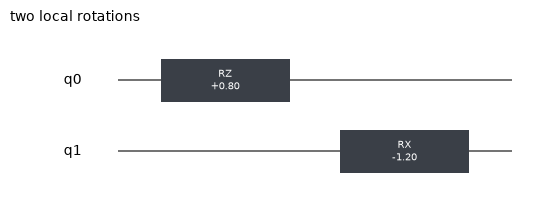

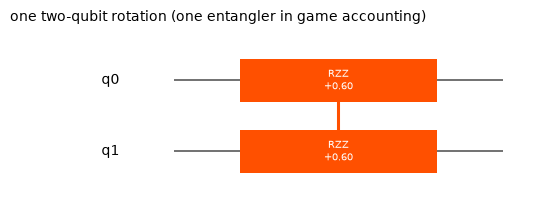

Time runs left to right. Continued panels are sequential. Angles are radians.


In [7]:
def draw_circuit(circuit, n=None, title=None, ax=None, hidden=None, labels=None):
    """Chronological gate-list picture; a pair of linked boxes is ONE two-qubit instruction."""
    circuit = tuple(circuit)
    if n is None:
        n = max((max(g.targets) for g in circuit), default=0) + 1
    if any(q < 0 or q >= n for g in circuit for q in g.targets):
        raise ValueError("A gate targets a qubit outside this drawing.")
    if labels is not None and len(labels) != len(circuit):
        raise ValueError("Each drawn gate needs one label.")
    if len(circuit) > 12:
        raise ValueError("Use draw_circuit_pages for more than 12 gates; do not squeeze a 72-gate circuit into one row.")
    offset = 1 if hidden else 0
    cols = max(1, len(circuit) + offset)
    if ax is None:
        _, ax = plt.subplots(figsize=(max(5.5, 1.6 + 1.05 * cols), 0.62 * n + 0.9))
    for q in range(n):
        ax.hlines(-q, -0.6, cols - 0.4, color="0.35", lw=1.2, zorder=1)
        ax.text(-0.8, -q, f"q{q}", ha="right", va="center", fontsize=10)
    if hidden:
        ax.add_patch(plt.Rectangle((-0.38, -n + 0.62), 0.76, n - 0.24, facecolor="#f0f1f2",
                                  edgecolor="#3a3f47", linestyle="--", lw=1.4, zorder=3))
        ax.text(0, -(n - 1) / 2, hidden, ha="center", va="center", fontsize=8, zorder=4)
    for k, g in enumerate(circuit):
        x = k + offset
        label = labels[k] if labels is not None else f"{g.name.upper()}\n{g.angle:+.2f}"
        tone = "#ff5000" if len(g.targets) == 2 else "#3a3f47"
        ys = [-t for t in g.targets]
        if len(ys) == 2:
            ax.vlines(x, min(ys), max(ys), color=tone, lw=2.2, zorder=2)
        for y in ys:
            ax.add_patch(plt.Rectangle((x-.36, y-.3), .72, .6, facecolor=tone, edgecolor="none", zorder=3))
            ax.text(x, y, label, ha="center", va="center", color="white", fontsize=7.5, zorder=4)
    ax.set(xlim=(-1.2, cols-.3), ylim=(-n+.4, .6))
    ax.axis("off")
    if title:
        ax.set_title(title, fontsize=10, loc="left", pad=12)
    ax.figure.tight_layout()
    return ax


def draw_circuit_pages(circuit, n, title="Circuit", labels=None, max_pages=None):
    """Twelve sequential gates per figure; continuation is not a parallel layer."""
    circuit = tuple(circuit)
    pages = max(1, math.ceil(len(circuit) / 12))
    shown = pages if max_pages is None else min(pages, max_pages)
    for page in range(shown):
        start, stop = 12*page, min(len(circuit), 12*(page+1))
        text = f"{title} — gates {start+1}–{stop} of {len(circuit)}" if circuit else title
        draw_circuit(circuit[start:stop], n, text, labels=None if labels is None else labels[start:stop])
        plt.show()
    if shown < pages:
        print(f"Showing {shown}/{pages} panels. Set max_pages=None to inspect the full chronological circuit.")


def draw_template(template, n, title=None, max_pages=1):
    """Label the exact affine parameter expression or declared uniform range."""
    gates, labels = [], []
    for spec in template["gates"]:
        gates.append(G(spec["name"], tuple(spec["targets"]), 0.0))
        parameter = spec.get("parameter")
        if parameter is not None:
            scale, offset = spec.get("scale", 1.0), spec.get("offset", 0.0)
            expression = f"{scale:g}·{parameter}" + (f"{offset:+g}" if offset else "")
        elif spec["low"] == spec["high"]:
            expression = f"{spec['low']:+.3f}"
        else:
            expression = f"[{spec['low']:+.2f}, {spec['high']:+.2f}]"
        labels.append(f"{spec['name'].upper()}\n{expression}")
    draw_circuit_pages(gates, n, title or template["name"], labels, max_pages)

for demo, label in [((G("rz", (0,), .8), G("rx", (1,), -1.2)), "two local rotations"),
                    ((G("rzz", (0,1), .6),), "one two-qubit rotation (one entangler in game accounting)")]:
    draw_circuit(demo, 2, label)
    plt.show()
print("Time runs left to right. Continued panels are sequential. Angles are radians.")


<a id="quickstart"></a>
## Your first 15 minutes — reveal a change, then undo it

Start the clock **after Setup works**, including **Choose the round** and **Drawing circuits**.
Leave `OFFLINE_ROUND = None` in an unbound copy for the inexpensive four-qubit practice profile.
No account or upload is needed. The setup cells define the imports, helpers, `LAB_RULES`, and workspace used below.

Follow this route in order; it uses the existing worked lesson:

| Time | Run these steps | What to notice |
|---|---|---|
| 0–3 min | Jump to **[Our practice opponent](#warmup-start)**. Run its code, **Method 1**, and **The impostor**. | The all-zero histogram can hide a real change. |
| 3–6 min | Run **Method 2** and **Method 3**, including their code cells. | X gives two possible signs; Y distinguishes them. |
| 6–10 min | Skip **See the phase response** and its scan for now. Run **[One ambiguity remains](#partner-question)** and its code. | Flipping the partner qubit distinguishes a local phase from a pair interaction. |
| 10–13 min | Run **Invert compactly**, then **Try the correction on another input**, including both code cells. | A correction is submitted and the local score is revealed after finishing. |
| 13–15 min | Run **[One edit that changes the correction](#quickstart-edit)**, change `PATCH_SIGN` as instructed, and rerun only that cell. | Your edit changes the patch actually submitted in a fresh local experiment. |

**Make one prediction before the partner experiment:** if the change acts only on q0, should flipping q1
reverse q0's Y response? Write one sentence in a note cell, then compare it with the printed results.

The circuit drawing and the sealed local result are your first win. You do not need the complete matrix
derivation yet. These exercises use the four-qubit laboratory even if a later download has a different entry profile.
If you restart the kernel, rerun Setup and this route in order. To repeat the original warm-up, start again at
**Our practice opponent**; an already finished local session cannot accept a new patch.


<a id="first-hour"></a>
### A first-hour checklist

- **First 15 minutes:** complete the recovery route above, record your prediction, and try the patch-sign edit.
- **15–30 minutes:** explain why Z alone missed the change and why the partner flip helped. Visit the relevant
  primer sections or the optional phase-response plot; start a fresh warm-up before adding experiments.
- **30–45 minutes:** open **[Part 4 — Prepare an entry](#entry)** and run its cells in order through the local smoke
  tests. Keep the supplied attacks at first. Read the printed `main.py`; the sign experiment is a local lesson,
  so its variable does not silently change that separate defender file.
- **45–60 minutes:** continue through **Test your attacks against your actual defender** and **Verify, then export**.
  Inspect both execution status and recovery points. Keep your generated ZIP and its validation report locally.

**What the checks mean:** `PASSED` means the program executed successfully on those local cases;
`valid_for_upload` means the archive passes the local checks; the server still revalidates an upload.
Neither is a promise of high recovery or official results.
A valid program can earn zero recovery points. Look at the checkpoint curve and keep the failures.

The export cell prints a link to the exact file:
`quantum_duel_work/<ruleset>/submission.zip`.
With the default four-qubit profile, that is
`quantum_duel_work/quantum-duel-4q-playtest-0.3/submission.zip`.
Keep `main.py` in that profile's `my_solution` directory and edit the two templates through the notebook.
If organizers open an **Orientation** round, you may upload **the ZIP** for validation and storage only:
no execution or prizes. Keep a local copy. When scored rounds are announced, use the matching round's
notebook and final rules. Upload the ZIP, not this notebook or the entire workspace.


<a id="primer"></a>
# Part 1 — A primer: just enough quantum mechanics to win a duel

Nothing in this part touches the competition. It builds, on one and two qubits, the five ideas the duel
depends on:

1. A qubit's state is a vector of two complex **amplitudes**; measurement probabilities are their squared sizes.
2. A gate is a **matrix**; rotation gates are the only ones the duel allows.
3. Measuring "in the X basis" or "in the Y basis" reveals phases that a plain Z measurement cannot see.
4. A Pauli measurement has ±1 outcomes; for independent samples its standard error decreases as $1/\sqrt{N}$. Some outcomes are deterministic.
5. Two qubits live in a 4-dimensional space where **entangling** gates make one qubit's behaviour depend on the other.

If these are old news, use the skip link at the top. Otherwise, work through the small examples before moving on.


## 1.1 A qubit is a vector; measuring it is a weighted coin

**What we do.** Write down four one-qubit states as NumPy vectors and compute the probability of reading
`0` or `1` from each.

**Why.** A classical bit *is* 0 or 1. A qubit is described by two complex numbers $(\alpha,\beta)$ — the
*amplitudes* of $|0\rangle$ and $|1\rangle$ — with $|\alpha|^2+|\beta|^2=1$. When you measure in the
standard (Z) basis you get `0` with probability $|\alpha|^2$ and `1` with probability $|\beta|^2$. This
is the **Born rule**, and it is the only bridge between the mathematics and anything you can observe.

**What to look for.** $|+\rangle$ and $|{-i}\rangle$ have *different* amplitudes but the *same* Z
probabilities (50/50). Keep that in mind: Z measurements are blind to some differences.


In [8]:
ket0 = np.array([1, 0], dtype=complex)            # |0>
ket1 = np.array([0, 1], dtype=complex)            # |1>
plus = (ket0 + ket1) / np.sqrt(2)                 # |+>   equal amplitudes, same sign
minus_i = (ket0 - 1j * ket1) / np.sqrt(2)         # |-i>  equal sizes, a relative phase of -i

def z_probabilities(state):
    """Born rule: probability of reading 0 or 1 when measuring in the Z (computational) basis."""
    p = np.abs(state) ** 2
    return {"0": round(float(p[0]), 4), "1": round(float(p[1]), 4)}

for name, state in (("|0>", ket0), ("|1>", ket1), ("|+>", plus), ("|-i>", minus_i)):
    print(f"{name:5s} amplitudes = {np.round(state, 3)}   Z probabilities = {z_probabilities(state)}")



|0>   amplitudes = [1.+0.j 0.+0.j]   Z probabilities = {'0': 1.0, '1': 0.0}
|1>   amplitudes = [0.+0.j 1.+0.j]   Z probabilities = {'0': 0.0, '1': 1.0}
|+>   amplitudes = [0.707+0.j 0.707+0.j]   Z probabilities = {'0': 0.5, '1': 0.5}
|-i>  amplitudes = [0.707+0.j    0.   -0.707j]   Z probabilities = {'0': 0.5, '1': 0.5}


## 1.2 Gates are matrices, and rotations are the only gates in this game

**What we do.** Build the Pauli matrices $X, Y, Z$ and the rotation
$$R_P(\theta) = e^{-i\theta P/2} = \cos\tfrac{\theta}{2}\,I - i\sin\tfrac{\theta}{2}\,P,$$
then apply $R_z(0.8)$ to $|0\rangle$ and to $|+\rangle$.

**Why.** A gate changes the state by matrix multiplication: new state $=U\cdot$ old state. The duel's whole
gate alphabet is six rotations: `rx`, `ry`, `rz` on one qubit and `rxx`, `ryy`, `rzz` on a pair. Each has
one real parameter, the angle. Identifying a useful correction means learning enough about the angles, axes, qubit locations,
and chronological order. The open final can contain up to 72 rotations; the existence of a compact
description does not guarantee recovery under the finite budget. The inverse of $R_P(\theta)$ is simply $R_P(-\theta)$.

**What to look for.** $R_z$ leaves the Z probabilities of *both* inputs untouched. On $|+\rangle$ it
changed the amplitudes — a relative phase appeared — but a Z measurement cannot see it. This is the seed of
the "impostor" problem in Part 2.


In [9]:
I1 = np.eye(2, dtype=complex)
X1 = np.array([[0, 1], [1, 0]], dtype=complex)
Y1 = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z1 = np.array([[1, 0], [0, -1]], dtype=complex)

def rotation(pauli, theta):
    """R_P(theta) = exp(-i theta P / 2) = cos(theta/2) I - i sin(theta/2) P"""
    return np.cos(theta / 2) * I1 - 1j * np.sin(theta / 2) * pauli

theta = 0.8
print("Rz(0.8) =\n", np.round(rotation(Z1, theta), 3))
after_zero = rotation(Z1, theta) @ ket0
after_plus = rotation(Z1, theta) @ plus
print("Rz on |0>: Z probabilities", z_probabilities(after_zero), "  <- unchanged; |0> only picked up a phase")
print("Rz on |+>: Z probabilities", z_probabilities(after_plus), "  <- also unchanged!")
print("Rz on |+>: amplitudes     ", np.round(after_plus, 3), "  <- but the relative phase moved")
print("Undo it: Rz(-0.8) Rz(0.8) =\n", np.round(rotation(Z1, -theta) @ rotation(Z1, theta), 6))


Rz(0.8) =
 [[0.921-0.389j 0.   +0.j   ]
 [0.   +0.j    0.921+0.389j]]
Rz on |0>: Z probabilities {'0': 1.0, '1': 0.0}   <- unchanged; |0> only picked up a phase
Rz on |+>: Z probabilities {'0': 0.5, '1': 0.5}   <- also unchanged!
Rz on |+>: amplitudes      [0.651-0.275j 0.651+0.275j]   <- but the relative phase moved
Undo it: Rz(-0.8) Rz(0.8) =
 [[1.-0.j 0.+0.j]
 [0.+0.j 1.+0.j]]


## 1.3 Measuring in X or Y: asking a different question

**What we do.** Compute the three **expectation values** $\langle X\rangle,\langle Y\rangle,\langle Z\rangle$
of the state $R_z(\theta)|+\rangle$ as $\theta$ sweeps from $-\pi$ to $\pi$, and plot them.

**Why.** Measuring "in the X basis" means asking *is the qubit $|+\rangle$ or $|-\rangle$?* instead of
*is it $|0\rangle$ or $|1\rangle$?* Physically the oracle rotates the qubit and then reads Z; mathematically
the outcome $+1$ or $-1$ has average $\langle X\rangle = \langle\psi|X|\psi\rangle$. For $R_z(\theta)|+\rangle$
the algebra gives
$$\langle X\rangle=\cos\theta,\qquad \langle Y\rangle=\sin\theta,\qquad \langle Z\rangle=0.$$
So the X readout reveals the *size* of the angle and the Y readout reveals its *sign*. Together,
$\theta=\operatorname{atan2}(\langle Y\rangle,\langle X\rangle)$. This pair of measurements is literally what
you will do to the hidden attack in Part 2.

**What to look for.** The dashed Z line is flat at zero for every $\theta$ — this Z-basis output carries no
information about the angle in this specific one-rotation experiment. The X curve alone is symmetric, so $\theta$ and $-\theta$ are
indistinguishable from it; the Y curve breaks that tie.


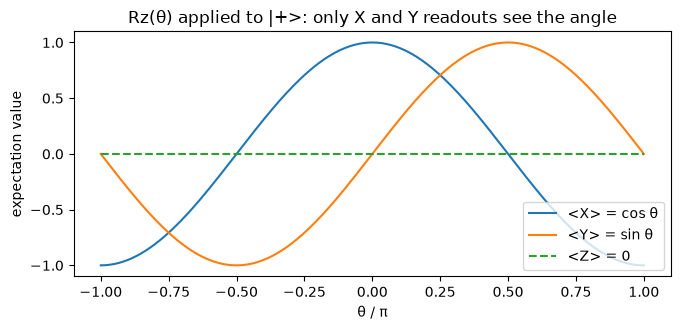

θ = 0.8:  <X> = 0.6967   <Y> = 0.7174   atan2(<Y>, <X>) = 0.8000


In [10]:
def expectation(state, observable):
    """<psi| O |psi>, real for Hermitian observables. Equals P(+1) - P(-1) of that measurement."""
    return float(np.vdot(state, observable @ state).real)

thetas = np.linspace(-np.pi, np.pi, 241)
sweep = {obs: [expectation(rotation(Z1, t) @ plus, M) for t in thetas] for obs, M in (("X", X1), ("Y", Y1), ("Z", Z1))}
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(thetas / np.pi, sweep["X"], label="<X> = cos θ")
ax.plot(thetas / np.pi, sweep["Y"], label="<Y> = sin θ")
ax.plot(thetas / np.pi, sweep["Z"], "--", label="<Z> = 0")
ax.set(xlabel="θ / π", ylabel="expectation value", ylim=(-1.1, 1.1),
       title="Rz(θ) applied to |+>: only X and Y readouts see the angle")
ax.legend(loc="lower right"); fig.tight_layout(); plt.show()
x_true = expectation(rotation(Z1, 0.8) @ plus, X1); y_true = expectation(rotation(Z1, 0.8) @ plus, Y1)
print(f"θ = 0.8:  <X> = {x_true:.4f}   <Y> = {y_true:.4f}   atan2(<Y>, <X>) = {math.atan2(y_true, x_true):.4f}")


## 1.4 Shot noise: why the budget matters

**What we do.** Pretend to measure X on $R_z(0.8)|+\rangle$ with 20, 200, 2 000 and 20 000 shots, many
times over, and record how much the *estimated* $\langle X\rangle$ wobbles.

**Why.** A real device never hands you $\langle X\rangle$. It hands you a list of $\pm1$ outcomes, and you
average them. Each shot is a biased coin flip with $P(+1)=(1+\langle X\rangle)/2$. For independent ±1 outcomes with true mean $\mu$, the average has standard error
$\sqrt{(1-\mu^2)/N}\leq1/\sqrt{N}$. A tenfold reduction in standard error needs one hundred times as many
shots at fixed $\mu$. Cup 1 gives 12,000 shots; the later rounds give 96,000. You cannot brute-force precision; you must choose experiments whose
answers *change your decision*.

**What to look for.** The measured spread tracks the $1/\sqrt{N}$ rule of thumb. Later residual tables use **pointwise Wilson intervals** for the underlying binomial proportions.
They are approximate intervals, not simultaneous coverage of the whole table and not a full-process
certificate. No observed failures does not imply zero uncertainty. See the
[NIST discussion](https://www.itl.nist.gov/div898/handbook/prc/section2/prc241.htm).


## 1.5 Two qubits, bitstrings, and the ordering trap

**What we do.** Switch to the SDK's own `G(...)` gate records and `unitary(...)`, flip qubit 0 with
$R_x(\pi)$ (an X gate up to global phase), and see which bitstring comes out. Then draw it.

**Why.** Two qubits have four basis states $|00\rangle,|01\rangle,|10\rangle,|11\rangle$ and a state is a
4-vector. Which position in the vector corresponds to which bitstring is a **convention**, and conventions
differ between frameworks. In Quantum Duel a bitstring reads **q0 q1 … q(n−1) from left to right**: q0 is the
leftmost character and the most-significant bit. Flipping q0 must give `10`, not `01`. Get this wrong and
every later inference will be about the wrong qubit.

**What to look for.** The printed bitstring for "flip q0" is `10`. If you ever bring in another SDK,
convert at its boundary once instead of reversing strings ad hoc.


Rx(π) on q0: outcome bitstring = 10   (positions = ['00', '01', '10', '11'])
Rx(π) on q1: outcome bitstring = 01   (positions = ['00', '01', '10', '11'])


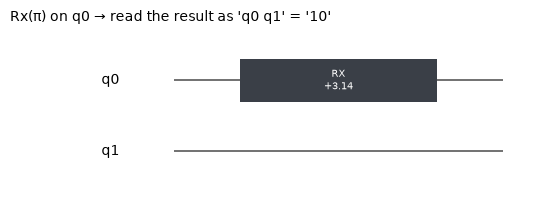

In [12]:
two_zero = np.eye(4, dtype=complex)[:, 0]        # |00>
flip_q0 = (G("rx", (0,), np.pi),)
flip_q1 = (G("rx", (1,), np.pi),)
for name, circuit in (("Rx(π) on q0", flip_q0), ("Rx(π) on q1", flip_q1)):
    p = np.abs(unitary(circuit, 2) @ two_zero) ** 2
    print(f"{name}: outcome bitstring = {bitstrings(2)[int(np.argmax(p))]}   (positions = {list(bitstrings(2))})")
draw_circuit(flip_q0, 2, "Rx(π) on q0 → read the result as 'q0 q1' = '10'"); plt.show()


## 1.6 An entangling rotation: when one qubit's answer depends on another

**What we do.** Compare a local $R_z(0.8)$ on q0 with a two-qubit $R_{zz}(0.8)$ on (q0, q1). For each,
prepare q0 in $|+\rangle$ and q1 in either $|0\rangle$ or $|1\rangle$, then compute $\langle Y_0\rangle$.

**Why.** $R_{zz}(\theta)=e^{-i\theta Z\otimes Z/2}$. When q1 is $|0\rangle$, its $Z$ eigenvalue is $+1$ and
q0 experiences $R_z(+\theta)$. When q1 is $|1\rangle$, the eigenvalue is $-1$ and q0 experiences
$R_z(-\theta)$. So the **sign of $\langle Y_0\rangle$ flips when you flip q1's input** — for the local gate
it does not. This is the fingerprint that separates "a phase on one qubit" from "an interaction between
two", and it is the decisive experiment of Part 2.

**What to look for.** The table has one row where the two Y values agree and one where they are opposite.
The diagrams show that the two circuits *look* nothing alike, yet on the $|+0\rangle$ input they are
indistinguishable. Only the second input tells them apart.


Hidden gate,<Y0> with q1 = |0>,<Y0> with q1 = |1>
local Rz(0.8) on q0,0.7174,0.7174
"Rzz(0.8) on q0,q1",0.7174,-0.7174


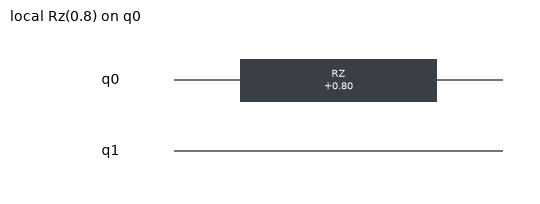

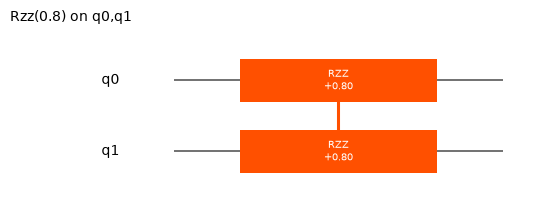

In [13]:
plus0 = np.kron(plus, ket0)                       # |+0>
plus1 = np.kron(plus, ket1)                       # |+1>
Y_on_q0 = np.kron(Y1, I1)
candidates = (("local Rz(0.8) on q0", (G("rz", (0,), 0.8),)), ("Rzz(0.8) on q0,q1", (G("rzz", (0, 1), 0.8),)))
rows = []
for name, circuit in candidates:
    u = unitary(circuit, 2)
    rows.append({"gate": name, "y0": round(expectation(u @ plus0, Y_on_q0), 4), "y1": round(expectation(u @ plus1, Y_on_q0), 4)})
show_rows(rows, [("gate", "Hidden gate"), ("y0", "<Y0> with q1 = |0>"), ("y1", "<Y0> with q1 = |1>")])
for name, circuit in candidates:
    draw_circuit(circuit, 2, name)
    plt.show()


## 1.7 A process, its inverse, and why order matters

**What we do.** Build a three-gate circuit, ask the SDK for its exact inverse, and check that
inverse ∘ attack has zero process infidelity. Then try the tempting shortcut — negate every angle but keep
the order — and watch it fail.

**Why.** A circuit is a product of matrices, applied right-to-left in time: $U = G_3 G_2 G_1$. Its inverse
is $U^{-1} = G_1^{-1} G_2^{-1} G_3^{-1}$: **reverse the order and invert each gate**. Gates on different
qubits commute, so sometimes the shortcut accidentally works — but an $R_x$ on q1 and a generic $R_{zz}$ touching q1
do not commute (an $R_z$ on q1 would commute), and then order is everything.

The judge's score, `infidelity(P @ A)`, is exactly this check on the full $2^n\times2^n$ matrix (4×4 in this two-qubit example). Zero means
the patch undoes the attack on **every** input; that is what "process" means, as opposed to "state".

**What to look for.** The exact inverse scores 0.0. The wrong-order version scores something clearly
nonzero even though it uses the "right" angles.


Attack : [{'name': 'rz', 'targets': [0], 'angle': 0.5}, {'name': 'rzz', 'targets': [0, 1], 'angle': -0.9}, {'name': 'rx', 'targets': [1], 'angle': 1.1}]
Inverse: [{'name': 'rx', 'targets': [1], 'angle': -1.1}, {'name': 'rzz', 'targets': [0, 1], 'angle': 0.9}, {'name': 'rz', 'targets': [0], 'angle': -0.5}]
Process infidelity of inverse ∘ attack: 0.0
Negate angles but keep the order:    0.1961


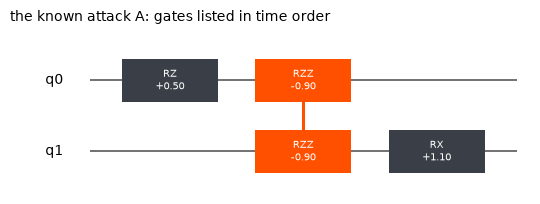

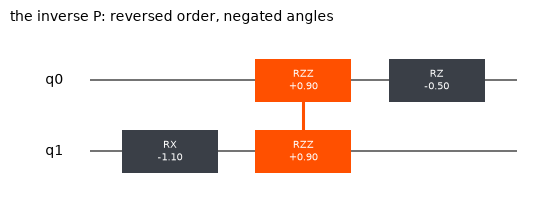

In [14]:
attack_demo = (G("rz", (0,), 0.5), G("rzz", (0, 1), -0.9), G("rx", (1,), 1.1))
undo_demo = inverse(attack_demo)
print("Attack :", circuit_data(attack_demo))
print("Inverse:", circuit_data(undo_demo))
print("Process infidelity of inverse ∘ attack:", round(infidelity(unitary(undo_demo, 2) @ unitary(attack_demo, 2)), 12))
wrong_order = tuple(G(g.name, g.targets, -g.angle) for g in attack_demo)   # negated angles, NOT reversed
print("Negate angles but keep the order:   ", round(infidelity(unitary(wrong_order, 2) @ unitary(attack_demo, 2)), 4))
draw_circuit(attack_demo, 2, "the known attack A: gates listed in time order"); plt.show()
draw_circuit(undo_demo, 2, "the inverse P: reversed order, negated angles"); plt.show()


## 1.8 Primer summary — the toolkit you now own

| Idea | Tool | Where it bites in the duel |
|---|---|---|
| Amplitudes → probabilities | Born rule, `np.abs(state)**2` | Every count table |
| Rotations are the alphabet | $R_P(\theta)$, inverse is $R_P(-\theta)$ | Attack limits, patch limits |
| Z readout is blind to Z phases | measure X for $\cos\theta$, Y for $\sin\theta$ | Methods 1–3 |
| Precision costs $N$ shots for $1/\sqrt N$ | Wilson intervals | Round-dependent shot budget |
| Bitstrings read q0 q1 … q(n−1) | `bitstrings(n)`, masks | Every histogram |
| $R_{zz}$ flips sign with the partner qubit | compare $\langle Y_0\rangle$ for q1 = 0 and 1 | The impostor test |
| Inverse = reverse order, negate angles | `inverse(...)`, `infidelity(P @ A)` | Scoring |

Now we put the same ideas to work on four qubits against a real (if friendly) opponent.


<a id="duel"></a>
# Part 2 — The duel begins

## Reconnaissance — what is public

**What we do.** Print the contract: register size, gate alphabet, budgets and limits, straight from the
rules embedded in this notebook.

**Why.** Everyone receives the same vocabulary and the same budget. What is *not* disclosed during a rated
encounter is the attack's architecture, targets, ordering and angles. Knowing the limits constrains the search: Cup 1 allows up to 12 gates/four entanglers; the later
rounds allow 72/24, with a strict structure only in Cup 2. The public
practice families you will meet are examples, not the complete set an opponent may submit.

**What to look for.** The checkpoint list. Your shots arrive in three equal blocks; a correction is sealed
at the end of each. The three profiles are published in advance. The selected round download embeds its exact contract;
re-download and re-export before entering a different round. Do not edit frozen rules to make a ZIP pass.


In [15]:
show_rows([
    {"item": "Register / target", "value": f"{RULES.qubits} qubits / identity process"},
    {"item": "Attack", "value": f"2 templates; {RULES.attack_max_gates} gates / {RULES.attack_max_entanglers} entanglers each"},
    {"item": "Patch", "value": f"{RULES.patch_max_gates} gates / {RULES.patch_max_entanglers} entanglers"},
    {"item": "Alphabet", "value": ", ".join(RULES.alphabet)},
    {"item": "Samples", "value": RULES.total_shots},
    {"item": "Physical settings / action requests", "value": f"{RULES.max_settings} / {RULES.max_requests}"},
    {"item": "Cumulative checkpoints", "value": [RULES.block * k for k in range(1, RULES.checkpoints + 1)]},
    {"item": "Full-credit / zero-credit error", "value": f"{RULES.good_error} / {RULES.bad_error}"},
], [("item", "Rule"), ("value", "Value")])
print("Round context:", ROUND_CONTEXT or "Offline profile: compare it with the target round before upload.")
print("The next warm-up uses separate LAB_RULES: four qubits, 12,000 shots, 180 settings.")


Rule,Value
Register / target,4 qubits / identity process
Attack,2 templates; 12 gates / 4 entanglers each
Patch,18 gates / 6 entanglers
Alphabet,"rx, ry, rz, rxx, ryy, rzz"
Samples,12000
Physical settings / action requests,180 / 600
Cumulative checkpoints,"[4000, 8000, 12000]"
Full-credit / zero-credit error,0.001 / 0.1


Round context: Offline profile: compare it with the target round before upload.
The next warm-up uses separate LAB_RULES: four qubits, 12,000 shots, 180 settings.


## First, bit ordering — once more, on four qubits

**What we do.** Flip q0 of $|0000\rangle$ with $R_x(\pi)$ and confirm the SDK reports `1000`.

**Why.** Section 1.5 made the point on two qubits; here we lock it in on the real register and with the
real helper functions before interpreting a single histogram. The `assert` is deliberate: if a future SDK
ever changed convention, this cell would stop you before you misread everything downstream.

**What to look for.** `1000`, and the diagram showing the gate on the *top* wire.


q0 flipped -> integer 8 -> bitstring 1000
Angles are radians. Lists are time order; matrix products act right to left.


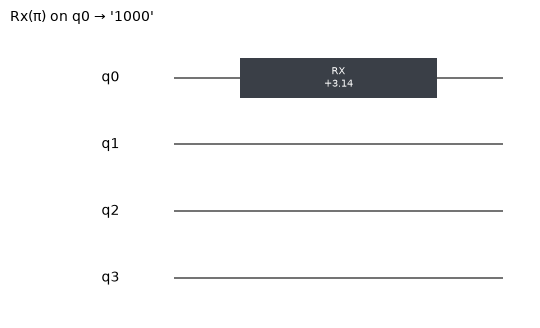

In [16]:
N = LAB_RULES.qubits
zero = np.eye(1 << N, dtype=complex)[:, 0]
known_demo = (G("rx", (0,), np.pi),)  # X up to global phase; legal rotation alphabet.
known_probabilities = np.abs(unitary(known_demo, N) @ zero) ** 2
index = int(np.argmax(known_probabilities))
print("q0 flipped -> integer", index, "-> bitstring", format(index, f"0{N}b"))
assert format(index, f"0{N}b") == "1" + "0" * (N - 1)
print("Angles are radians. Lists are time order; matrix products act right to left.")
draw_circuit(known_demo, N, "Rx(π) on q0 → '1000'"); plt.show()


<a id="warmup-start"></a>
## Our practice opponent

**What we do.** Open a **local laboratory** around a small teaching attack and get a `probe` client that
speaks the exact same protocol as the competition oracle: `query_experiment`, `submit_patch`,
`close_checkpoint`, `finish`.

**Why.** This warm-up has one phase fault. We will test two explanations: a local $R_z$ on qubit 0, or a
$ZZ$ interaction between qubits 0 and 1; the other qubits are idle. The family hint is a courtesy for this
onboarding case only — the real open-final opponent makes no such promise. Cup 2 instead promises the larger frame grammar,
not this one-gate family. This lesson is not an admissible Cup 2 attack template.

The attack is a Python variable in the next cell, so of course you *could* peek. Don't. The whole exercise
is to recover it from counts alone, and to compare with the reference only after sealing. Hiding a variable
is not a security boundary; the discipline is yours.

**What to look for.** The "current shot allowance" — that is the first block of the budget. We define three
shot sizes for the experiments ahead so the whole warm-up fits in that block with room to spare.


In [20]:
N = LAB_RULES.qubits  # The quickstart may skip the earlier bit-order demonstration.
zero = np.eye(1 << N, dtype=complex)[:, 0]  # |0000>, also used in the impostor comparison.
WARMUP_ATTACK = (G("rzz", (0, 1), -0.68),)  # Public teaching fixture; not solver input. Don't peek.
lab = LocalSession(WARMUP_ATTACK, LAB_RULES, seed=103)
probe = lab.client()
SMALL_SHOTS = max(1, LAB_RULES.block // 10)
PROBE_SHOTS = max(1, LAB_RULES.block // 5)
SCAN_SHOTS = max(1, LAB_RULES.block // 40)
print("Current shot allowance:", probe.status()["available_now"])
print("Shot sizes we will use:", {"small": SMALL_SHOTS, "probe": PROBE_SHOTS, "scan": SCAN_SHOTS})
print("No private score is available until this local encounter is finished.")


Current shot allowance: 4000
Shot sizes we will use: {'small': 400, 'probe': 800, 'scan': 100}
No private score is available until this local encounter is finished.


## Method 1 — the do-nothing experiment

**What we do.** Prepare $|0000\rangle$, apply no analysis circuit, measure every qubit in Z.

**Why.** It is the cheapest question you can ask: *does the process move population out of the all-zeros
state at all?* If population moved, we would know this input changed—but interference and entanglement mean
that one histogram does not identify which physical gates caused it.
Each shot still costs one use of the hidden operation, so we spend only a small batch.

**What to look for.** The table lists only bitstrings that actually occurred. Expect essentially all the
weight on `0000`. Resist the urge to conclude "nothing happened" — read the next section first.


In [21]:
population = probe.query_experiment(["0"] * N, "Z" * N, SMALL_SHOTS, "warmup-population")
show_rows([{"bits": bits, "count": count, "frequency": round(count / SMALL_SHOTS, 3)}
           for bits, count in population["counts"].items() if count],
          [("bits", "q0 … q3"), ("count", "Count"), ("frequency", "Frequency")])
print("P(all zero), estimated:", population["counts"]["0" * N] / SMALL_SHOTS)


q0 … q3,Count,Frequency
0000,400,1.0


P(all zero), estimated: 1.0


## The impostor — a perfect-looking histogram is not a perfect process

**What we do.** Take three *public* candidate explanations — identity, a local phase, a pair interaction —
and compute what each predicts for Method 1. Then draw them.

**Why.** All three leave $|0000\rangle$ exactly where it is, because $|0000\rangle$ is an eigenstate of
$Z$-type rotations (Section 1.2). So Method 1 *cannot* distinguish them. Three genuinely different processes,
one identical histogram. If we stopped here and submitted "no correction", the judge — who tests **every**
input — would find the fault immediately.

This is the single most important lesson of the notebook: **a recovered state is not a recovered process.**
To make a phase observable we need an input that is *not* an eigenstate — a superposition.

**What to look for.** Three identical `P(0000) = 1.000` lines above three visibly different diagrams.


identity             P(0000) = 1.000


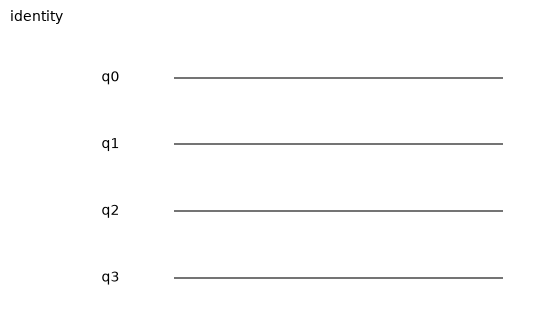

local phase          P(0000) = 1.000


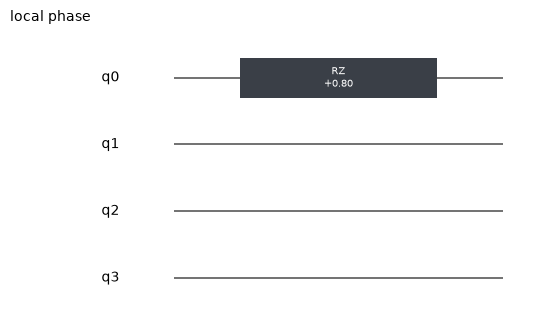

pair interaction     P(0000) = 1.000


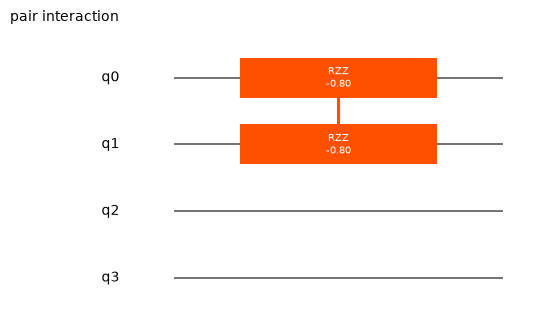

Same observed state. Different operations on other inputs.


In [26]:
hypotheses = {
    "identity": (),
    "local phase": (G("rz", (0,), 0.8),),
    "pair interaction": (G("rzz", (0, 1), -0.8),),
}
for name, circuit in hypotheses.items():
    p = np.abs(unitary(circuit, N) @ zero) ** 2
    print(f"{name:20s} P(0000) = {p[0]:.3f}")
    draw_circuit(circuit, N, name)
    plt.show()
print("Same observed state. Different operations on other inputs.")


## Method 2 — a superposition reveals the angle's magnitude

**What we do.** Prepare $|{+}000\rangle$ (q0 in $|+\rangle$, the rest in $|0\rangle$) and measure X on q0,
Z on the others.

**Why.** Section 1.3 showed that for a Z-type rotation on q0,
$$\langle X_0\rangle=\cos\theta .$$
This holds for *both* remaining hypotheses when q1 is $|0\rangle$, so one experiment serves both. From the
measured $\langle X_0\rangle$ we get $|\theta|$ — but $\cos$ is even, so not the sign.

Each returned bitstring has four bits; we want only q0's. `expectation_from_counts(counts, mask)` turns
bit 0 into $\pm1$ (0 → +1, 1 → −1) and averages. The mask `1 << (N - 1)` selects the leftmost bit, q0.
The other three bits came for free and could answer other questions later.

**What to look for.** A measured $\langle X_0\rangle$ well below 1 (so *something* rotated q0), and two
candidate angles that differ only in sign.


In [28]:
Q0_MASK = 1 << (N - 1)
input_plus = ["+", "0"] + ["0"] * (N - 2)
cosine = probe.query_experiment(input_plus, "X" + "Z" * (N - 1), PROBE_SHOTS, "warmup-cosine")
x_hat = expectation_from_counts(cosine["counts"], Q0_MASK)
magnitude = float(np.arccos(np.clip(x_hat, -1, 1)))
print("Measured X:", round(x_hat, 4))
print("Two possible signs:", round(magnitude, 4), "or", round(-magnitude, 4), "radians")


Measured X: 0.7675
Two possible signs: 0.6959 or -0.6959 radians


## Method 3 — change the question to resolve the sign

**What we do.** Same input $|{+}000\rangle$, but now measure **Y** on q0.

**Why.** More X shots would sharpen $\cos\theta$ and still never separate $\theta$ from $-\theta$. That is
the budget lesson from Section 1.4 in action: repeating the wrong observable buys nothing. The Y readout
gives $\langle Y_0\rangle=\sin\theta$, and
$$\hat\theta=\operatorname{atan2}\big(\widehat{\langle Y_0\rangle},\,\widehat{\langle X_0\rangle}\big)$$
returns a signed angle in $(-\pi,\pi]$. Choosing Y here is an **experimental-design decision**, not a
request for a score.

**What to look for.** A signed estimate whose magnitude agrees with Method 2 within noise.


In [ ]:
sine = probe.query_experiment(input_plus, "Y" + "Z" * (N - 1), PROBE_SHOTS, "warmup-sine")
y_hat = expectation_from_counts(sine["counts"], Q0_MASK)
theta_single = float(np.arctan2(y_hat, x_hat))
print("Measured Y:", round(y_hat, 4))
print("Signed estimate:", round(theta_single, 5), "radians")


### See the phase response, rather than trusting one number

**What we do.** Append a *known* $R_z(\phi)$ on q0 as an **analysis circuit** — it runs *after* the hidden
attack, *before* the readout — and sweep $\phi$ over nine values, measuring X each time.

**Why.** Both remaining hypotheses predict $\langle X_0\rangle=\cos(\theta+\phi)$. Plotting the measured
points against the curve *predicted from our own estimate* $\hat\theta$ is a model check: if the points
hug the curve, our picture of a single Z-type phase on q0 is consistent. The superposition X/Y measurements estimate a phase under the current two-hypothesis model;
this scan checks its predicted response without yet distinguishing local phase from coupling. Note the cost: every distinct analysis
circuit is a new physical **setting**, and settings are budgeted (180 in total), so we use tiny shot counts.

**What to look for.** Error bars (Wilson intervals) that straddle the prediction at most points. The
diagram below the plot shows where the analysis gate sits relative to the hidden box.


In [ ]:
scan = np.linspace(-np.pi, np.pi, 9)
fringe = []
for k, phi in enumerate(scan):
    receipt = probe.query_experiment(input_plus, "X" + "Z" * (N - 1), SCAN_SHOTS,
                                    f"warmup-fringe-{k}", analysis_patch=(G("rz", (0,), float(phi)),))
    item = next(r for r in measured_residuals(receipt) if r["pauli"] == "X" + "I" * (N - 1))
    fringe.append({"phi": float(phi), **item})
fine = np.linspace(-np.pi, np.pi, 200)
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(fine / np.pi, np.cos(theta_single + fine), label="Prediction from measured angle")
ys = np.array([r["observed"] for r in fringe])
# measured_residuals returns residual intervals: add the known identity expectation back.
lo = np.array([r["interval_low"] + r["target"] for r in fringe])
hi = np.array([r["interval_high"] + r["target"] for r in fringe])
ax.errorbar(scan / np.pi, ys, yerr=np.maximum(0, [ys - lo, hi - ys]), fmt="o", capsize=3,
            label="Measured ± pointwise Wilson interval")
ax.set(xlabel="Applied analysis angle / π", ylabel="X expectation", ylim=(-1.15, 1.15),
       title="A phase response built from finite shots")
ax.legend(); fig.tight_layout(); plt.show()
draw_circuit((G("rz", (0,), 0.0),), N, "prepare |+000> → hidden attack → analysis Rz(φ) on q0 → measure X Z Z Z",
             hidden="hidden\nattack\nA", labels=["Rz\nφ"]); plt.show()


<a id="partner-question"></a>
## One ambiguity remains — local phase or an interaction?

**What we do.** Flip the *input* of q1 from $|0\rangle$ to $|1\rangle$ — prepare $|{+}100\rangle$ — and
repeat the Y measurement on q0.

**Why.** So far q1 was always $|0\rangle$, and on that input $R_z^{(0)}(\theta)$ and
$R_{zz}^{(0,1)}(\theta)$ act identically on q0 (Section 1.6). A beautiful phase fit is therefore **not yet
a process identification** — we have a second impostor. The partner-flip experiment is decisive: a local
rotation gives the *same* $\langle Y_0\rangle$; a $ZZ$ interaction gives the *opposite sign*. We then
combine both Y measurements into one improved sine estimate (averaging, with the sign convention of the
chosen model) and recompute $\hat\theta$.

**What to look for.** Two Y values with clearly opposite signs → "ZZ interaction"; same sign → "local Z".
The final angle estimate should be close to the Method 3 value but a little steadier.


In [ ]:
input_partner_one = ["+", "1"] + ["0"] * (N - 2)
partner = probe.query_experiment(input_partner_one, "Y" + "Z" * (N - 1), PROBE_SHOTS, "warmup-partner")
y_partner = expectation_from_counts(partner["counts"], Q0_MASK)
is_pair = y_hat * y_partner < 0
sine_combined = (y_hat - y_partner) / 2 if is_pair else (y_hat + y_partner) / 2
theta_hat = float(np.arctan2(sine_combined, x_hat))
print("Y with q1=0:", round(y_hat, 4), "  Y with q1=1:", round(y_partner, 4))
print("Selected explanation:", "ZZ interaction" if is_pair else "local Z rotation")
print("Angle estimate:", round(theta_hat, 5), "radians")


## Invert compactly — and seal the first correction

**What we do.** Build the one-gate inverse of the model we selected — $R_{zz}(-\hat\theta)$ or
$R_z(-\hat\theta)$ — check it against the patch limits, submit it, and close checkpoint 1.

**Why.** For $R_P(\theta)=e^{-i\theta P/2}$ the inverse is $R_P(-\theta)$ (Section 1.7). One gate is all we
need. A **checkpoint** freezes your current best answer; the judge later scores each checkpoint's patch and
averages, so getting a decent patch in *early* matters. Closing before the block's shots are used up
**forfeits** the remainder — they do not roll over. We spent well under the block on purpose, so that
forfeit is the price of finishing early, not a mistake.

**What to look for.** `Resources` shows 1 gate, 1 entangler (or 0) — far inside the 18/6 limit. The
next-block allowance resets to a full block.


In [ ]:
patch = (G("rzz", (0, 1), -theta_hat),) if is_pair else (G("rz", (0,), -theta_hat),)
print("Correction:", circuit_data(patch))
print("Resources:", validate(patch, **LAB_RULES.validation_kwargs("patch")))
print("Unspent shots forfeited in this block:", probe.status()["available_now"])
probe.submit_patch(patch, "Counts-only phase and interaction estimate")
probe.close_checkpoint()
print("Next block allowance:", probe.status()["available_now"])
draw_circuit(patch, N, "our correction P (what we just sealed)"); plt.show()


## Try the correction on another input, then finish and compare

**What we do.** Run one more experiment on a deliberately odd input, $|{+}1{+i}0\rangle$, with our patch
as the analysis circuit, so the oracle executes *patch after attack*. Then `finish()` the encounter, read the
local score, and — only now — reveal the reference attack next to our patch.

**Why.** A second input is a diagnostic, not a proof: if the residuals (observed minus identity target) are
near zero on an input we never used for fitting, that is supporting evidence on this new input, not a proof of generalisation. The real verdict comes from the
local judge, which evaluates the full 16×16 process at every checkpoint. `finish()` carries the last valid
patch through the remaining checkpoints, which is exactly what the competition runner does if your program
returns early.

**What to look for.** Residuals within their intervals of zero. Three checkpoint rows with (nearly) equal
recovery points, since the same patch was in force throughout. And the reveal: attack and correction should
be the same gate on the same pair with opposite angles.


In [ ]:
check_input = ["+", "1", "+i", "0"]
check = probe.query_experiment(check_input, "XZYZ", max(1, LAB_RULES.block // 8),
                              "warmup-corrected-check", analysis_patch=patch)
show_rows(measured_residuals(check)[-5:],
          [("pauli", "Observable"), ("observed", "Measured"), ("target", "Identity target"), ("residual", "Difference"), ("interval_low", "95% low"), ("interval_high", "95% high")])
probe.finish()  # Carries the last valid patch through the remaining checkpoints.
warmup_result = lab.result()
show_rows(warmup_result["checkpoint_scores"],
          [("stage", "Checkpoint"), ("spent_shots", "Shots used"),
           ("process_infidelity", "Process infidelity"), ("recovery_points", "Recovery points")])
print("Reference revealed after finishing:", circuit_data(WARMUP_ATTACK))
draw_circuit(WARMUP_ATTACK, N, "the attack A, revealed after finishing"); plt.show()
draw_circuit(patch, N, "our correction P — opposite estimated angle"); plt.show()


<a id="quickstart-edit"></a>
## One edit that changes the correction

The first run below deliberately applies the estimated rotation with the **same sign**.
Predict whether that will help or hurt, then run it. Change `PATCH_SIGN = +1` to `PATCH_SIGN = -1`
and rerun only this cell. Compare **process infidelity** as well as points: the zero-point region can hide
the difference between two inaccurate corrections.

Every run creates a fresh local session, takes the same three kinds of measurement, derives an estimate from
the returned counts, submits your chosen patch, and finishes before showing its score. The sign is actually
used by `submit_patch`; it is not a display setting. This is a small teaching experiment, not a replacement
for the separate `main.py` you will package in Part 4.


In [ ]:
PATCH_SIGN = +1  # Deliberate experiment: change to -1, then rerun this cell only.
if PATCH_SIGN not in (-1, 1):
    raise ValueError("Choose +1 or -1 for this sign experiment.")
sign_lab = LocalSession(WARMUP_ATTACK, LAB_RULES, seed=103)
sign_client = sign_lab.client()
sign_mask = 1 << (LAB_RULES.qubits - 1)
sign_input = ["+", "0"] + ["0"] * (LAB_RULES.qubits - 2)
sign_partner = ["+", "1"] + ["0"] * (LAB_RULES.qubits - 2)
sign_shots = LAB_RULES.block // 5
sign_x = sign_client.query_experiment(sign_input, "XZZZ", sign_shots, "sign-x")
sign_y = sign_client.query_experiment(sign_input, "YZZZ", sign_shots, "sign-y")
sign_y1 = sign_client.query_experiment(sign_partner, "YZZZ", sign_shots, "sign-partner")
sign_x_hat = expectation_from_counts(sign_x["counts"], sign_mask)
sign_y_hat = expectation_from_counts(sign_y["counts"], sign_mask)
sign_y1_hat = expectation_from_counts(sign_y1["counts"], sign_mask)
sign_is_pair = sign_y_hat * sign_y1_hat < 0
sign_sine = (sign_y_hat - sign_y1_hat) / 2 if sign_is_pair else (sign_y_hat + sign_y1_hat) / 2
sign_angle = float(np.arctan2(sign_sine, sign_x_hat))
sign_patch = (G("rzz", (0, 1), PATCH_SIGN * sign_angle),) if sign_is_pair else (G("rz", (0,), PATCH_SIGN * sign_angle),)
sign_client.submit_patch(sign_patch, "Local experiment: chosen correction sign")
sign_client.finish()
sign_result = sign_lab.result()
print("Chosen sign:", PATCH_SIGN, "  Submitted patch:", circuit_data(sign_patch))
print("Local process infidelity:", sign_result["checkpoint_scores"][0]["process_infidelity"])
print("Local recovery points:", sign_result["recovery_points"], "  Shots:", sign_result["spent_shots"])


## Why a legal circuit matters — the wasteful inverse

**What we do.** Make a *copy* of our patch padded with enough cancelling rotations on q3 to exceed the laboratory limit. Prove it is
the same operation, then show the validator rejects it.

**Why.** Quantum Duel has **hard** limits (18 gates, 6 entanglers for a patch), not a soft cost penalty.
Two circuits can be mathematically identical and still differ in legality. A high local score or a
"passed" report you generated yourself never overrides the server's own check. Your working patch is
untouched by this experiment.

**What to look for.** `allclose` passes (identical unitaries); `validate` raises with the gate count.
The diagram makes the waste obvious.


In [ ]:
cancelling_pair = (G("rz", (N - 1,), 0.2), G("rz", (N - 1,), -0.2))
wasteful = patch + cancelling_pair * (LAB_RULES.patch_max_gates // 2 + 1)
assert np.allclose(unitary(wasteful, N), unitary(patch, N), atol=1e-10)
print("Compact gates:", len(patch), "  Wasteful gates:", len(wasteful))
try:
    validate(wasteful, **LAB_RULES.validation_kwargs("patch"))
except ValueError as error:
    print("Equivalent operation, invalid circuit:", error)
else:
    raise AssertionError("The deliberately over-budget example should have been rejected.")
draw_circuit_pages(wasteful, N, f"same unitary, {len(wasteful)} gates: over the {LAB_RULES.patch_max_gates}-gate limit", max_pages=1)


## The score — accuracy now and accuracy later

**What we do.** Implement the points formula from the rules and evaluate it at three errors. Then compute
an example match between two teams.

**Why.** Recovery points map process infidelity onto 0–100 on a **logarithmic** scale between the
full-credit error (0.001) and the zero-credit error (0.1): every factor-of-10 improvement in error is worth
the same number of points. An encounter's recovery is the *average* over the three checkpoints, so a good
early patch earns points three times. In a match, your **defence** is your recovery against their attack;
your **offence** is 100 minus their recovery against yours. The official total weights them equally.

**What to look for.** The midpoint error (geometric mean of the thresholds) scores exactly 50. Recovery
points are **not** a percentage fidelity.


In [ ]:
def recovery_points(error):
    if error <= RULES.good_error: return 100.0
    if error >= RULES.bad_error: return 0.0
    return 100 * math.log(RULES.bad_error / error) / math.log(RULES.bad_error / RULES.good_error)

for error in (RULES.bad_error, math.sqrt(RULES.good_error * RULES.bad_error), RULES.good_error):
    print(f"Process infidelity {error:.5g} -> {recovery_points(error):.1f} recovery points")
# In a reciprocal match, these are recovery points, not quantum fidelities.
alice_recovery, bob_recovery = 65.0, 45.0
print("Example match:", (alice_recovery + 100 - bob_recovery) / 2, "vs", (bob_recovery + 100 - alice_recovery) / 2)
errs = np.logspace(-4, 0, 200)
fig, ax = plt.subplots(figsize=(6.5, 3))
ax.semilogx(errs, [recovery_points(e) for e in errs])
ax.axvline(RULES.good_error, ls=":", color="0.5"); ax.axvline(RULES.bad_error, ls=":", color="0.5")
ax.set(xlabel="process infidelity (log scale)", ylabel="recovery points", title="Points fall linearly in log(error)")
fig.tight_layout(); plt.show()


### The same experiment twice: retry or new data?

**What we do.** In a separate local session, send two experiments as one batch and retry the identical batch.
Then try to reuse an ID with changed contents.

**Why.** An ambiguous network response must not charge you twice or give you free new randomness.
The same request ID and identical payload return the same receipt. A genuinely new experiment needs a new ID.
Batches contain at most **32 queries**; each item still consumes its own shot and action budget. Every new
(preparation, actual analysis circuit, readout) combination counts as a setting. A failed batch rolls back
as a whole and cannot cross a checkpoint boundary.

**What to look for.** The second identical request spends no additional shots. Reusing an ID with different
contents is rejected. Batching is useful only when the experiments need not depend on each other's answers.


In [ ]:
batch_lab = LocalSession(WARMUP_ATTACK, LAB_RULES, seed=241)
batch_client = batch_lab.client()
requests = [
    {"request_id": "batch-x", "experiment_index": experiment_index(["+", "0", "0", "0"], "XZZZ", 4), "shots": 64},
    {"request_id": "batch-y", "experiment_index": experiment_index(["+", "0", "0", "0"], "YZZZ", 4), "shots": 64},
]
first = batch_client.query_batch(requests)
spent = batch_client.status()["spent_shots"]
second = batch_client.query_batch(copy.deepcopy(requests))
assert first == second and batch_client.status()["spent_shots"] == spent == 128
print("Identical retry: 128 shots total, not 256.")
try:
    batch_client.query_batch([{**requests[0], "shots": 65}])
except ValueError as exc:
    print("Changed payload rejected:", exc)
else:
    raise AssertionError("Changed payload unexpectedly accepted")
assert batch_client.status()["spent_shots"] == 128
batch_client.finish()


<a id="tournaments"></a>
# Part 3 — One game, three tournament profiles

**What we do.** Compare the rules from the same public registry used by the portal.

**Why.** Cup 1 is an open four-qubit problem. Cup 2 promises a particular eight-qubit frame structure.
The championship removes that promise and permits any bounded eight-qubit rotation sequence.
The matrix size and observation count increase, but the objective remains $PA\approx I$.
Neither more qubits nor a longer circuit guarantees greater difficulty. In particular, the supplied
frame learner is specialized; it is not an established general solver for the open final.

**What to look for.** Cup 2 says **exactly** 72 gates; the final says **up to** 72. All three use the same
six rotation types. Entangler counts are abstract game resources, not IonQ-native hardware counts.
Draws vary a submitted template's declared angles; they do not secretly change its architecture.

**How the final is scored, plainly.** Any template that passes admission is legal, including long, highly entangling "scrambler" circuits that no team can recover. Scoring is unchanged and simple: your overall score is the average of your defense points (how well you recover the other teams' attacks) and your attack points (100 minus how well the other teams recover yours). If nobody recovers anything, every team scores exactly 50 and shares the rank. Recoverability of a legal attack is not promised; ranks separate on the attacks that can be recovered, and equal scores share a rank.


In [ ]:
stage_rows = []
for key, caption, sampling in [("cup1", "Practice Cup 1", "1 draw × 1 repeat"),
                               ("cup2", "Practice Cup 2", "2 draws × 1 repeat"),
                               ("final", "Championship", "3 draws × 2 repeats")]:
    r = profile_rules(ROUND_PROFILES[key])
    stage_rows.append({"stage": caption, "profile": r.version, "qubits": r.qubits,
        "attack": ("exactly " if key == "cup2" else "up to ") + f"{r.attack_max_gates} gates / {r.attack_max_entanglers} entanglers",
        "patch": f"≤{r.patch_max_gates} gates / {r.patch_max_entanglers} entanglers",
        "shots": r.total_shots, "settings": r.max_settings, "actions": r.max_requests,
        "checkpoints": [r.block*k for k in range(1, r.checkpoints+1)], "sampling": sampling})
show_rows(stage_rows, [("stage", "Round"), ("qubits", "Qubits"), ("attack", "Attack"),
    ("patch", "Correction"), ("shots", "Shots"), ("settings", "Settings"),
    ("actions", "Actions"), ("checkpoints", "Checkpoints"), ("sampling", "Default evaluation")])
print("Your selected entry:", RULES.version)
print("Default cadence: cups on Days 2 and 4; final lock Day 6; results/showcase Day 7.")
print("Actual published deadlines and completed verified evaluation control release; no scores carry between cups.")


## 3.1 Structured frames — most rotations are special, two are not

**What we do.** Examine one public Cup 2 template and count its fixed quarter-turns and exceptional slots.

**Why.** A Clifford operation sends a Pauli operator to another signed Pauli operator. Quarter-turn Pauli
rotations are examples: $R_z(\pi/2)X R_z(\pi/2)^\dagger=Y$. This does not make the physical gate identity;
it gives its action a useful algebraic description. A non-quarter-turn generally maps X to a combination
of X and Y instead. The public frame learner exploits surviving Pauli relations and estimates what remains.

Cup 2 requires **six chronological blocks**, each with eight local rotations (one per qubit), followed by
four pair rotations forming a perfect matching. Ordinary slots are fixed at $+\pi/2$ or $-\pi/2$.
Exactly **two local slots** have ranges wholly within $[0.3,0.9]$ or $[-0.9,-0.3]$. Pair rotations are
always fixed quarter-turns. Students choose axes, signs, matching schedules, insertion sites and ranges.
Changing a template changes its structure; a new draw of that template only changes its declared parameters.

**What to look for.** Six rows of 8 local gates and 4 pair gates, and two exceptional slots overall.
This is a legal family restriction, not a promise that every member is equally difficult or that the
non-Clifford effects cannot cancel. The open final has **no** insertion-count or layer restriction.


In [ ]:
frame_rules = profile_rules(FRAME2_RULESET)
frame_demo = frame_example(frame_rules, seed=23)
validate_template(Template(**frame_demo), frame_rules)
frame_rows, exceptional = [], []
for layer in range(6):
    block = frame_demo["gates"][12*layer:12*(layer+1)]
    slots = []
    for j, spec in enumerate(block):
        is_quarter = math.isclose(spec["low"], spec["high"], abs_tol=1e-12) and math.isclose(abs(spec["low"]), np.pi/2, abs_tol=1e-12)
        if not is_quarter:
            slots.append(12*layer+j); exceptional.append(12*layer+j)
    frame_rows.append({"layer": layer+1, "local": sum(len(g["targets"])==1 for g in block),
        "pairs": [g["targets"] for g in block if len(g["targets"])==2], "insertions": slots})
assert len(exceptional) == 2
show_rows(frame_rows, [("layer", "Layer"), ("local", "Local gates"), ("pairs", "Four disjoint pairs"), ("insertions", "Exceptional slots, 0-based")])
print("Two non-Clifford local slots:", exceptional)
draw_template(frame_demo, 8, "Public frame — first chronological block", max_pages=1)


## 3.2 Open architecture — the final does not promise a frame

**What we do.** Create a short legal eight-qubit template with continuous-angle entanglers and repeated
pairs. One named parameter appears later with the opposite sign. Validate it as an open-final attack
and confirm the frame validator rejects it.

**Why.** The final admits **1–72 rotations with at most 24 entanglers**, on any legal qubit pairs and in
any chronological order. Gates can repeat; they need not form layers. Continuous angles are permitted
on local and pair rotations, provided all resulting ranges stay in $[-\pi,\pi]$. A short circuit is not
required to be padded to 72 instructions. Measurements, reset, noise injection, hidden ancillas and
calls to the hidden process from inside a correction remain prohibited.

**What to look for.** The same template is structurally valid for the final but invalid for Cup 2.
Repeating a pair around a noncommuting gate need not cancel. This example illustrates freedom, not
measured attack strength; the final qualifier still checks disturbance, invertibility and two distinct templates.


In [ ]:
open_rules = profile_rules(OPEN8_RULESET)
open_demo = {"name": "Repeated-pair open example", "parameters": {"a": {"low": 0.45, "high": 0.65}},
    "gates": [
        {"name": "rzz", "targets": [0, 7], "parameter": "a"},
        {"name": "rx", "targets": [0], "low": 0.8, "high": 1.0},
        {"name": "ryy", "targets": [2, 7], "low": -0.8, "high": -0.5},
        {"name": "rzz", "targets": [0, 7], "parameter": "a", "scale": -1.0},
        {"name": "rz", "targets": [3], "low": 0.9, "high": 1.1},
    ]}
validate_template(Template(**open_demo), open_rules)
open_draw = instantiate(Template(**open_demo), seed=83, rules=open_rules)
print("Open final:", validate(open_draw, **open_rules.validation_kwargs("attack")))
try:
    validate_template(Template(**open_demo), frame_rules)
except ValueError as exc:
    print("Correctly rejected for the frame cup:", exc)
else:
    raise AssertionError("A non-frame architecture must not pass the Cup 2 grammar")
draw_template(open_demo, 8, "The final permits this five-gate architecture")


## 3.3 Eight qubits without an enormous matrix of observables

**What we do.** Encode one eight-qubit experiment and inspect its index and outcome count.

**Why.** The catalogue has $18^n$ product preparation/readout settings, generated lazily. The eight-qubit
index can exceed a 32-bit integer. Use the public encoder rather than constructing a huge catalogue or
using 32-bit bitwise coercion. Each shot returns one eight-bit outcome; the counts dictionary has 256 bins.
Those samples support 255 compatible nonidentity correlations, not 255 independently purchased datasets.

Do not build the full eight-qubit Pauli-transfer matrix in the notebook. Selected residuals and circuit
models are useful; unmeasured entries remain unknown. A $256\times256$ unitary used locally to check a
public example is not information available to your defender during a rated encounter.

**What to look for.** The bit order is unchanged: q0 is still on the left. The warm-up's 16 outcomes and
15 compatible observables were properties of four qubits, not hard-coded protocol constants.


In [ ]:
from duelkit.quantum import experiment_at
last_index = open_rules.experiment_count - 1
last_setting = experiment_at(last_index, 8)
encoded = experiment_index(last_setting.prep, last_setting.basis, 8)
assert encoded == last_index
print("8q catalogue size:", open_rules.experiment_count)
print("Largest valid index:", last_index, "— do not store this in a 32-bit integer")
print("Outcome bins:", len(bitstrings(8)), "— q0 flipped:", bitstrings(8)[1 << 7])
print("Compatible nonidentity observables per complete readout:", (1 << 8) - 1)
print("Entry limits:", RULES.max_settings, "settings and", RULES.max_requests, "actions.")


<a id="entry"></a>
# Part 4 — From a warm-up to a tournament entry

## A defender program

**What we do.** Create `main.py` in the selected profile's source directory. It defines
`run(client, rules)`, the synchronous function the runner calls. Keep your experiments in the notebook;
put the actual algorithm and explicitly selected helpers in the source files.

**Why.** Notebook variables are not available in a fresh defender process. The starter dispatches on
the **ruleset**, not merely the number of qubits: Cup 1 uses the public four-qubit learner, Cup 2 uses the specialized
frame learner, and the open final uses a small phase/coupling teaching baseline. The last one does **not**
claim to solve arbitrary final attacks. The frame learner can also fail, and its exact-support assumptions
are not an experimental-noise robustness guarantee.

The Cup 1 call passes `grouped=True`: besides fitting the attack one gate at a time (the *compact* model),
the learner also fits *groups* of interacting gates, such as an entangler sandwiched between two opposite rotations, and keeps
whichever explains the counts best. With `grouped=False` it would keep only the one-gate-at-a-time model, which
recovers `local` and `zz` perfectly yet scores **zero** against the public `conjugated` template, the very family your
first default attack belongs to.

Your defender may choose measurements, use analysis circuits within the patch cap, submit legal
corrections and close checkpoints. It cannot query a private score or hidden gate sequence. Development
with LLMs and ordinary numerical tools is permitted; rated runs use the frozen code and published runtime,
without external model-service calls. Only the target image's installed packages are available.

**What to look for.** Existing `main.py` is preserved and printed rather than overwritten. Review it when
switching rounds; an old four-qubit implementation is not automatically an eight-qubit one. Copy only
source you intend to reuse into the new profile directory. A thrown exception, timeout, generator or
coroutine return is not a completed synchronous defender run.


In [ ]:
STARTER = """def run(client, rules):
    from qduel_sdk.rules import OPEN8_RULESET
    if rules.version == OPEN8_RULESET:
        from duelkit.recovery8.open_starter import run_defender
        return run_defender(client, rules)
    if rules.qubits == 8:
        from duelkit.recovery8.adapter import run_defender
        return run_defender(client, rules)
    from duelkit.recovery4.adapter import run_defender
    # grouped=True also fits groups of interacting gates (shells), not only one gate at a time.
    return run_defender(client, rules, grouped=True)
"""
main_file = SOLUTION_DIR / "main.py"
if not main_file.exists():
    main_file.write_text(STARTER, encoding="utf-8")
else:
    print("Preserved existing main.py. Ensure it supports this round's qubit count.")
print(main_file.read_text())


## Now take the attacker's side

**What we do.** Load two templates from a profile-specific editable `attacks.json`, or seed that file with
public examples the first time. Edit the dictionaries below or the file, then run qualification to save them.

**Why.** A template describes gate names, targets and chronological order, plus fixed or ranged angles.
A gate may use `low`/`high`, or a named `parameter` transformed by `scale * parameter + offset`.
Every transformed range must be canonical. Shared parameters support coordinated circuits; independent
unnamed ranges are sampled independently. The server conditions draws on the minimum disturbance check.
It does not resample the architecture, and changing only the two template names does not make them distinct.

For **Cup 1**, the defaults are compact four-qubit examples. For **Cup 2**, both defaults are complete
six-layer frame templates. For the **final**, the defaults are an arbitrary-order example and a fully
continuous multilayer example. Those are suggestions, not a final architecture whitelist.

**What to look for.** The selected profile is printed. Drawings show the first 12 gates of longer circuits
and explicitly say that they are truncated; use `max_pages=None` to inspect every panel. One supported
parameter is sampled once per draw, even when several gates use it.


In [ ]:
BANK = practice_bank(RULES)
ATTACK_FILE = WORK / "attacks.json"
if ATTACK_FILE.exists():
    ATTACKS = json.loads(ATTACK_FILE.read_text(encoding="utf-8"))
    print("Preserved your saved attack templates:", ATTACK_FILE)
else:
    keys = ("mixed", "multilayer") if RULES.version == OPEN8_RULESET else (("conjugated", "mixed") if RULES.qubits == 4 else ("local", "zz"))
    ATTACKS = [copy.deepcopy(BANK[k]) for k in keys]
    ATTACKS[0]["name"] = "My attack 1"
    ATTACKS[1]["name"] = "My attack 2"
    ATTACK_FILE.write_text(json.dumps(ATTACKS, indent=2), encoding="utf-8")
# Edit ATTACKS here, or edit attacks.json before rerunning this cell.
print(json.dumps(profile_info(RULES), indent=2))
print("First template:", json.dumps(ATTACKS[0], indent=2))
for template in ATTACKS:
    draw_template(template, RULES.qubits, template["name"], max_pages=1)


### Qualify the attacks and look at one concrete draw

**What we do.** Run the public qualifier on both templates, then instantiate the first one with a fixed seed
and draw the concrete circuit and its exact inverse.

**Why.** Qualification checks the grammar and runs sixteen readiness draws (eight paired seeds). Each
accepted instance is drawn subject to the minimum-disturbance condition, with a bounded retry limit,
and its inverse is verified. This is not proof that every unconstrained draw is sufficiently disturbing. It is a
sampled readiness check, not a proof about every point of a continuous range. Seeing one concrete draw
next to its inverse reminds you what your opponent's defender must reconstruct — and that the inverse is
always a legal patch, so an exact legal correction exists for each accepted draw. This does not promise that a
count-only defender can discover it within the budget or runtime.

**What to look for.** `attack_readiness` with no errors; inverse-check error at machine precision.


In [ ]:
attack_readiness = qualify([Template(**a) for a in ATTACKS], RULES)
print(json.dumps(attack_readiness, indent=2))
ATTACK_FILE.write_text(json.dumps(ATTACKS, indent=2), encoding="utf-8")
example_attack = instantiate(Template(**ATTACKS[0]), seed=501, rules=RULES)
example_inverse = inverse(example_attack)
print("Example resources:", validate(example_attack, **RULES.validation_kwargs("attack")))
print("Exact inverse resources:", validate(example_inverse, **RULES.validation_kwargs("patch")))
inverse_error = infidelity(unitary(example_inverse, RULES.qubits) @ unitary(example_attack, RULES.qubits))
assert inverse_error < 1e-10
print("Public-example inverse-check error:", inverse_error)
draw_circuit_pages(example_attack, RULES.qubits, "Public draw of template 1", max_pages=1)
draw_circuit_pages(example_inverse, RULES.qubits, "Exact inverse of that public draw (not defender input)", max_pages=1)


## Test the exact files you will submit

**What we do.** Package `main.py` and the two templates into a candidate ZIP, then run that ZIP against selected
public practice opponents in **fresh Python processes**.

**Why.** Do not test an object living in this notebook's memory. `build_submission` packages only the files
in `SOURCE_FILES`; `smoke_submission` extracts the ZIP and runs it the way the tournament does. A helper you
forgot to list fails *here*, not during the championship. Passing means the program **completed** — not that
it will beat other students' attacks. Local scores never create official leaderboard entries.

**This runs trusted Python on your machine, not in a hostile-code sandbox.** Only test your own or reviewed
code; the local timeout is a convenience, not protection.

**What to look for.** Each selected case reports `PASSED` or a runtime failure, plus separate recovery points. Cup 1
runs four public cases: `local` and `zz` (the easy warm-ups) plus `conjugated` and `mixed`, the two families your default
attacks were copied from. A defender that only passes the first two is not ready. Cup 2
uses a complete frame smoke case; labels like `local` and `zz` in its legacy practice bank also refer
to full frame cases, not the one-gate lesson. Frame inference/compilation can take appreciably longer
than the primer. The timeout below is a local safety setting, not a production runtime guarantee.


In [ ]:
VERSION = "v1"
SOURCE_FILES = ["main.py"]  # Add your helpers explicitly; never ZIP the full workspace or embedded SDK.
SMOKE_CASES = ("frame",) if RULES.version == FRAME2_RULESET else ("local", "zz", "conjugated", "mixed")
SMOKE_SEEDS = (41,)
SMOKE_TIMEOUT = 900 if RULES.qubits == 8 else 180
CANDIDATE = build_submission(SOLUTION_DIR, ATTACKS, WORK / "candidate.zip", version=VERSION, rules=RULES, files=SOURCE_FILES)
CANDIDATE_SHA = hashlib.sha256(CANDIDATE.read_bytes()).hexdigest()
smoke = smoke_submission(CANDIDATE, rules=RULES, cases=SMOKE_CASES, seeds=SMOKE_SEEDS,
                         trusted_code=True, timeout=SMOKE_TIMEOUT)
SMOKE_EVIDENCE = {"archive_sha256": CANDIDATE_SHA, "rules_sha256": PROFILE_HASH,
                  "cases": list(SMOKE_CASES), "seeds": list(SMOKE_SEEDS), "result": smoke}
(WORK / "smoke_evidence.json").write_text(json.dumps(SMOKE_EVIDENCE, indent=2), encoding="utf-8")
show_rows([{"case": x["case"], "status": x["status"], "recovery": x.get("recovery_points", "not scored"),
            "shots": x.get("spent_shots", 0), "error": x.get("error", "")} for x in smoke["cases"]],
          [("case", "Public case"), ("status", "Execution"), ("recovery", "Local points"), ("shots", "Shots"), ("error", "Error")])
assert smoke["status"] == "PASSED", "Fix runtime failures before exporting. Low recovery alone is not a format failure."
print("These finite public cases do not establish general recovery or official results.")


### Recovery over the three checkpoints

**What we do.** Plot recovery points at each checkpoint for every passed case.

**Why.** The judge averages the three checkpoints, so the *shape* of this curve is your score. A defender
that only converges at the last checkpoint leaves two-thirds of the points on the table. Look for early
gains.


In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
for result in smoke["cases"]:
    if result["status"] == "PASSED":
        xs = [c["stage"] * RULES.block for c in result["checkpoint_scores"]]
        ys = [c["recovery_points"] for c in result["checkpoint_scores"]]
        ax.plot(xs, ys, marker="o", label=result["case"])
ax.set(xlabel="Cumulative checkpoint budget", ylabel="Recovery points (not fidelity %)",
       title="Local practice only", ylim=(-2, 102))
ax.legend(); fig.tight_layout(); plt.show()


### Look at the evidence behind one point on the curve

**What we do.** Pull one recorded measurement from the smoke run and inspect compatible Pauli observables
with residuals and intervals. Four-qubit readout supports 15; eight-qubit readout supports 255.

**Why.** An n-bit readout supplies $2^n-1$ compatible nonidentity Pauli statistics—one for each nonempty
subset. These statistics reuse samples and are generally correlated, not independent experiments. This is what a defender program actually "sees". Never fill
unmeasured tomography entries with zeros; the intervals describe each observed statistic, not a global
process guarantee.


In [ ]:
example_result = next(x for x in smoke["cases"] if x["status"] == "PASSED")
record = next((r["payload"] for r in example_result["records"] if r["kind"] == "measurement"), None)
if record is None:
    print("This valid program made no measurements; there is no receipt to inspect.")
else:
    residual_rows = measured_residuals(record)
    print("Preparation:", record["prep"], "Readout:", record["basis"], "Analysis:", record["analysis_patch"])
    print(f"{len(record['counts'])} outcome bins; {len(residual_rows)} compatible observables. Showing the first 16, not an error-selected subset.")
    show_rows(residual_rows[:16], [("pauli", "Pauli"), ("observed", "Observed"), ("target", "Identity"),
        ("residual", "Residual"), ("interval_low", "Pointwise 95% low"), ("interval_high", "Pointwise 95% high")])


### Your next experiments

**What we do.** Optionally run the defender against a profile-appropriate set with fresh seeds, then against your **own exact packaged attacks**.

The broader set includes the two public cases that defeat the shipped starters. `ladder` (Cup 1) chains four entanglers
that share qubits, so no single gate explains the counts on its own and the starter typically scores near zero. `merged`
(Cup 2) is a legal frame whose two insertions sit on one qubit in consecutive layers and merge into almost a quarter turn,
which the public frame learner mistakes for a pure Clifford frame. Both are legal templates an opponent may submit.

**Why.** Progress comes from controlled comparison: change one thing, keep cases and seeds fixed, record
failures as well as successes, and reserve fresh cases for the final check. Ideas: keep several model
hypotheses alive, pick sign-sensitive probes, hunt for interacting gate groups, shrink the correction.
For the final, `mixed` and `multilayer` are broader examples; the teaching starter may correctly
complete them while earning zero points. That is not a validator bug. A dramatic diagram is not attack
strength; compare capable defenders and retain failures. A fresh parameter seed is not a new architecture.


In [ ]:
RUN_EXTENDED_EXPERIMENTS = False
if RUN_EXTENDED_EXPERIMENTS:
    EXTRA_CASES = (("mixed", "multilayer", "frame") if RULES.version == OPEN8_RULESET else
                   ("mixed", "frame", "merged") if RULES.version == FRAME2_RULESET else
                   ("commutator", "ladder"))
    extended = smoke_submission(CANDIDATE, rules=RULES, cases=EXTRA_CASES, seeds=(73, 97),
                                trusted_code=True, timeout=SMOKE_TIMEOUT)
    (WORK / "extended_local_results.json").write_text(json.dumps(extended, indent=2), encoding="utf-8")
    show_rows([{"case": x["case"], "seed": x["seed"], "status": x["status"], "points": x.get("recovery_points", "not scored")}
               for x in extended["cases"]], [("case", "Case"), ("seed", "Seed"), ("status", "Execution"), ("points", "Local points")])
else:
    print("Optional broader practice is off. Set RUN_EXTENDED_EXPERIMENTS = True to face the cases that beat the starter;",
          "it never changes website standings.")


### Test your attacks against your actual defender

**What we do.** Define a helper that extracts your validated candidate ZIP in a fresh process,
samples each of the **two attack templates inside that ZIP**, and runs that ZIP's `main.py` against them.
For Cup 1 it runs by default (about ten seconds); for the eight-qubit rounds it is off because each attack
takes about a minute, so set `RUN_OWN_ATTACKS = True` yourself before you rely on an eight-qubit entry.

**Why.** The previous smoke tests used the organizer's public bank. Those checks cannot tell you whether
your own attacks challenge your own defender. This experiment uses the exact packaged bytes, not unsaved
notebook variables or a different helper file. The local parent knows the attacks; the defender receives
only the same count-returning client interface. Your private opponent in the real tournament is never
available to this helper.

**What to look for.** Separate execution status and recovery points for each slot. A score of zero can
mean that an attack defeats this particular defender; it is not proof that the attack defeats other methods.
Keep several seeds, retain failed cases, and compare future versions on the same cases before trying fresh
ones. This is an optional trusted-code experiment, not a sandbox or an official score.


In [ ]:
# Local experiment: runs by default for Cup 1; nothing runs for eight-qubit rounds until RUN_OWN_ATTACKS is True.
import subprocess, tempfile, zipfile, io
import qduel_sdk
EMBEDDED_SDK = Path(qduel_sdk.__file__).resolve().parents[1]  # The public SDK directory written by Setup.

_OWN_WORKER = r"""
import importlib.util, inspect, json, sys
from pathlib import Path
from qduel_sdk.submission import validate_submission_archive
from qduel_sdk.archive import safe_extract
from qduel_sdk.rules import Rules
from qduel_sdk.contracts import Template
from qduel_sdk.templates import instantiate
from qduel_sdk.local import LocalSession
cfg = json.loads(sys.argv[1]); session = None
try:
    blob = Path(cfg['archive']).read_bytes()
    checked = validate_submission_archive(blob, Rules(**cfg['rules']))
    root = Path.cwd() / 'solution'; safe_extract(blob, root)
    rules = Rules(**checked['rules'])
    attack = instantiate(Template(**checked['attacks'][cfg['slot']]), cfg['seed'], rules)
    session = LocalSession(attack, rules, seed=cfg['seed'] + 100000)
    sys.path.insert(0, str(root))
    spec = importlib.util.spec_from_file_location('participant_main', root / 'main.py')
    module = importlib.util.module_from_spec(spec); sys.modules['participant_main'] = module
    spec.loader.exec_module(module)
    value = module.run(session.client(), rules)
    if inspect.isawaitable(value) or inspect.isgenerator(value):
        raise ValueError('run must execute synchronously')
    session.client().finish()
    result = dict(status='PASSED', **session.result())
except BaseException as exc:
    result = dict(status='FAILED', error=f'{type(exc).__name__}: {str(exc)[:400]}',
                  spent_shots=session.status()['spent_shots'] if session else 0)
Path(cfg['output']).write_text(json.dumps(result), encoding='utf-8')
"""


def test_own_attacks(archive, rules, seeds=(73,), *, trusted_code=False, timeout=900):
    if not trusted_code:
        raise ValueError('Set trusted_code=True only for your own or reviewed source.')
    preflight = validate_solution(archive, rules=rules)
    if not preflight['valid_for_upload']:
        raise ValueError(preflight['errors'])
    rows = []
    for slot in (0, 1):
        for seed in seeds:
            with tempfile.TemporaryDirectory(prefix='duel-own-') as directory:
                folder = Path(directory); result_file = folder / 'result.json'
                cfg = dict(archive=str(Path(archive).resolve()), rules=rules.model_dump(),
                           slot=slot, seed=int(seed), output=str(result_file))
                env = {**os.environ, 'PYTHONPATH': str(EMBEDDED_SDK), 'OPENBLAS_NUM_THREADS': '1', 'OMP_NUM_THREADS': '1'}
                with (folder / 'worker.log').open('wb') as stream:
                    try:
                        worker = subprocess.run([sys.executable, '-c', _OWN_WORKER, json.dumps(cfg)],
                            cwd=folder, env=env, stdout=stream, stderr=stream, timeout=timeout, check=False)
                        result = json.loads(result_file.read_text()) if result_file.exists() else {
                            'status': 'FAILED', 'error': f'Process returned {worker.returncode} without a result'}
                    except subprocess.TimeoutExpired:
                        result = {'status': 'FAILED', 'error': 'Local timeout; not a hostile-code containment guarantee'}
                rows.append(dict(slot=slot+1, seed=int(seed), **result))
    return rows

RUN_OWN_ATTACKS = RULES.qubits == 4  # Cheap for Cup 1; set True for eight-qubit rounds (about a minute per attack).
if RUN_OWN_ATTACKS:
    own_results = test_own_attacks(CANDIDATE, RULES, seeds=(73,), trusted_code=True, timeout=SMOKE_TIMEOUT)
    (WORK / 'own_attack_results.json').write_text(json.dumps(own_results, indent=2), encoding='utf-8')
    show_rows([{'slot': r['slot'], 'seed': r['seed'], 'status': r['status'],
                'points': r.get('recovery_points', 'not scored'), 'error': r.get('error', '')} for r in own_results],
              [('slot', 'Own attack'), ('seed', 'Seed'), ('status', 'Execution'), ('points', 'Local points'), ('error', 'Error')])
else:
    print('Own-attack check skipped for this eight-qubit round: set RUN_OWN_ATTACKS = True to learn whether',
          'your two attacks beat your own defender before you upload. The helper is defined above.')


## Verify, then export one complete entry

**What we do.** Build the final `submission.zip` and call `validate_solution` again. Reuse the already
completed smoke evidence **only if the final ZIP bytes and full rules hash are identical**. Otherwise,
run fresh smoke tests on the final bytes. This avoids paying twice for an unchanged frame computation.

**Why.** The server rechecks archive structure, syntax, entrypoint, protocol, exact rules and both attacks.
It does not trust your local report and does not execute source during upload. A finite local smoke pass
shows that those cases executed—not that the defender is strong, every hidden case works, or code is safe.

The archive contains selected source files, `qduel.json`, `attacks.json`, and `submission.json`.
It excludes this notebook, credentials, environments, local results and SDK copies. Keep the same ZIP
unchanged when uploading; a changed source file requires rebuilding and revalidating it.

**What to look for.** `VALIDATED_LOCALLY`, the explicit smoke provenance, the member-file list, and the
SHA-256 you will compare with the receipt. An all-zero but valid defender can be uploadable; no claim of
competitive quality is attached to this status.


In [ ]:
SUBMISSION = build_submission(SOLUTION_DIR, ATTACKS, WORK / "submission.zip", version=VERSION, rules=RULES, files=SOURCE_FILES)
final_sha = hashlib.sha256(SUBMISSION.read_bytes()).hexdigest()
validation = validate_solution(SUBMISSION, rules=RULES, run_smoke=False)
assert validation["valid_for_upload"], validation.get("errors")
can_reuse = (SMOKE_EVIDENCE["archive_sha256"] == final_sha
             and SMOKE_EVIDENCE["rules_sha256"] == digest(RULES.model_dump())
             and SMOKE_EVIDENCE["result"]["status"] == "PASSED")
if can_reuse:
    # Notebook-side evidence annotation; shared admission checks above are unchanged.
    validation.update(status="VALIDATED_LOCALLY", code_execution="EXECUTED_TRUSTED_LOCAL_IDENTICAL_ARCHIVE",
                      smoke=SMOKE_EVIDENCE["result"], smoke_provenance="Reused exact-byte, exact-rules smoke result")
else:
    validation = validate_solution(SUBMISSION, rules=RULES, run_smoke=True, trusted_code=True,
                                   cases=SMOKE_CASES, seeds=SMOKE_SEEDS, timeout=SMOKE_TIMEOUT)
    validation["smoke_provenance"] = "Executed again because ZIP bytes or rules changed"
assert validation["valid_for_upload"], validation.get("errors", validation.get("smoke"))
validation.update(archive_sha256=final_sha, selected_profile=RULES.version)
(WORK / "local_validation_report.json").write_text(json.dumps(validation, indent=2), encoding="utf-8")
print("Validation:", validation["status"], "—", validation["smoke_provenance"])
print("Ready for upload:", validation["valid_for_upload"])
print("Selected files:", [f["name"] for f in validation["archive"]["files"]])
print("ZIP SHA-256:", final_sha)
print("Upload ONLY this ZIP to the matching round:")
display(FileLink(str(SUBMISSION.relative_to(Path.cwd()))))


### Check that invalid submissions really are rejected

**What we do.** Make two deliberately broken *copies* of the ZIP and confirm the validator refuses them.

**Why.** Trusting a validator means knowing it says "no" when it should. A missing `run` function or the
wrong signature must be caught before upload. These checks never execute code and never touch your real
submission.


In [ ]:
import io, zipfile, tempfile
with zipfile.ZipFile(SUBMISSION) as z:
    original = {name: z.read(name) for name in z.namelist()}
for label, replacement in (
    ("missing entrypoint", b"def helper():\n    pass\n"),
    ("wrong signature", b"def run(client):\n    pass\n"),
):
    data = dict(original); data["main.py"] = replacement.replace(b"\\n", b"\n")
    buf = io.BytesIO()
    with zipfile.ZipFile(buf, "w", zipfile.ZIP_DEFLATED) as z:
        for name, value in data.items(): z.writestr(name, value)
    with tempfile.TemporaryDirectory() as tmp:
        bad = Path(tmp) / "invalid.zip"; bad.write_bytes(buf.getvalue())
        rejected = validate_solution(bad, rules=RULES)
        assert not rejected["valid_for_upload"]
        print(label + ":", rejected["errors"][0])
other_rules = profile_rules(OPEN8_RULESET if RULES.qubits == 4 else CURRENT_RULESET)
wrong_round = validate_solution(SUBMISSION, rules=other_rules)
assert not wrong_round["valid_for_upload"]
print("Wrong-round package rejected:", wrong_round["errors"][0])


<a id="upload"></a>
## Enter the competition — after a scored round is announced

**Opening reminder:** save your practice ZIP locally. If organizers open an **Orientation** round,
you may upload it for validation and storage only: no execution or prizes. The competition steps below
apply after the organizer announces a scored round and its final rules, deadlines, and upload instructions.
Local practice scores do not enter official standings.

1. Sign in on the event website and create or join your team (at most five people including the captain).
2. Select the intended round. The **Download student notebook** link now carries that round's rules.
   Use that version for final validation if its rules differ from the default notebook.
3. Upload the `submission.zip` produced above. **Validate, upload & enter round** is one atomic server-side
   operation: the ZIP is validated and the included version, defender and two attacks are selected together.
4. Confirm the selected version and SHA-256 in the receipt/history. No browser attack editor or separate
   "save attacks" step exists. An invalid replacement upload preserves your last valid entry.

**Why the ceremony?** Because a tournament needs an unambiguous record of *what* each team entered *when*.
You may re-select a previously uploaded version before the cutoff; after the cutoff or freeze, changes are
rejected. A lost acknowledgement is safe to retry with the same ZIP — check the version history.

Select an entry explicitly for **each** Practice Cup and for the Championship. A previous cup's selection
does not carry forward. Practice scores never count toward the final placing. At the published cutoffs the
organizer's automation freezes, executes, verifies and releases each complete tournament.

If execution or verification encounters an infrastructure problem, publication may wait for explicit
organizer review. A deadline is not a promise of instant score release; no incomplete scores are invented
to force a leaderboard. Participant failures remain in the declared scoring workflow.

The **Results & leaderboard** tab offers **Overall, Attackers and Defenders** rankings. When a round is
released your team receives an in-app notice (not an email) and downloadable feedback: own checkpoints,
attack outcomes, failure reasons and authorized replay links. A team without an entry gets an explanation,
not a score. Scores are withheld until the full round is released. Do not share unreleased attacks, team
credentials or private source.


<a id="replay"></a>
## Read the result, then choose your next experiment

**What we do.** Point `REPLAY_FILE` at a replay JSON downloaded from the website and verify its hash chain.

**Why.** A replay is the sealed transcript of one encounter: every measurement receipt, patch and checkpoint,
hash-linked in order. The local verifier checks ordering and the chain against the supplied head — a
consistency check, not a digital signature, and it cannot recompute process scores without the private
attack. What it *can* do is show you where recovery improved or stalled, which is the input to your next
experiment. Do not treat observations taken with different analysis circuits as samples of the same
experiment.


In [ ]:
REPLAY_FILE = WORK / "my_released_replay.json"  # Set to your own authorized portal download.
if REPLAY_FILE.exists():
    replay = json.loads(REPLAY_FILE.read_text(encoding="utf-8"))
    print(verify_replay(replay))
    # Display the saved contract, not this notebook's selected round.
    saved_rules = replay.get("rules", {})
    print("Replay profile:", saved_rules.get("version", "Read the accompanying portal feedback"))
    show_rows(replay["checkpoint_scores"], [("stage", "Checkpoint"), ("spent_shots", "Shots"),
              ("process_infidelity", "Error"), ("recovery_points", "Points")])
    receipts = measurements(replay)
    if receipts:
        shown = measured_residuals(receipts[-1])
        print(f"Last receipt: {len(receipts[-1]['counts'])} bins; displaying {min(16,len(shown))}/{len(shown)} compatible observables.")
        show_rows(shown[:16], [("pauli", "Pauli"), ("residual", "Residual"),
                  ("interval_low", "Pointwise 95% low"), ("interval_high", "Pointwise 95% high")])
else:
    print("No official replay selected. This optional cell does not invent one; use your released portal download.")


## Where to go from here

The warm-up was solved by **hypothesis testing**: ask a cheap question, notice which explanations it cannot
separate, then choose the *one* experiment that separates them. More shots of the wrong observable would
never have resolved the sign or told a local phase from an interaction. That habit — *what would change my
mind?* — is worth more than any single trick in this notebook.

Cup 2 provides a structured-frame promise; the open final does not. Real open opponents can combine
local frames, overlapping couplings and deliberately coordinated sequences. Your
next improvement might be a better experiment, a better model or a shorter inverse. Any legal equivalent
correction counts; you do not need to recover an opponent's literal gate list.

Practice cups on Days 2 and 4 give you two feedback cycles before the Day 6 final lock and Day 7
championship. The portal's actual deadlines take precedence. Submit explicitly to all three rounds.

**Keep this notebook and your source. Upload only `submission.zip`.**


## Glossary

| Term | Meaning here |
|---|---|
| **Amplitude** | A complex entry of the state vector; its squared size is a probability. |
| **Analysis circuit** | Gates you choose after the attack and before readout; a changed analysis circuit makes a new physical setting and obeys the patch cap. |
| **Attack / patch** | Opponent's hidden circuit $A$ / your correction $P$. Goal: $PA\approx I$. |
| **Checkpoint** | Point where your current patch is frozen and scored; three per encounter. |
| **Entangler** | Two-qubit rotation `rxx`, `ryy`, `rzz`. Counted by the selected profile, even at a special angle with no entangling effect on a particular input. |
| **Expectation value** | Average of ±1 outcomes of a Pauli measurement; $\langle O\rangle = P(+1)-P(-1)$. |
| **Forfeit** | Shots left unused in a block when you close its checkpoint early. They do not roll over. |
| **Process infidelity** | $1-\lvert\operatorname{Tr}(PA)\rvert^2/d^2$; zero means perfect inverse up to global phase. |
| **Recovery points** | 0–100, linear in $\log(\text{error})$ between the two thresholds; averaged over checkpoints. |
| **Setting** | One distinct (input, analysis circuit, readout basis) combination. At most 180 in Cup 1 or 720 in the later rounds. |
| **Shot** | One run of prepare → attack (→ analysis) → measure, yielding one bitstring. 12,000 or 96,000 total, depending on the round. |
| **Template** | Data description of an attack *family*; the server samples concrete angles from it. |
| **Wilson interval** | An approximate pointwise confidence interval for a binomial proportion; transformed here to a ±1 expectation or residual. |


<a id="reference"></a>
## Troubleshooting and references

| Symptom | Action |
|---|---|
| Imports fail | Run setup in the correct Jupyter kernel; restart after installing dependencies. |
| A different SDK is already loaded | Restart the kernel, then run the embedded-SDK setup. Do not mix release directories. |
| Existing SDK was modified | Preserve your edits and run in a fresh directory; setup will not overwrite them. |
| A helper imports in the notebook but not in smoke tests | Include that helper in `SOURCE_FILES`; fresh runner processes cannot see notebook variables. |
| `No qualifying draw` | Revise attack ranges so a meaningful fraction of draws meet minimum disturbance. |
| Over-budget patch or settings | Respect `rules`; include analysis circuits in setting accounting and close checkpoints explicitly. |
| Local runtime failed | Inspect the returned error; simplify the case, fix code, and rerun validation. |
| Low recovery but valid execution | This is a scientific result, not an upload failure. Change your model or experiments. |
| `ModuleNotFoundError: qiskit` in a smoke test | Remove framework imports from `main.py`; use only the target image's dependencies (SDK, NumPy/SciPy, Numba/llvmlite, Pydantic, HTTPX and the standard library). |
| Eight-qubit attack check calls unitary(..., 4) | Use `RULES.qubits` for entry circuits; `LAB_RULES` is only the four-qubit lesson. |
| Frame grammar rejection | Cup 2 needs six exact blocks and two exceptional local slots; the final does not. |
| Same SDK but old main.py | Existing source is deliberately preserved. Review its dispatch and copy edits into the intended profile directory. |
| Rules mismatch on upload | Download the notebook for the selected round and revalidate/export. |
| Entry window closed | Choose another open round or contact organizers; do not attempt to bypass the cutoff. |

For stronger submissions, edit your Python source, not generated SDK internals. Include every selected
helper explicitly and avoid credentials or network dependencies. The four-qubit and frame implementations are specialized reference learners. The open-final
starter fits only a local phase or one ZZ coupling; high scores on those smoke cases do not establish
generic final recovery. No source here establishes universal optimality or LLM resistance. Abstract gate costs are not physical IonQ-native costs.

### Sources and provenance
The standard process-tomography setting is documented in [Qiskit Experiments](https://qiskit-community.github.io/qiskit-experiments/stubs/qiskit_experiments.library.tomography.ProcessTomography.html).
The unitary/process distinction and fidelity definitions are described in [IBM Quantum information](https://quantum.cloud.ibm.com/docs/en/api/qiskit/quantum_info).
Notebook serialization follows the [Jupyter notebook format](https://nbformat.readthedocs.io/en/latest/format_description.html).
The public recovery implementations come from the organizer's released four- and eight-qubit implementations and are embedded
with source hashes. These references establish conventions, not a guarantee that the event is agent-resistant,
production-qualified, or that a finite practice result transfers to all legal attacks.

### Teaching reference and version provenance
This edition preserves your **Quantum_Duel_Freshman.ipynb** primer, circuit pictures, and
**What we do / Why / What to look for** organization. It updates the embedded public modules to the
RC 0.7.2 source manifest, adds the current three-round profiles, and fixes dimension and preparation traps.
The four-qubit warm-up remains a teaching exercise; it is not the frame grammar of Cup 2.

The release's `qduel_sdk/rules.py`, `profiles.py`, `templates.py`, `submission.py` and `local.py` are the
source of the executable rules. They are inspectable in the embedded public SDK. The platform version is
**0.7.2**; the open-final **ruleset** is still `quantum-duel-8q-open-0.7.1`. Those version numbers refer to
different things. No website deployment or frozen event is changed by editing this notebook.

For the pointwise intervals, see [NIST](https://www.itl.nist.gov/div898/handbook/prc/section2/prc241.htm).
For selecting the intended environment, see [IPython kernel installation](https://ipython.readthedocs.io/en/stable/install/kernel_install.html).


<a id="survey"></a>
## Survey — 6 or 7 seconds of your feedback

You have just worked through the whole Quantum Duel walkthrough, and that makes you exactly the person we
most want to hear from. Would you be kind enough to spend **about 6 or 7 seconds** telling us what was clear,
what was confusing, and what you would change? Your feedback will help us make the notebook clearer and the challenge
more enjoyable for future participants.

**Survey link:** <https://iter.ly/ennk0>

Or point your phone camera at the code below:

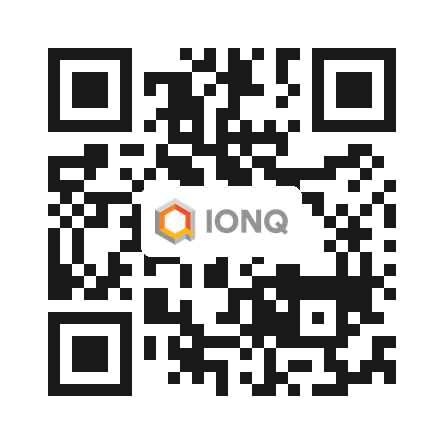

Thank you, sincerely, from the IonQ and Q-SITE teams. Good luck in the duel!
